# Forecasting tax collection from enrolled debt stock: a comparative M0–M9 / E1–E4 protocol (monthly, daily, and weekly grains)

*Previsão de arrecadação a partir do estoque inscrito: protocolo comparativo M0–M9 / E1–E4 (grãos mensal, diário e semanal)*

## Abstract (skeleton)

**Research question.** Under a single evaluation protocol, which model family among M0–M9 (Stage 1) and energy stage E1–E4 best forecasts enrolled-debt collection — on the monthly stock×collection panel and on the daily/weekly GARE aggregates — and what does that imply for an operational monitoring instrument?

**Design.** Triple grain with one switch (`RUN_GRAINS`): (i) **monthly** stock×collection panel; (ii) **daily** GARE aggregate (`valor_sum`) on a continuous civil calendar with explicit zeros; (iii) **weekly** GARE (`valor_sum` summed by week ending Sunday). Shared metric family (MAPE / sMAPE / RMSE / MAE / WAPE) plus **skill score on sMAPE** vs seasonal naive, and contiguous `train | val | test` logic. **All model bodies live in this notebook** (KISS + SOLID sections; one runner for all grains — no duplicated monthly/daily/weekly implementations).

**Protocol.** Monthly: `train | val(12) | test(12)`. Daily: `train | val(90) | test(90)`. Weekly: `train | val(13) | test(13)`. Hyperparameter choice by validation sMAPE; retrain on train+val when applicable; report test metrics only from real runs. Ranking primary = **raw sMAPE**; skill score is complementary. Fine grains prefer **sMAPE/RMSE** (zeros / volatility).

**Energy stage.** E1 = TEM selective (vendor EBM; TimesNet/`Exp_Main_Energy` attempted with soft-fail). E2 = lightweight energy-proxy **ablation only** (never labeled TEM). E3 TimeGrad / E4 ScoreGrad = notebook-native generative implementations (soft-fail ok).

## Keywords
tax collection; enrolled debt; walk-forward; MAPE; sMAPE; skill score; Prophet; SARIMAX; TimesFM; TEM; selective forecasting; TimeGrad; ScoreGrad; daily GARE; weekly GARE

> *Note.* Substantive content and conclusions are the monorepo author's; formatting and scaffolding were AI-assisted.


## Setup (paths, freeze, figures, grain switch)

Mono via `Path.parents`. Figures under `output/figures/articles/arrecadacao_forecast_paper_v1/`.
**All metrics, protocol, factories, and runners live in this notebook's cells** — no importable `arrecadacao_forecast` package.


In [1]:
from pathlib import Path
import os, sys, time, json, traceback, warnings
from dataclasses import dataclass, field
from typing import Any, Callable, Iterable
warnings.filterwarnings("ignore")

NB_DIR = Path.cwd()
MONO = next((p for p in [NB_DIR, *NB_DIR.parents] if (p / "shared" / "cemepi_api").exists()), NB_DIR)
os.chdir(MONO)
sys.path.insert(0, str(MONO))
# NOTE: do NOT add projects/monitoramento/src — package archived; logic is inline below.

from shared.cemepi_api import CemepiClient, load_settings
S = load_settings(); S.ano, S.mes = 2026, 3
C = CemepiClient(S)
EXTRACAO = f"{S.ano:04d}-{S.mes:02d}"; assert EXTRACAO == "2026-03"

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

SEED = 42; np.random.seed(SEED)
FIG_DIR = MONO / "projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1"
OUT_DIR = MONO / "projects/monitoramento/output/articles/arrecadacao_forecast_paper_v1"
FIG_DIR.mkdir(parents=True, exist_ok=True); OUT_DIR.mkdir(parents=True, exist_ok=True)

_bertini = OUT_DIR / "metrics_monthly_bertini.csv"
if _bertini.exists():
    arch = OUT_DIR / "_archive"; arch.mkdir(exist_ok=True)
    _bertini.rename(arch / "metrics_monthly_bertini.csv")
    print("archived", _bertini.name, "-> _archive/")

RUN_GRAINS = frozenset({"business_daily"})  # ablation B re-run; daily A enriched from saved preds/CSV (no overwrite of protocol)
RUN_MONTHLY = "monthly" in RUN_GRAINS
RUN_DAILY = "daily" in RUN_GRAINS
RUN_WEEKLY = "weekly" in RUN_GRAINS
RUN_BUSINESS_DAILY = "business_daily" in RUN_GRAINS

def public_path_label(p: Path) -> str:
    s = str(p)
    for key in ("DUMP_ROOT", "LAKE_ROOT", "COLLECT_ROOT"):
        root = os.getenv(key)
        if root and s.startswith(root):
            return f"${{{key}}}/" + s[len(root):].lstrip("/")
    if s.startswith(str(MONO)):
        return "mono:/" + s[len(str(MONO)):].lstrip("/")
    return p.name

def save_fig(fig, stem: str, width: int = 1000, height: int = 520) -> Path:
    out = FIG_DIR / f"{stem}.png"; html = FIG_DIR / f"{stem}.html"
    try: fig.write_html(str(html))
    except Exception as e: print("HTML skip:", type(e).__name__, e)
    try:
        fig.write_image(str(out), width=width, height=height, scale=2)
        print("static ->", public_path_label(out))
    except Exception as e:
        print("Kaleido skip:", type(e).__name__, e)
    return out

_pkg = MONO / "projects/monitoramento/src/arrecadacao_forecast"
print("MONO", public_path_label(MONO), "| EXTRACAO", EXTRACAO)
print("RUN_GRAINS", sorted(RUN_GRAINS))
print("package path present?", _pkg.exists(), "(should be False after archive)")


MONO mono:/ | EXTRACAO 2026-03
RUN_GRAINS ['business_daily']
package path present? False (should be False after archive)


## 1. Background and theoretical anchors

Hyndman & Athanasopoulos (2021), FPP3 — https://otexts.com/fpp3/. Metrics:

$$\mathrm{MAPE}=\frac{100\%}{h}\sum\left|\frac{y_t-\hat y_t}{y_t}\right|,\quad
\mathrm{sMAPE}=\frac{100\%}{h}\sum\frac{2|y_t-\hat y_t|}{|y_t|+|\hat y_t|},\quad
\mathrm{RMSE}=\sqrt{\frac1h\sum(y_t-\hat y_t)^2}.$$

**Zero policy (implemented in the metrics code).** MAPE **omits** points with $y_t \approx 0$ (division by zero). sMAPE **omits** points with denominator $|y_t|+|\hat y_t| \approx 0$. On the monthly panel this is rare; on **daily GARE** there are explicit zeros on days without a payment slip — prefer **sMAPE** and **RMSE** as primary metrics in that grain. MAE / WAPE remain as future robustness checks (not reported here yet).

**Hyperparameter selection: minimize validation sMAPE.** Citations: Hoerl & Kennard (1970) Ridge; Box–Jenkins; Friedman (2001) boosting; Taylor & Letham (2018) Prophet; Tukey (1977) IQR; TimesFM (Google); TEM / selective forecasting (Brusokas et al., 2025).


## 2. Data (`extracao=2026-03`)

Monthly parquet via `C.sample_dir()/painel_mensal_estoque_arrecadacao.parquet`. Daily: SoT `gare_diario_2026-03.parquet` (+ sidecar JSON). Soft-fail if missing — do not improvise data.


In [2]:
parquet_path = C.sample_dir() / "painel_mensal_estoque_arrecadacao.parquet"
panel = None
if parquet_path.exists():
    panel = pd.read_parquet(parquet_path)
    if "data" in panel.columns:
        panel["data"] = pd.to_datetime(panel["data"])
    print("panel", panel.shape, public_path_label(parquet_path))
else:
    print("SKIP monthly panel ausente:", public_path_label(parquet_path))


panel (119, 14) ${DUMP_ROOT}/extracao=2026-03/samples/painel_mensal_estoque_arrecadacao.parquet


## Evaluation protocol (inline — one for monthly, daily, and weekly)

Implementation in the cells below: metrics (incl. skill score), `SplitConfig` / `EvalContext`, walk-forward, `run_protocol`.

| Grain | Slices | Selection | Retrain | Official ranking | Seasonal ref (skill) |
|------|--------|---------|----------|-----------------|----------------------|
| Monthly | train\|val(12)\|test(12) | sMAPE(val) | train+val | **sMAPE** (+ RMSE) | lag 12 |
| Daily | train\|val(90)\|test(90) | sMAPE(val) | train+val | **sMAPE** (+ RMSE) | lag 7 |
| Weekly | train\|val(13)\|test(13) | sMAPE(val) | train+val | **sMAPE** (+ RMSE) | lag 52 |

**Zeros:** `mape` omits $y\approx 0$; sMAPE omits null denominators. MAE/WAPE complementary. Degenerate KRR (`sMAPE\geq 180`) → `exclude_from_ranking`.

$$
\mathrm{MAPE}=\frac{100\%}{n}\sum\left|\frac{y-\hat y}{y}\right|,\quad
\mathrm{sMAPE}=\frac{100\%}{n}\sum\frac{2|y-\hat y|}{|y|+|\hat y|},\quad
\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum(y-\hat y)^2}.
$$

Citations: Hyndman & Athanasopoulos (FPP3); Makridakis et al. (M4) for sMAPE as ranking.


### Skill score (Murphy form on sMAPE)

We use Murphy’s general skill-score form

$$
\mathrm{SS}=1-\frac{A}{A_{\mathrm{ref}}}
$$

with $A=$ **sMAPE** of the candidate and $A_{\mathrm{ref}}=$ sMAPE of the **seasonal naive** at the grain lag (12 monthly / 7 daily / 52 weekly). **Murphy (1988) formulated SS for MSE/MSE-like scores; we apply the same algebraic form to sMAPE** — we do **not** claim Murphy used sMAPE. Positive SS means the model beats the seasonal naive on sMAPE; $SS = 0$ for the reference itself; undefined if $A_{\mathrm{ref}}\approx 0$ or non-finite.

Related scaled-vs-naive idea: Hyndman & Koehler (2006) on MASE (MAE scaled by in-sample seasonal naive MAE). Here the complementary column is **SS_sMAPE** on the holdout; **ranking remains primary on raw sMAPE**.

**Citations.**
- Murphy, A. H. (1988). Skill Scores Based on the Mean Square Error. *Monthly Weather Review*, 116(12), 2417–2424. https://doi.org/10.1175/1520-0493(1988)116%3C2417:SSBOTM%3E2.0.CO;2
- Hyndman, R. J., & Koehler, A. B. (2006). Another look at measures of forecast accuracy. *International Journal of Forecasting*, 22(4), 679–688.

**Complementary (calendar daily only).** Ranking **A** remains sMAPE on **all** calendar days (including zeros). We also report sMAPE$_{y \gt 0}$ (and SS vs the same seasonal naive restricted to $y \gt 0$ days) as a descriptive check of behaviour on active collection days — **not** a second official ranking and **not** a reason to drop zeros from the primary target.


In [3]:
# ===== Metrics helpers =====
DEGENERATE_SMAPE = 180.0

def mape(a, f) -> float:
    a, f = np.asarray(a, float), np.asarray(f, float)
    m = np.isfinite(a) & np.isfinite(f) & (np.abs(a) > 1e-12)
    return float(np.mean(np.abs((a[m] - f[m]) / a[m]) * 100)) if m.any() else float("nan")

def smape(a, f) -> float:
    a, f = np.asarray(a, float), np.asarray(f, float)
    d = np.abs(a) + np.abs(f)
    m = np.isfinite(a) & np.isfinite(f) & (d > 1e-12)
    return float(np.mean(2 * np.abs(a[m] - f[m]) / d[m] * 100)) if m.any() else float("nan")

def rmse(a, f) -> float:
    a, f = np.asarray(a, float), np.asarray(f, float)
    m = np.isfinite(a) & np.isfinite(f)
    return float(np.sqrt(np.mean((a[m] - f[m]) ** 2))) if m.any() else float("nan")

def mae(a, f) -> float:
    a, f = np.asarray(a, float), np.asarray(f, float)
    m = np.isfinite(a) & np.isfinite(f)
    return float(np.mean(np.abs(a[m] - f[m]))) if m.any() else float("nan")

def wape(a, f) -> float:
    a, f = np.asarray(a, float), np.asarray(f, float)
    m = np.isfinite(a) & np.isfinite(f)
    if not m.any():
        return float("nan")
    denom = float(np.sum(np.abs(a[m])))
    if denom <= 1e-12:
        return float("nan")
    return float(100.0 * np.sum(np.abs(a[m] - f[m])) / denom)

def is_degenerate_smape(sm, thr=DEGENERATE_SMAPE) -> bool:
    return (not np.isfinite(sm)) or (float(sm) >= thr)

def skill_score(metric_model, metric_ref) -> float:
    """Murphy (1988) SS = 1 - A/A_ref. Here A = sMAPE; ref = seasonal naive. Guard div0/nan."""
    try:
        m = float(metric_model)
        r = float(metric_ref)
    except (TypeError, ValueError):
        return float("nan")
    if (not np.isfinite(m)) or (not np.isfinite(r)) or abs(r) < 1e-12:
        return float("nan")
    return float(1.0 - m / r)

def attach_skill_scores(df: pd.DataFrame, *, seasonal_lag: int, id_prefix: str = "",
                        metric_col: str = "SMAPE", ss_col: str = "SS_SMAPE") -> pd.DataFrame:
    """Add skill score = 1 - metric/metric_ref using seasonal-naive of the same stage (all grains)."""
    out = df.copy()
    if out.empty or metric_col not in out.columns:
        out[ss_col] = []
        return out
    ref_name = f"{id_prefix}M0_naive_sazonal_lag{seasonal_lag}"
    out[ss_col] = np.nan
    for stage, g in out.groupby("stage", dropna=False):
        ref_rows = g[g["modelo"].astype(str) == ref_name]
        if ref_rows.empty:
            ref_rows = g[g["modelo"].astype(str).str.contains(f"naive_sazonal_lag{seasonal_lag}", regex=False)]
        if ref_rows.empty:
            continue
        ref_sm = float(ref_rows.iloc[0][metric_col])
        idx = g.index
        out.loc[idx, ss_col] = [skill_score(v, ref_sm) for v in g[metric_col].tolist()]
    return out

def enrich_positive_day_metrics(df: pd.DataFrame, preds: dict, y_test: np.ndarray, *,
                                seasonal_lag: int, id_prefix: str = "") -> pd.DataFrame:
    """Complementary sMAPE/SS on y>0 days for calendar daily. Does NOT change ranking-A (SMAPE all days)."""
    out = df.copy()
    if "SMAPE_POS" not in out.columns:
        out["SMAPE_POS"] = np.nan
    y_te = np.asarray(y_test, float)
    for i, row in out.iterrows():
        if str(row.get("stage", "")) != "test":
            continue
        m = str(row["modelo"])
        if m not in preds:
            continue
        out.loc[i, "SMAPE_POS"] = smape_positive(y_te, np.asarray(preds[m], float))
    out = attach_skill_scores(out, seasonal_lag=seasonal_lag, id_prefix=id_prefix,
                              metric_col="SMAPE_POS", ss_col="SS_SMAPE_POS")
    return out

def smape_positive(a, f, eps: float = 1e-12) -> float:
    """sMAPE restricted to days with y>0 (operational active days within a calendar series)."""
    a, f = np.asarray(a, float), np.asarray(f, float)
    m = np.isfinite(a) & np.isfinite(f) & (a > eps)
    if not m.any():
        return float("nan")
    d = np.abs(a[m]) + np.abs(f[m])
    m2 = d > eps
    return float(np.mean(2 * np.abs(a[m][m2] - f[m][m2]) / d[m2] * 100)) if m2.any() else float("nan")

def score_row(name, actual, fcast, stage, notes="") -> dict:
    return {"modelo": name, "stage": stage, "MAPE": mape(actual, fcast), "SMAPE": smape(actual, fcast),
            "SMAPE_POS": smape_positive(actual, fcast),
            "RMSE": rmse(actual, fcast), "MAE": mae(actual, fcast), "WAPE": wape(actual, fcast), "notes": notes}

def soft_fail_row(name: str, reason: str, stage: str = "test") -> dict:
    note = reason if reason.startswith("soft-fail") or "exclude_from_ranking" in reason else f"soft-fail: {reason}"
    return {"modelo": name, "stage": stage, "MAPE": np.nan, "SMAPE": np.nan, "SMAPE_POS": np.nan,
            "RMSE": np.nan, "MAE": np.nan, "WAPE": np.nan, "notes": note}

def filter_main_ranking(test_df: pd.DataFrame) -> pd.DataFrame:
    df = test_df.copy()
    df = df[~df["modelo"].astype(str).str.contains("_cand")].copy()
    notes = df["notes"].astype(str) if "notes" in df.columns else pd.Series([""] * len(df), index=df.index)
    excl = notes.str.contains("exclude_from_ranking", case=False, na=False) | notes.str.contains("degenerate", case=False, na=False)
    df = df.loc[~excl].copy()
    if "SMAPE" in df.columns:
        df = df[np.isfinite(df["SMAPE"].astype(float))].copy()
    return df.sort_values("SMAPE", ascending=True, na_position="last").reset_index(drop=True)

@dataclass
class SplitConfig:
    val_h: int
    test_h: int
    min_train: int = 24
    wf_cap: int | None = None
    seasonal_lag: int = 12
    y_col: str = "y"
    grain: str = "monthly"
    id_prefix: str = ""

@dataclass
class EvalContext:
    y: pd.Series
    feat: pd.DataFrame
    xcols: list[str]
    train_end: int
    val_end: int
    test_end: int
    split: SplitConfig
    seed: int = 42
    mono: Path | None = None
    dates_test: pd.Series | None = None
    extras: dict[str, Any] = field(default_factory=dict)

    @property
    def y_val(self) -> np.ndarray:
        return self.y.iloc[self.train_end : self.val_end].values.astype(float)

    @property
    def y_test(self) -> np.ndarray:
        return self.y.iloc[self.val_end : self.test_end].values.astype(float)

    def mid(self, base: str) -> str:
        p = self.split.id_prefix
        if p and not base.startswith(p):
            return f"{p}{base}"
        return base

def temporal_split_idx(n: int, val_h: int = 12, test_h: int = 12, min_train: int = 24):
    if n < val_h + test_h + min_train:
        test_h = max(3, n // 5); val_h = max(3, n // 5)
        if n < val_h + test_h + min_train:
            min_train = max(8, n - val_h - test_h)
    test_end = n; val_end = n - test_h; train_end = val_end - val_h
    assert 0 < train_end < val_end < test_end, (n, train_end, val_end, test_end, val_h, test_h)
    return train_end, val_end, test_end

def make_context(y, feat, xcols, split: SplitConfig, *, seed=42, mono=None, dates=None, extras=None) -> EvalContext:
    n = len(y)
    train_end, val_end, test_end = temporal_split_idx(n, split.val_h, split.test_h, split.min_train)
    dates_test = dates.iloc[val_end:test_end].reset_index(drop=True) if dates is not None else None
    y2 = y.reset_index(drop=True) if getattr(y, "index", None) is not None else y
    return EvalContext(y=y2, feat=feat, xcols=list(xcols), train_end=train_end, val_end=val_end, test_end=test_end,
                       split=split, seed=seed, mono=mono, dates_test=dates_test, extras=extras or {})

def walk_forward_xy(model_factory, y_s, feat_df, xcols, start, end, y_col="y", min_tr=24, cap=None):
    fcast, actual, lowers, uppers = [], [], [], []
    for t in range(start, end):
        if feat_df is None or t not in feat_df.index or feat_df.loc[t, xcols].isna().any():
            fcast.append(np.nan); actual.append(float(y_s.iloc[t]) if y_s is not None else np.nan)
            lowers.append(np.nan); uppers.append(np.nan); continue
        tr = feat_df.loc[feat_df.index < t].dropna(subset=xcols + [y_col])
        if cap is not None: tr = tr.tail(cap)
        if len(tr) < min_tr:
            fcast.append(np.nan); actual.append(float(feat_df.loc[t, y_col]))
            lowers.append(np.nan); uppers.append(np.nan); continue
        mdl = model_factory(); Xtr, ytr = tr[xcols].values, tr[y_col].values
        mdl.fit(Xtr, ytr)
        yhat = float(mdl.predict(feat_df.loc[[t], xcols].values)[0])
        rtr = ytr - mdl.predict(Xtr)
        sigma = float(np.std(rtr, ddof=1)) if len(rtr) > 2 else np.nan
        fcast.append(yhat); actual.append(float(feat_df.loc[t, y_col]))
        lowers.append(yhat - 1.96 * sigma if np.isfinite(sigma) else np.nan)
        uppers.append(yhat + 1.96 * sigma if np.isfinite(sigma) else np.nan)
    return np.array(actual, float), np.array(fcast, float), np.array(lowers, float), np.array(uppers, float)

def run_protocol(ctx: EvalContext, model_ids=None, *, verbose: bool = True):
    ids = list(model_ids) if model_ids is not None else grain_model_ids(ctx.split.grain)
    results, preds, status = [], {}, {}
    for mid in ids:
        if mid not in MODEL_REGISTRY:
            raise KeyError(f"unknown model id {mid!r}; known={sorted(MODEL_REGISTRY)}")
        if verbose: print(f"==> {ctx.split.grain} {ctx.split.id_prefix}{mid}", flush=True)
        out = MODEL_REGISTRY[mid](ctx)
        if mid in ("E1", "E2", "E3", "E4"):
            rows, pr, st = out; status[mid] = st
        else:
            rows, pr = out; status[mid] = {"ok": True, "reason": None}
            if rows and all("soft-fail" in str(r.get("notes", "")) or "exclude_from_ranking" in str(r.get("notes", "")) for r in rows if r.get("stage") == "test"):
                status[mid] = {"ok": False, "reason": rows[-1].get("notes")}
        results.extend(rows); preds.update(pr)
        if verbose: print(f"    status={status[mid]}", flush=True)
    return results, preds, status

print("protocol helpers ready (incl. skill_score / SMAPE_POS / attach_skill_scores)")


protocol helpers ready (incl. skill_score / SMAPE_POS / attach_skill_scores)


## 3. EDA

### 3.1 Dual-axis stock × collection
**How to read:** axes use distinct scales — do not compare magnitudes across axes. Look for co-movement; do not infer causality.


In [4]:
if (not RUN_MONTHLY) or panel is None:
    print("SKIP dual-axis")
else:
    fig_dual = make_subplots(specs=[[{"secondary_y": True}]])
    fig_dual.add_trace(go.Scatter(x=panel["data"], y=panel["valor_sem_honorarios"], name="Stock",
        mode="lines", line=dict(width=1.8, color="#4C78A8")), secondary_y=False)
    fig_dual.add_trace(go.Scatter(x=panel["data"], y=panel["valor_total"], name="Collection",
        mode="lines", line=dict(width=1.8, color="#F58518")), secondary_y=True)
    fig_dual.update_layout(title=dict(text="Estoque inscrito vs arrecadação mensal", y=0.98),
        height=480, margin=dict(t=90,l=70,r=70,b=50),
        legend=dict(orientation="h", yanchor="bottom", y=1.06, x=0), template="plotly_white")
    fig_dual.update_xaxes(title_text="Mês")
    fig_dual.update_yaxes(title_text="Estoque (R$)", secondary_y=False)
    fig_dual.update_yaxes(title_text="Arrecadação (R$)", secondary_y=True)
    fig_dual.show(); save_fig(fig_dual, "paper_v1_dual_axis", 1100, 480)


SKIP dual-axis


### 3.2 Seasonal profile
**How to read:** mean of `valor_total` by calendar month. Informs the lag-12 / Prophet baseline.


In [5]:
if (not RUN_MONTHLY) or panel is None:
    print("SKIP seasonal")
else:
    seas = panel.groupby("mes", as_index=False)["valor_total"].mean()
    fig_seas = px.bar(seas, x="mes", y="valor_total", title="Mean seasonal profile of collection",
        labels={"valor_total":"Média valor_total (R$)","mes":"Mês"}, template="plotly_white")
    fig_seas.update_layout(height=400, margin=dict(t=80,l=60,r=30,b=50), title=dict(y=0.98))
    fig_seas.update_xaxes(dtick=1); fig_seas.show(); save_fig(fig_seas, "paper_v1_seasonal", 900, 400)


SKIP seasonal


### 3.3 Same-month and lag-1 scatter (IQR / OLS)
**How to read:** Tukey 1.5×IQR outliers; descriptive OLS line (not M1).


In [6]:
if (not RUN_MONTHLY) or panel is None:
    print("SKIP scatter")
else:
    sc = panel[["data","ano","mes","valor_sem_honorarios","valor_total"]].copy()
    sc["estoque_lag1"] = sc["valor_sem_honorarios"].shift(1)
    def iqr_mask(s):
        q1,q3 = s.quantile(0.25), s.quantile(0.75); iqr=q3-q1
        return (s < q1-1.5*iqr) | (s > q3+1.5*iqr)
    sc["outlier_iqr"] = iqr_mask(sc["valor_sem_honorarios"]) | iqr_mask(sc["valor_total"])
    sc["flag"] = np.where(sc["outlier_iqr"], "outlier_IQR", "inlier")
    fig_sc1 = px.scatter(sc, x="valor_sem_honorarios", y="valor_total", color="flag", hover_data=["data"],
        title="Stock vs collection (same month) — IQR + OLS",
        labels={"valor_sem_honorarios":"Estoque (R$)","valor_total":"Arrecadação (R$)"},
        color_discrete_map={"inlier":"#4C78A8","outlier_IQR":"#E45756"}, trendline="ols", template="plotly_white")
    fig_sc1.update_layout(height=460, margin=dict(t=80,l=70,r=30,b=50), title=dict(y=0.98))
    fig_sc1.show(); save_fig(fig_sc1, "paper_v1_scatter_mesmo_mes", 900, 460)
    fig_sc2 = px.scatter(sc.dropna(subset=["estoque_lag1"]), x="estoque_lag1", y="valor_total", color="flag",
        hover_data=["data"], title="Stock lag-1 vs collection — IQR + OLS",
        labels={"estoque_lag1":"Estoque t-1 (R$)","valor_total":"Arrecadação t (R$)"},
        color_discrete_map={"inlier":"#4C78A8","outlier_IQR":"#E45756"}, trendline="ols", template="plotly_white")
    fig_sc2.update_layout(height=460, margin=dict(t=80,l=70,r=30,b=50), title=dict(y=0.98))
    fig_sc2.show(); save_fig(fig_sc2, "paper_v1_scatter_lag1", 900, 460)
    print(f"corr same={sc['valor_sem_honorarios'].corr(sc['valor_total']):.3f} lag1={sc['estoque_lag1'].corr(sc['valor_total']):.3f} outliers={int(sc['outlier_iqr'].sum())}/{len(sc)}")


SKIP scatter


### 3.4 Overview facets (ICMS / IPVA / Other)
**How to read:** composition by type; independent Y axes per facet. Soft-fail if the API fails.


In [7]:
if (not RUN_MONTHLY) or panel is None:
    print('SKIP visao facets')
else:
    visao_ok = False
    try:
        visao = C.get_json("/v1/analytics/visao-geral", timeout=45)
        tipo = pd.DataFrame(visao.get("estoque_por_tipo") or [])
        arrec_ano = pd.DataFrame(visao.get("arrecadacao_por_ano") or [])
        if not tipo.empty:
            tipo.columns = [c.lower() for c in tipo.columns]
            val_col = "valor" if "valor" in tipo.columns else tipo.select_dtypes("number").columns[0]
            tipo_col = "tipo" if "tipo" in tipo.columns else tipo.columns[0]
            tipo[val_col] = pd.to_numeric(tipo[val_col], errors="coerce")
            tnorm = tipo[tipo_col].astype(str).str.upper()
            tipo["grupo"] = np.where(tnorm.str.contains("IPVA"), "IPVA", np.where(tnorm.str.contains("ICMS"), "ICMS", "Demais"))
            fig_tipo = px.bar(tipo.sort_values(val_col, ascending=False), x=tipo_col, y=val_col, facet_row="grupo",
                title="Stock by type — ICMS / IPVA / Other", labels={val_col:"R$", tipo_col:"Tipo"}, template="plotly_white")
            fig_tipo.update_yaxes(matches=None)
            fig_tipo.update_layout(height=720, xaxis_tickangle=-35, margin=dict(t=80,l=60,r=30,b=80))
            fig_tipo.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
            fig_tipo.show(); save_fig(fig_tipo, "paper_v1_composicao_tipo", 1000, 720)
            visao_ok = True
            print(tipo.groupby("grupo")[val_col].sum().sort_values(ascending=False))
        if not arrec_ano.empty:
            arrec_ano.columns = [c.lower() for c in arrec_ano.columns]
            ycol = "valor_total" if "valor_total" in arrec_ano.columns else arrec_ano.select_dtypes("number").columns[-1]
            xcol = "ano" if "ano" in arrec_ano.columns else arrec_ano.columns[0]
            fig_aa = px.bar(arrec_ano.sort_values(xcol), x=xcol, y=ycol, title="Collection by year (overview)",
                labels={ycol:"R$", xcol:"Ano"}, template="plotly_white")
            fig_aa.update_layout(height=380, margin=dict(t=80,l=60,r=30,b=50), title=dict(y=0.98))
            fig_aa.show(); save_fig(fig_aa, "paper_v1_arrec_por_ano", 900, 380)
    except Exception as e:
        print("visao-geral skip:", type(e).__name__, e)
    if not visao_ok:
        print("Composição por tipo indisponível nesta execução.")


SKIP visao facets


## 4. Ladder M0–M9 / E1–E4 — grain-agnostic factories (inline)

Each model has **one** academic MD cell + **one** runner (`run_m*` / `run_e*`) parameterized by `EvalContext.split.grain`.
Monthly and daily call the **same** `run_protocol(ctx)` — only `SplitConfig` changes (horizons, `seasonal_lag`, `wf_cap`, `id_prefix`).

| ID | Model | Notes |
|----|--------|-------|
| M0 | Naive / seasonal | 1+12 monthly; 1/7/365 daily |
| M1 | OLS + Ridge | α grid on val |
| M2 | SARIMAX | AIC on val |
| M3 | HGB | grid on val |
| M4 | Prophet | cps/sps grid |
| M5 | Solid MLP | scaler + early stop + grid (not N-BEATS) |
| M6 | ARF (River) | |
| M7 | GP | daily: cap=200 |
| M8 | KernelRidge | scaler + grid; exclude if degenerate |
| M9 | TimesFM 3.0 | zero-shot |
| E1 | Selective TEM | vendor EBM (+ TimesNet/`Exp_Main_Energy` attempt) — **not** proxy |
| E2 | Energy proxy | ablation only |
| E3 | TimeGrad | notebook-native residual DDPM |
| E4 | ScoreGrad | notebook-native score+Langevin |


In [8]:
def _cap(ctx):
    return ctx.split.wf_cap

def _is_daily_like(ctx) -> bool:
    """Calendar daily and business-day daily share fine HP / lag budgets."""
    return ctx.split.grain in ("daily", "business_daily")

def _is_fine(ctx) -> bool:
    """Daily-like and weekly share fine-grain caps / soft-fail budgets."""
    return ctx.split.grain in ("daily", "business_daily", "weekly")

def _grain_hp_key(ctx) -> str:
    """Map business_daily → daily for hyperparameter tables (seasonal_lag still from SplitConfig)."""
    g = ctx.split.grain
    return "daily" if g == "business_daily" else g

def _min_tr(ctx, default_m=24, default_d=60):
    if ctx.split.grain == "weekly":
        return 52
    return default_d if _is_daily_like(ctx) else default_m

def _prophet_freq(ctx) -> str:
    return {
        "daily": "D",
        "business_daily": "B",
        "weekly": "W-SUN",
        "monthly": "MS",
    }.get(ctx.split.grain, "MS")

def _sarimax_period(ctx) -> int:
    """Seasonal period for SARIMAX. Weekly uses 4 (soft-fail ok) to avoid s=52 blow-up; naive/SS still use lag 52.
    Business-day daily uses s=5 (Mon–Fri week)."""
    if ctx.split.grain == "daily":
        return 7
    if ctx.split.grain == "business_daily":
        return 5
    if ctx.split.grain == "weekly":
        return 4
    return 12

def _wf(ctx, factory, start, end, min_tr=None):
    return walk_forward_xy(
        factory, ctx.y, ctx.feat, ctx.xcols, start, end,
        y_col=ctx.split.y_col,
        min_tr=min_tr if min_tr is not None else _min_tr(ctx),
        cap=_cap(ctx),
    )

print("grain helpers ready (_is_fine / _is_daily_like / prophet_freq / sarimax_period)")


grain helpers ready (_is_fine / _is_daily_like / prophet_freq / sarimax_period)


### M0 — Naive lag-1 and seasonal

**Definition.** $\hat y_t = y_{t-k}$ with $k=1$ (naive) or $k=$ seasonal lag (12 monthly; 7 and 365 daily; 52 weekly). FPP3 baseline (Hyndman & Athanasopoulos). Also the **reference** for the SS_sMAPE skill score.

**Use here.** Report all $k$ on the test set (no retrain). Daily: $k\in\{1,7,365\}$; weekly: $k\in\{1,52\}$.

**Citation.** Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: principles and practice* (3rd ed.). OTexts.


In [9]:
# ----- M0 naive -----
def run_m0_naive(ctx: EvalContext) -> tuple[list[dict], dict]:
    results, preds = [], {}
    if ctx.split.grain == "daily":
        lags = [1, 7, 365]
    elif ctx.split.grain == "business_daily":
        # seasonal_lag=5 (Mon–Fri week); optional ~1y in business days if series long enough
        lags = [1, ctx.split.seasonal_lag]
        if len(ctx.y) >= 252 + ctx.split.val_h + ctx.split.test_h + 60:
            lags.append(252)
    elif ctx.split.grain == "weekly":
        lags = [1, ctx.split.seasonal_lag]
    else:
        lags = [1, ctx.split.seasonal_lag]
    for lag in lags:
        name = ctx.mid("M0_naive_lag1" if lag == 1 else f"M0_naive_sazonal_lag{lag}")
        for stage, start, end, y_true in (
            ("val", ctx.train_end, ctx.val_end, ctx.y_val),
            ("test", ctx.val_end, ctx.test_end, ctx.y_test),
        ):
            if start < lag:
                f = np.full(end - start, np.nan)
            else:
                f = np.array([float(ctx.y.iloc[t - lag]) for t in range(start, end)], float)
            note = f"k={lag}" if stage == "val" else f"baseline k={lag}"
            results.append(score_row(name, y_true, f, stage, note))
            if stage == "test":
                preds[name] = f
    return results, preds


### M1 — OLS and Ridge

**Definition.** $y_t = X_t\beta + \varepsilon$ with lags of collection/stock (monthly) or y/slips/calendar (daily). Ridge: $\min\|y-X\beta\|_2^2 + \alpha\|\beta\|_2^2$ (Hoerl & Kennard, 1970).

**Use here.** 1-step walk-forward; grid $\alpha\in\{0.1,1,10\}$ on val (sMAPE); best $\alpha$ on test.

**Citation.** Hoerl, A. E., & Kennard, R. W. (1970). Ridge regression. *Technometrics*.


In [10]:
# ----- M1 OLS / Ridge -----
def run_m1_linear(ctx: EvalContext) -> tuple[list[dict], dict]:
    from sklearn.linear_model import LinearRegression, Ridge

    results, preds = [], {}
    try:
        # OLS
        name = ctx.mid("M1_OLS")
        act, fc, _, _ = _wf(ctx, LinearRegression, ctx.val_end, ctx.test_end)
        mask = np.isfinite(fc)
        results.append(score_row(name, act[mask], fc[mask], "test", "OLS; WF test"))
        preds[name] = fc
        # Ridge grid on val
        best, best_sm = None, np.inf
        for a in [0.1, 1.0, 10.0]:
            factory = lambda alpha=a: Ridge(alpha=alpha)
            act, fc, _, _ = _wf(ctx, factory, ctx.train_end, ctx.val_end)
            mask = np.isfinite(fc)
            smv = smape(act[mask], fc[mask]) if mask.any() else np.nan
            results.append(score_row(ctx.mid("M1_Ridge_cand"), act[mask], fc[mask], "val", f"α={a}") if mask.any() else soft_fail_row(ctx.mid("M1_Ridge_cand"), f"α={a}", "val"))
            if np.isfinite(smv) and smv < best_sm:
                best_sm, best = smv, a
        if best is not None:
            name = ctx.mid(f"M1_Ridge_a{best}")
            act, fc, _, _ = _wf(ctx, lambda: Ridge(alpha=best), ctx.val_end, ctx.test_end)
            mask = np.isfinite(fc)
            results.append(score_row(name, act[mask], fc[mask], "test", f"Ridge α={best}; WF test"))
            preds[name] = fc
    except Exception as e:
        results.append(soft_fail_row(ctx.mid("M1_OLS"), f"{type(e).__name__}: {e}"))
    return results, preds


### M2 — Seasonal SARIMAX

**Definition.** $(p,d,q)\times(P,D,Q)_s$ with $s=12$ (monthly) or $s=7$ (daily). Box–Jenkins / FPP3. Native PI via `forecast`.

**Use here.** Short grid on train (AIC); retrain train+val → forecast on test.

**Citation.** Box & Jenkins — *Time Series Analysis*; Hyndman & Athanasopoulos (FPP3).


In [11]:
# ----- M2 SARIMAX -----
def run_m2_sarimax(ctx: EvalContext) -> tuple[list[dict], dict]:
    results, preds = [], {}
    try:
        import statsmodels.api as sm

        y = ctx.y.astype(float)
        period = _sarimax_period(ctx)
        if _is_fine(ctx):
            grid = [((1, 0, 0), (0, 1, 1, period)), ((1, 1, 1), (0, 1, 1, period))]
        else:
            grid = [
                ((0, 1, 1), (0, 1, 1, period)),
                ((1, 1, 1), (0, 1, 1, period)),
                ((0, 1, 2), (0, 1, 1, period)),
            ]
        best, best_aic = None, np.inf
        for order, seasonal in grid:
            try:
                endog = y.iloc[: ctx.train_end]
                mdl = sm.tsa.SARIMAX(endog, order=order, seasonal_order=seasonal, enforce_stationarity=False, enforce_invertibility=False)
                fit = mdl.fit(disp=False)
                aic = float(fit.aic)
                results.append({"modelo": ctx.mid("M2_SARIMAX_cand"), "stage": "val", "MAPE": np.nan, "SMAPE": np.nan, "RMSE": np.nan, "MAE": np.nan, "WAPE": np.nan, "notes": f"order={order} seas={seasonal}; AIC={aic:.1f}"})
                if aic < best_aic:
                    best_aic, best = aic, (order, seasonal)
            except Exception:
                continue
        if best is None:
            results.append(soft_fail_row(ctx.mid("M2_SARIMAX"), "no SARIMAX candidate fit"))
            return results, preds
        order, seasonal = best
        endog = y.iloc[: ctx.val_end]
        fit = sm.tsa.SARIMAX(endog, order=order, seasonal_order=seasonal, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        f_te = np.asarray(fit.forecast(ctx.test_end - ctx.val_end), float)
        name = ctx.mid(f"M2_SARIMAX{order}x{seasonal}")
        results.append(score_row(name, ctx.y_test, f_te, "test", f"retrain train+val; AIC_train={best_aic:.1f}"))
        preds[name] = f_te
    except Exception as e:
        traceback.print_exc()
        results.append(soft_fail_row(ctx.mid("M2_SARIMAX"), f"{type(e).__name__}: {e}"))
    return results, preds


### M3 — HistGradientBoostingRegressor

**Definition.** Histogram boosting (Friedman, 2001; sklearn HGB). Tabular lag features.

**Use here.** Grid `(max_iter, lr, max_depth)` on val (WF sMAPE); best on test WF.

**Citation.** Friedman, J. H. (2001). Greedy function approximation: a gradient boosting machine. *Annals of Statistics*.


In [12]:
# ----- M3 HGB -----
def run_m3_hgb(ctx: EvalContext) -> tuple[list[dict], dict]:
    results, preds = [], {}
    try:
        from sklearn.ensemble import HistGradientBoostingRegressor

        if _is_fine(ctx):
            grid = [
                {"max_iter": 100, "learning_rate": 0.05, "max_depth": 3},
                {"max_iter": 200, "learning_rate": 0.1, "max_depth": 3},
            ]
        else:
            grid = [
                {"max_iter": 200, "learning_rate": 0.05, "max_depth": 3},
                {"max_iter": 400, "learning_rate": 0.1, "max_depth": 3},
                {"max_iter": 400, "learning_rate": 0.1, "max_depth": 5},
            ]
        best, best_sm = None, np.inf
        for params in grid:
            p = {**params, "random_state": ctx.seed}
            factory = lambda pp=p: HistGradientBoostingRegressor(early_stopping=True, validation_fraction=0.15, **pp)
            act, fc, _, _ = _wf(ctx, factory, ctx.train_end, ctx.val_end)
            mask = np.isfinite(fc)
            smv = smape(act[mask], fc[mask]) if mask.any() else np.nan
            results.append(score_row(ctx.mid("M3_HGB_cand"), act[mask], fc[mask], "val", str(params)) if mask.any() else soft_fail_row(ctx.mid("M3_HGB_cand"), str(params), "val"))
            if np.isfinite(smv) and smv < best_sm:
                best_sm, best = smv, p
        if best is None:
            results.append(soft_fail_row(ctx.mid("M3_HGB_tuned"), "empty HGB grid"))
            return results, preds
        factory = lambda: HistGradientBoostingRegressor(early_stopping=True, validation_fraction=0.15, **best)
        act, fc, _, _ = _wf(ctx, factory, ctx.val_end, ctx.test_end)
        mask = np.isfinite(fc)
        name = ctx.mid("M3_HGB_tuned")
        results.append(score_row(name, act[mask], fc[mask], "test", str(best)))
        preds[name] = fc
    except Exception as e:
        traceback.print_exc()
        results.append(soft_fail_row(ctx.mid("M3_HGB_tuned"), f"{type(e).__name__}: {e}"))
    return results, preds


### M4 — Prophet

**Definition.** Additive trend + seasonality decomposition (Taylor & Letham, 2018). Native PI `yhat_lower/upper`.

**Use here.** Grid `changepoint_prior_scale` × `seasonality_prior_scale` on val; retrain train+val → test. Daily: weekly+yearly; monthly: yearly.

**Citation.** Taylor, S. J., & Letham, B. (2018). Forecasting at scale. *The American Statistician*.


In [13]:
# ----- M4 Prophet -----
def run_m4_prophet(ctx: EvalContext) -> tuple[list[dict], dict]:
    results, preds = [], {}
    try:
        from prophet import Prophet

        dates = ctx.extras.get("dates")
        if dates is None:
            raise RuntimeError("Prophet needs extras['dates'] aligned with y")
        df = pd_safe_prophet_df(dates, ctx.y)
        freq = _prophet_freq(ctx)
        if _is_daily_like(ctx):
            grid = [{"changepoint_prior_scale": 0.5, "seasonality_prior_scale": 10.0}]
            weekly, yearly = True, True
        elif ctx.split.grain == "weekly":
            grid = [{"changepoint_prior_scale": 0.5, "seasonality_prior_scale": 10.0}]
            weekly, yearly = False, True
        else:
            grid = [
                {"changepoint_prior_scale": 0.05, "seasonality_prior_scale": 1.0},
                {"changepoint_prior_scale": 0.5, "seasonality_prior_scale": 1.0},
                {"changepoint_prior_scale": 0.5, "seasonality_prior_scale": 10.0},
            ]
            weekly, yearly = False, True
        best, best_sm = None, np.inf
        for params in grid:
            m = Prophet(weekly_seasonality=weekly, yearly_seasonality=yearly, daily_seasonality=False, **params)
            m.fit(df.iloc[: ctx.train_end])
            future = m.make_future_dataframe(periods=ctx.val_end - ctx.train_end, freq=freq)
            fc = m.predict(future)["yhat"].iloc[ctx.train_end : ctx.val_end].values.astype(float)
            smv = smape(ctx.y_val, fc)
            results.append(score_row(ctx.mid("M4_Prophet_cand"), ctx.y_val, fc, "val", str(params)))
            if np.isfinite(smv) and smv < best_sm:
                best_sm, best = smv, params
        if best is None:
            results.append(soft_fail_row(ctx.mid("M4_Prophet"), "empty Prophet grid"))
            return results, preds
        m = Prophet(weekly_seasonality=weekly, yearly_seasonality=yearly, daily_seasonality=False, **best)
        m.fit(df.iloc[: ctx.val_end])
        future = m.make_future_dataframe(periods=ctx.test_end - ctx.val_end, freq=freq)
        f_te = m.predict(future)["yhat"].iloc[ctx.val_end : ctx.test_end].values.astype(float)
        name = ctx.mid("M4_Prophet")
        note = f"retrain; cps={best['changepoint_prior_scale']},sps={best['seasonality_prior_scale']}; PI nativo"
        results.append(score_row(name, ctx.y_test, f_te, "test", note))
        preds[name] = f_te
    except Exception as e:
        traceback.print_exc()
        results.append(soft_fail_row(ctx.mid("M4_Prophet"), f"{type(e).__name__}: {e}"))
    return results, preds


def pd_safe_prophet_df(dates, y):
    import pandas as pd

    return pd.DataFrame({"ds": pd.to_datetime(dates).values, "y": np.asarray(y, float)})


### M5 — Solid MLP (PyTorch) — **not** N-BEATS

**Definition.** 2-layer MLP over a window of scaled $y$ lags. Protocol: `StandardScaler` fit on train only; early stopping on val; grid `(lag, width, lr)` by sMAPE(val); retrain train+val.

**Use here.** Monthly: lag∈{6,12}; daily: lag∈{14,28} with train subsample. Soft-fail if torch is missing.

**Citation.** Goodfellow et al. — *Deep Learning* (MLP); selection protocol aligned with FPP3 (val → retrain).


In [14]:
# ----- M5 MLP -----
def run_m5_mlp(ctx: EvalContext) -> tuple[list[dict], dict]:
    results, preds = [], {}
    try:
        import torch
        import torch.nn as nn
        from sklearn.preprocessing import StandardScaler

        torch.manual_seed(ctx.seed)

        class MLP2(nn.Module):
            def __init__(self, d, h1=64, h2=32):
                super().__init__()
                self.net = nn.Sequential(nn.Linear(d, h1), nn.ReLU(), nn.Linear(h1, h2), nn.ReLU(), nn.Linear(h2, 1))

            def forward(self, x):
                return self.net(x).squeeze(-1)

        def make_xy(series, end, lag):
            Xs, ys, idxs = [], [], []
            for t in range(lag, end):
                Xs.append(series[t - lag : t])
                ys.append(series[t])
                idxs.append(t)
            return np.asarray(Xs, float), np.asarray(ys, float), idxs

        def train_mlp(Xtr, ytr, Xva, yva, d, h1, h2, lr, patience=30, max_ep=400):
            model = MLP2(d, h1, h2)
            opt = torch.optim.Adam(model.parameters(), lr=lr)
            loss_fn = nn.MSELoss()
            best_state, best_va, bad = None, np.inf, 0
            Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
            ytr_t = torch.tensor(ytr, dtype=torch.float32)
            Xva_t = torch.tensor(Xva, dtype=torch.float32)
            yva_t = torch.tensor(yva, dtype=torch.float32)
            for _ in range(max_ep):
                model.train()
                opt.zero_grad()
                loss_fn(model(Xtr_t), ytr_t).backward()
                opt.step()
                model.eval()
                with torch.no_grad():
                    va = float(loss_fn(model(Xva_t), yva_t)) if len(Xva) else 0.0
                if va < best_va - 1e-6:
                    best_va, best_state, bad = va, {k: v.detach().clone() for k, v in model.state_dict().items()}, 0
                else:
                    bad += 1
                    if bad >= patience:
                        break
            if best_state is None:
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            model.load_state_dict(best_state)
            model.eval()
            return model

        series = ctx.y.values.astype(float)
        sc = StandardScaler().fit(series[: ctx.train_end].reshape(-1, 1))
        s = sc.transform(series.reshape(-1, 1)).ravel()
        if _is_daily_like(ctx):
            lags, widths, lrs, patience, max_ep, max_tr = (14, 28), ((32, 16), (64, 32)), (1e-3, 3e-4), 20, 200, 2000
        elif ctx.split.grain == "weekly":
            lags, widths, lrs, patience, max_ep, max_tr = (8, 12), ((32, 16), (64, 32)), (1e-3, 3e-4), 20, 200, None
        else:
            lags, widths, lrs, patience, max_ep, max_tr = (6, 12), ((32, 16), (64, 32)), (1e-3, 3e-4), 30, 400, None

        best, best_sm = None, np.inf
        for lag in lags:
            for h1, h2 in widths:
                for lr in lrs:
                    Xtr, ytr, _ = make_xy(s, ctx.train_end, lag)
                    Xva, yva, iva = make_xy(s, ctx.val_end, lag)
                    mask_va = [i for i, t in enumerate(iva) if ctx.train_end <= t < ctx.val_end]
                    if len(mask_va) < 3 or len(Xtr) < 8:
                        continue
                    if max_tr and len(Xtr) > max_tr:
                        idx = np.linspace(0, len(Xtr) - 1, max_tr).astype(int)
                        Xtr, ytr = Xtr[idx], ytr[idx]
                    Xva, yva = Xva[mask_va], yva[mask_va]
                    model = train_mlp(Xtr, ytr, Xva, yva, lag, h1, h2, lr, patience=patience, max_ep=max_ep)
                    with torch.no_grad():
                        pred_va = model(torch.tensor(Xva, dtype=torch.float32)).numpy()
                    pred_inv = sc.inverse_transform(pred_va.reshape(-1, 1)).ravel()
                    yva_inv = sc.inverse_transform(yva.reshape(-1, 1)).ravel()
                    smv = smape(yva_inv, pred_inv)
                    tag = f"lag={lag},h=({h1},{h2}),lr={lr}"
                    results.append(score_row(ctx.mid("M5_MLP_cand"), yva_inv, pred_inv, "val", tag))
                    if np.isfinite(smv) and smv < best_sm:
                        best_sm, best = smv, (lag, h1, h2, lr)
        if best is None:
            results.append(soft_fail_row(ctx.mid("M5_MLP2_torch"), "empty MLP grid"))
            return results, preds
        lag, h1, h2, lr = best
        Xtv, ytv, _ = make_xy(s, ctx.val_end, lag)
        if max_tr and len(Xtv) > int(max_tr * 1.25):
            idx = np.linspace(0, len(Xtv) - 1, int(max_tr * 1.25)).astype(int)
            Xtv, ytv = Xtv[idx], ytv[idx]
        hold = {"daily": 90, "business_daily": 90, "weekly": 13, "monthly": 12}.get(ctx.split.grain, 12)
        split = max(lag + 8, len(Xtv) - hold)
        model2 = train_mlp(Xtv[:split], ytv[:split], Xtv[split:], ytv[split:], lag, h1, h2, lr, patience=patience, max_ep=max_ep)
        f_te = []
        hist = list(s[: ctx.val_end])
        for t in range(ctx.val_end, ctx.test_end):
            x = np.asarray(hist[-lag:], float).reshape(1, -1)
            with torch.no_grad():
                ph = float(model2(torch.tensor(x, dtype=torch.float32)).numpy()[0])
            f_te.append(ph)
            hist.append(s[t])
        f_te = sc.inverse_transform(np.asarray(f_te).reshape(-1, 1)).ravel()
        name = ctx.mid("M5_MLP2_torch")
        note = f"retrain train+val; lag={lag},h=({h1},{h2}),lr={lr}; val_sMAPE={best_sm:.2f}"
        results.append(score_row(name, ctx.y_test, f_te, "test", note))
        preds[name] = f_te
    except Exception as e:
        traceback.print_exc()
        results.append(soft_fail_row(ctx.mid("M5_MLP2_torch"), f"{type(e).__name__}: {e}"))
    return results, preds


### M6 — Adaptive Random Forest (River)

**Definition.** Online adaptive forest (`ARFRegressor`) that updates at every observation.

**Use here.** Warm-up on history; WF predict→learn; grid `(n_models, max_features)` on val.

**Citation.** Gomes et al. / River — Adaptive random forests.


In [15]:
# ----- M6 ARF -----
def run_m6_arf(ctx: EvalContext) -> tuple[list[dict], dict]:
    results, preds = [], {}
    try:
        from river.forest import ARFRegressor

        grid = [(5, 0.5), (10, 1.0)] if _is_fine(ctx) else [(5, 0.5), (10, 1.0), (15, 0.6)]
        best, best_sm = None, np.inf
        ycol = ctx.split.y_col

        def wf_arf(n_models, max_features, start, end):
            model = ARFRegressor(n_models=n_models, max_features=max_features, seed=ctx.seed)
            fcast, actual = [], []
            # warm-up on history before start
            hist = ctx.feat.loc[ctx.feat.index < start].dropna(subset=ctx.xcols + [ycol])
            if _cap(ctx):
                hist = hist.tail(_cap(ctx))
            for _, row in hist.iterrows():
                x = {c: float(row[c]) for c in ctx.xcols}
                model.learn_one(x, float(row[ycol]))
            for t in range(start, end):
                if t not in ctx.feat.index or ctx.feat.loc[t, ctx.xcols].isna().any():
                    fcast.append(np.nan)
                    actual.append(float(ctx.y.iloc[t]))
                    continue
                x = {c: float(ctx.feat.loc[t, c]) for c in ctx.xcols}
                yhat = float(model.predict_one(x))
                ytrue = float(ctx.feat.loc[t, ycol])
                fcast.append(yhat)
                actual.append(ytrue)
                model.learn_one(x, ytrue)
            return np.array(actual, float), np.array(fcast, float)

        for n_models, mf in grid:
            act, fc = wf_arf(n_models, mf, ctx.train_end, ctx.val_end)
            mask = np.isfinite(fc)
            smv = smape(act[mask], fc[mask]) if mask.any() else np.nan
            results.append(score_row(ctx.mid("M6_ARF_cand"), act[mask], fc[mask], "val", f"n={n_models},mf={mf}") if mask.any() else soft_fail_row(ctx.mid("M6_ARF_cand"), f"n={n_models}", "val"))
            if np.isfinite(smv) and smv < best_sm:
                best_sm, best = smv, (n_models, mf)
        if best is None:
            results.append(soft_fail_row(ctx.mid("M6_ARF_regressor"), "empty ARF grid"))
            return results, preds
        n_models, mf = best
        act, fc = wf_arf(n_models, mf, ctx.val_end, ctx.test_end)
        mask = np.isfinite(fc)
        name = ctx.mid("M6_ARF_regressor")
        results.append(score_row(name, act[mask], fc[mask], "test", f"n={n_models},mf={mf}"))
        preds[name] = fc
    except Exception as e:
        traceback.print_exc()
        results.append(soft_fail_row(ctx.mid("M6_ARF_regressor"), f"{type(e).__name__}: {e}"))
    return results, preds


### M7 — Gaussian Process Regressor

**Definition.** $f\sim\mathcal{GP}(0,k)$; prediction + uncertainty (Rasmussen & Williams, 2006).

**Use here.** Monthly: grid RBF/Matern/RQ × α. Daily: RBF + `cap=200` (mitigates $O(n^3)$). Soft-fail if WF yields no finite preds.

**Citation.** Rasmussen, C. E., & Williams, C. K. I. (2006). *Gaussian Processes for Machine Learning*. MIT Press.


In [16]:
# ----- M7 GP -----
def run_m7_gp(ctx: EvalContext) -> tuple[list[dict], dict]:
    results, preds = [], {}
    try:
        from sklearn.gaussian_process import GaussianProcessRegressor
        from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel as C

        if _is_fine(ctx):
            # subsample / cap strategy
            CAP = 200
            kern = C(1.0, (1e-2, 1e3)) * RBF(length_scale=1.0) + WhiteKernel(1e-3)
            factory = lambda: GaussianProcessRegressor(kernel=kern, alpha=1e-2, normalize_y=True, random_state=ctx.seed, n_restarts_optimizer=0)
            act, fc, lo, hi = walk_forward_xy(
                factory, ctx.y, ctx.feat, ctx.xcols, ctx.train_end, ctx.val_end,
                y_col=ctx.split.y_col, min_tr=40, cap=CAP,
            )
            mask = np.isfinite(fc)
            smv = smape(act[mask], fc[mask]) if mask.any() else np.nan
            results.append(score_row(ctx.mid("M7_GPR_cand"), act[mask], fc[mask], "val", f"RBF+cap{CAP}") if mask.any() else soft_fail_row(ctx.mid("M7_GPR_cand"), f"cap{CAP}", "val"))
            if not np.isfinite(smv):
                raise RuntimeError(f"no finite val preds (cap={CAP})")
            act, fc, lo, hi = walk_forward_xy(
                factory, ctx.y, ctx.feat, ctx.xcols, ctx.val_end, ctx.test_end,
                y_col=ctx.split.y_col, min_tr=40, cap=CAP,
            )
            mask = np.isfinite(fc)
            name = ctx.mid("M7_GPR_RBF_cap200")
            results.append(score_row(name, act[mask], fc[mask], "test", f"subsample cap={CAP}; normalize_y"))
            preds[name] = fc
            return results, preds

        kernels = {
            "RBF": C(1.0, (1e-2, 1e3)) * RBF(length_scale=1.0),
            "Matern": C(1.0, (1e-2, 1e3)) * Matern(nu=1.5),
            "RQ": C(1.0, (1e-2, 1e3)) * RationalQuadratic(),
        }
        best, best_sm = None, np.inf
        for tag, kern in kernels.items():
            for alpha in [1e-2, 1e-1]:
                factory = lambda k=kern, a=alpha: GaussianProcessRegressor(kernel=k, alpha=a, normalize_y=True, random_state=ctx.seed)
                act, fc, _, _ = _wf(ctx, factory, ctx.train_end, ctx.val_end, min_tr=30)
                mask = np.isfinite(fc)
                smv = smape(act[mask], fc[mask]) if mask.any() else np.nan
                results.append(score_row(ctx.mid(f"M7_GPR_{tag}_a{alpha}"), act[mask], fc[mask], "val", f"{tag},alpha={alpha}") if mask.any() else soft_fail_row(ctx.mid("M7_GPR_cand"), tag, "val"))
                if np.isfinite(smv) and smv < best_sm:
                    best_sm, best = smv, (tag, kern, alpha)
        if best:
            tag, kern, alpha = best
            factory = lambda: GaussianProcessRegressor(kernel=kern, alpha=alpha, normalize_y=True, random_state=ctx.seed)
            act, fc, _, _ = _wf(ctx, factory, ctx.val_end, ctx.test_end, min_tr=30)
            mask = np.isfinite(fc)
            name = ctx.mid(f"M7_GPR_{tag}")
            results.append(score_row(name, act[mask], fc[mask], "test", f"alpha={alpha}"))
            preds[name] = fc
    except Exception as e:
        traceback.print_exc()
        results.append(soft_fail_row(ctx.mid("M7_GPR"), f"{type(e).__name__}: {e}; monthly GP remains if fine-grain fails"))
    return results, preds


### M8 — Kernel Ridge

**Definition.** Ridge in the RKHS induced by an RBF/Laplacian kernel.

**Use here.** `StandardScaler` + grid kernel×α×γ on val; if sMAPE≥180 → `exclude_from_ranking`.

**Citation.** Murphy — *Machine Learning*; sklearn `KernelRidge`.


In [17]:
# ----- M8 KRR -----
def run_m8_krr(ctx: EvalContext) -> tuple[list[dict], dict]:
    results, preds = [], {}
    try:
        from sklearn.kernel_ridge import KernelRidge
        from sklearn.pipeline import Pipeline
        from sklearn.preprocessing import StandardScaler

        def krr_factory(kern, alpha, gamma):
            return Pipeline([("sc", StandardScaler()), ("krr", KernelRidge(kernel=kern, alpha=alpha, gamma=gamma))])

        if _is_fine(ctx):
            alphas, gammas, kernels = [1.0, 10.0, 100.0], [1e-4, 1e-3, 1e-2], ["rbf", "laplacian"]
            cap = 500
        else:
            alphas, gammas, kernels = [0.1, 1.0, 10.0, 100.0], [1e-4, 1e-3, 1e-2, 1e-1], ["rbf", "laplacian"]
            cap = _cap(ctx)

        best, best_sm = None, np.inf
        for kern in kernels:
            for alpha in alphas:
                for gamma in gammas:
                    factory = lambda k=kern, a=alpha, g=gamma: krr_factory(k, a, g)
                    act, fc, _, _ = walk_forward_xy(
                        factory, ctx.y, ctx.feat, ctx.xcols, ctx.train_end, ctx.val_end,
                        y_col=ctx.split.y_col, min_tr=_min_tr(ctx), cap=cap,
                    )
                    mask = np.isfinite(fc)
                    smv = smape(act[mask], fc[mask]) if mask.any() else np.nan
                    tag = f"{kern}_a{alpha}_g{gamma}+scaler"
                    results.append(score_row(ctx.mid("M8_KRR_cand"), act[mask], fc[mask], "val", tag) if mask.any() else soft_fail_row(ctx.mid("M8_KRR_cand"), tag, "val"))
                    if np.isfinite(smv) and smv < best_sm:
                        best_sm, best = smv, (kern, alpha, gamma)
        if best is None or is_degenerate_smape(best_sm):
            reason = f"exclude_from_ranking; degenerate/soft-fail KRR val_sMAPE={best_sm}; best={best}"
            results.append(soft_fail_row(ctx.mid("M8_KRR"), reason))
            # overwrite notes precisely
            results[-1]["notes"] = reason
            return results, preds
        kern, alpha, gamma = best
        factory = lambda: krr_factory(kern, alpha, gamma)
        act, fc, _, _ = walk_forward_xy(
            factory, ctx.y, ctx.feat, ctx.xcols, ctx.val_end, ctx.test_end,
            y_col=ctx.split.y_col, min_tr=_min_tr(ctx), cap=cap,
        )
        mask = np.isfinite(fc)
        sm_te = smape(act[mask], fc[mask]) if mask.any() else np.nan
        name = ctx.mid(f"M8_KRR_{kern}")
        if is_degenerate_smape(sm_te):
            note = f"exclude_from_ranking; degenerate test_sMAPE={sm_te}; α={alpha},γ={gamma}+scaler"
            results.append({"modelo": name, "stage": "test", "MAPE": np.nan, "SMAPE": sm_te, "RMSE": np.nan, "MAE": np.nan, "WAPE": np.nan, "notes": note})
        else:
            results.append(score_row(name, act[mask], fc[mask], "test", f"α={alpha},γ={gamma}+scaler; val_sMAPE={best_sm:.2f}"))
            preds[name] = fc
    except Exception as e:
        traceback.print_exc()
        results.append(soft_fail_row(ctx.mid("M8_KRR"), f"{type(e).__name__}: {e}"))
    return results, preds


### M9 — TimesFM 3.0 (zero-shot)

**Definition.** Time-series foundation model (Google TimesFM 3): *zero-shot* forecast from context $y_{1:t}$ without local retrain. HF checkpoint `google/timesfm-3.0-pytorch`.

**Use here.** Context = train+val; horizon = $|$test$|$; CPU. Soft-fail if import/HF fails.

**Citation.** Das et al. — TimesFM; HF model card `google/timesfm-3.0-pytorch`.


In [18]:
# ----- M9 TimesFM -----
def run_m9_timesfm(ctx: EvalContext) -> tuple[list[dict], dict]:
    results, preds = [], {}
    try:
        import timesfm

        h = ctx.test_end - ctx.val_end
        ctx_y = ctx.y.iloc[: ctx.val_end].astype(float).values
        forecaster = timesfm.TimesFM3Forecaster.from_pretrained(
            "google/timesfm-3.0-pytorch", device="cpu"
        )
        out = forecaster.predict(context=ctx_y, horizon=h, make_positive=True)
        f_te = np.asarray(out.forecast, float).reshape(-1)[:h]
        if len(f_te) < h:
            pad = np.full(h, np.nan)
            pad[: len(f_te)] = f_te
            f_te = pad
        name = ctx.mid("M9_TimesFM3")
        results.append(score_row(name, ctx.y_test, f_te, "test", "zero-shot HF google/timesfm-3.0-pytorch; ctx=train+val"))
        preds[name] = f_te
    except Exception as e:
        traceback.print_exc()
        results.append(soft_fail_row(ctx.mid("M9_TimesFM3"), f"{type(e).__name__}: {e}"))
    return results, preds


## Stage 2 — Energy-based models

### What is an *energy-based model* (EBM) in forecasting?

An EBM defines a scalar **energy** function $E_\theta(x, y)$ over context $x$ (window / encoding) and a candidate value $y$. The implied density is $p_\theta(y\mid x)\propto \exp(-E_\theta(x,y))$ — **low energy ⇒ high plausibility**.

**Selective forecasting (TEM).** Instead of emitting a single $\hat y$, the model:
1. Generates **candidates** $\{\hat y^{(1)},\ldots,\hat y^{(C)}\}$ (here: seasonal + HGB; optionally the TimesNet forecast).
2. Evaluates $E_\theta(x, \hat y^{(c)})$ for each candidate.
3. Picks the **lowest energy**, provided $E \lt \tau$ (threshold calibrated on **validation** by sMAPE).
4. If $E\geq\tau$ (**abstain**): *fallback* to the seasonal baseline.

**Univariate EvalContext ↔ vendor adapter (honest adapter).**
1. Series $y_t$ + dates → temporary CSV `date,OT` (custom/ETTh style).
2. Monkeypatch `Dataset_Custom` boundaries to match `train_end` / `val_end` / `test_end` (not the default 70/10/20).
3. `Exp_Main_Energy` + **TimesNet** backbone + `TimesNetNeoEBM_concat` (`train` → `train_energy`).
4. Energy on candidates via `_get_decoded`; $\tau$ on val; `score_row` on test.
5. Partial soft-fail → fallback `MLPPredictorDecoderEBM` (still real TEM, **≠** proxy E2). Total soft-fail only if both fail.

| ID | Role | Correct label |
|----|-------|----------------|
| **E1** | Selective TEM (TimesNet/`Exp_Main_Energy` or MLP EBM) | real TEM |
| **E2** | $\|\hat y_{\mathrm{HGB}}-\hat y_{\mathrm{seas}}\|$ + threshold | **proxy / ablation only** |
| **E3** | TimeGrad (residual DDPM) | generative |
| **E4** | ScoreGrad (score + Langevin) | generative |

**Citation.** Brusokas et al. — Time-Energy Model (TEM); vendor `.local/vendor/time-energy-model`.


### E2 — Energy *proxy* selector (ablation)

**Definition.** Proxy energy $E_t = |\hat y^{\mathrm{HGB}}_t - \hat y^{\mathrm{seas}}_t|$. If $E_t \gt \tau$ (quantile on val), use seasonal; else HGB.

**Use here.** **Ablation only** — ID `E2_energy_selector_proxy_ablation`. Checks for the TEM vendor but **does not** use it. Never label as TEM/E1.


In [19]:
import sys
import tempfile
import traceback
from contextlib import contextmanager
from pathlib import Path
from argparse import Namespace

import numpy as np


def _tem_root(ctx: EvalContext) -> Path:
    mono = ctx.mono or Path.cwd()
    return Path(mono) / ".local" / "vendor" / "time-energy-model"


def _tem_compat_patches():
    """NumPy 2 / torch 2.6 shims required by vendor EarlyStopping + torch.save(ebm)."""
    if not hasattr(np, "Inf"):
        np.Inf = np.inf  # noqa: NPY201
    import torch

    if getattr(torch.load, "_tem_patched", False):
        return
    _orig = torch.load

    def _load(*args, **kwargs):
        kwargs.setdefault("weights_only", False)
        return _orig(*args, **kwargs)

    _load._tem_patched = True
    torch.load = _load


def _import_tem(ctx: EvalContext):
    root = _tem_root(ctx)
    if not root.exists():
        raise ImportError(f"TEM vendor missing at {root}")
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    _tem_compat_patches()
    from energy.EnergyModels import MLPPredictorDecoderEBM

    return MLPPredictorDecoderEBM, root


def _seas_forecast(ctx: EvalContext, start: int, end: int) -> np.ndarray:
    k = ctx.split.seasonal_lag
    return np.array([float(ctx.y.iloc[t - k]) for t in range(start, end)], float)


def _hgb_wf(ctx: EvalContext, start: int, end: int) -> np.ndarray:
    from sklearn.ensemble import HistGradientBoostingRegressor

    params = (
        {"max_iter": 150, "learning_rate": 0.1, "max_depth": 3, "random_state": ctx.seed}
        if _is_fine(ctx)
        else {"max_iter": 400, "learning_rate": 0.1, "max_depth": 3, "random_state": ctx.seed}
    )
    cap = ctx.split.wf_cap or (730 if _is_daily_like(ctx) else (260 if ctx.split.grain == "weekly" else None))
    factory = lambda: HistGradientBoostingRegressor(early_stopping=True, validation_fraction=0.15, **params)
    _, fc, _, _ = walk_forward_xy(
        factory, ctx.y, ctx.feat, ctx.xcols, start, end,
        y_col=ctx.split.y_col, min_tr=_min_tr(ctx), cap=cap,
    )
    return fc


def _series_to_tem_csv(ctx: EvalContext, tmpdir: Path) -> Path:
    dates = None
    if ctx.extras and ctx.extras.get("dates") is not None:
        dates = pd.to_datetime(ctx.extras["dates"]).reset_index(drop=True)
    elif ctx.dates_test is not None and ctx.test_end == len(ctx.y):
        # reconstruct is incomplete — synthesize monthly/daily index
        dates = None
    if dates is None or len(dates) != len(ctx.y):
        freq = _prophet_freq(ctx)
        dates = pd.date_range("2016-01-01", periods=len(ctx.y), freq=freq)
    csv_path = Path(tmpdir) / "gare_ot.csv"
    pd.DataFrame({
        "date": pd.to_datetime(dates).dt.strftime("%Y-%m-%d"),
        "OT": ctx.y.astype(float).values,
    }).to_csv(csv_path, index=False)
    return csv_path


@contextmanager
def _dataset_custom_eval_borders(train_end: int, val_end: int, test_end: int):
    from data_provider import data_loader as dl

    orig = dl.Dataset_Custom.__read_data__

    def _patched(self):
        from sklearn.preprocessing import StandardScaler

        self.scaler = StandardScaler()
        df_raw = pd.read_csv(os.path.join(self.root_path, self.data_path))
        cols = list(df_raw.columns)
        cols.remove(self.target)
        cols.remove("date")
        df_raw = df_raw[["date"] + cols + [self.target]]
        border1s = [0, max(0, train_end - self.seq_len), max(0, val_end - self.seq_len)]
        border2s = [train_end, val_end, test_end]
        border1, border2 = border1s[self.set_type], border2s[self.set_type]
        df_data = df_raw[[self.target]] if self.features == "S" else df_raw[df_raw.columns[1:]]
        if self.scale:
            self.scaler.fit(df_data.iloc[border1s[0]:border2s[0]].values)
            data = self.scaler.transform(df_data.values)
        else:
            data = df_data.values
        df_stamp = df_raw[["date"]].iloc[border1:border2].copy()
        df_stamp["date"] = pd.to_datetime(df_stamp["date"])
        df_stamp["month"] = df_stamp["date"].dt.month
        df_stamp["day"] = df_stamp["date"].dt.day
        df_stamp["weekday"] = df_stamp["date"].dt.weekday
        df_stamp["hour"] = 0
        self.data_x = data[border1:border2]
        self.data_y = data[border1:border2]
        self.data_stamp = df_stamp.drop(columns=["date"]).values
        self.df_raw = df_raw

    dl.Dataset_Custom.__read_data__ = _patched
    try:
        yield
    finally:
        dl.Dataset_Custom.__read_data__ = orig


def _tem_grain_hparams(ctx: EvalContext) -> dict:
    if _is_daily_like(ctx):
        # Cap epochs; keep EBM short — CD/NCE can diverge on long daily series.
        # business_daily: same caps as calendar daily (fine grain).
        return dict(
            seq_len=28, label_len=14, pred_len=1,
            train_epochs=3, ebm_epochs=1, batch_size=32, patience=2,
            d_model=16, d_ff=32, e_layers=1, n_heads=4, top_k=3, num_kernels=4,
        )
    if ctx.split.grain == "weekly":
        # Fine-grain-like caps; seq ~ quarter of year in weeks.
        return dict(
            seq_len=12, label_len=6, pred_len=1,
            train_epochs=5, ebm_epochs=2, batch_size=16, patience=2,
            d_model=16, d_ff=32, e_layers=1, n_heads=4, top_k=3, num_kernels=4,
        )
    return dict(
        seq_len=12, label_len=6, pred_len=1,
        train_epochs=15, ebm_epochs=10, batch_size=4, patience=4,
        d_model=16, d_ff=32, e_layers=1, n_heads=4, top_k=3, num_kernels=4,
    )


def _build_tem_args(ctx: EvalContext, csv_path: Path, ckpt_root: Path, hp: dict) -> Namespace:
    return Namespace(
        is_training=1, model_id=f"gare_{ctx.split.grain}", name="notebook_tem",
        model="TimesNet", data="custom", data_path=csv_path.name, root_path=str(csv_path.parent),
        features="S", target="OT", freq="h", embed="fixed",
        seq_len=hp["seq_len"], label_len=hp["label_len"], pred_len=hp["pred_len"],
        enc_in=1, dec_in=1, c_out=1,
        d_model=hp["d_model"], n_heads=hp["n_heads"], e_layers=hp["e_layers"], d_layers=1,
        d_ff=hp["d_ff"], moving_avg=25, factor=1, dropout=0.05, activation="gelu", distil=True,
        output_attention=False, do_predict=False, individual=False,
        num_workers=0, itr=1, train_epochs=hp["train_epochs"], batch_size=hp["batch_size"],
        patience=hp["patience"], learning_rate=1e-3, des="nb", loss="mse", lradj="type1", use_amp=False,
        ebm_epochs=hp["ebm_epochs"], ebm_samples=16, ebm_hidden_size=16, ebm_num_layers=1,
        ebm_decoder_num_layers=2, ebm_predictor_size=32, ebm_decoder_size=32,
        ebm_inference_optim_lr=1e-3, ebm_inference_optim_steps=5,
        ebm_inference_batch_size=min(8, hp["batch_size"]), ebm_validate_during_training_step=999,
        ebm_seed=ctx.seed, ebm_training_strategy="train_y_and_xy_together",
        ebm_cd_step_size=0.1, ebm_cd_num_steps=5, ebm_cd_alpha=0.9, ebm_cd_sched_rate=1.0,
        ebm_margin_loss=0.0, ebm_training_method="nce", ebm_optim_lr=1e-3,
        ebm_model_name="times_net_mlp_concat",
        only_rerun_inference=0, should_log=False, force_retrain_xy_dec=True,
        force_retrain_orig_model=True, force_retrain_y_enc=True,
        only_output_model_params=0, is_test_mode=0,
        use_gpu=False, gpu=0, use_multi_gpu=False, devices="0", test_flop=False,
        experiment_only_on_given_model_path="None", checkpoints=str(ckpt_root),
        noisy_std=0.1, inference_steps=5, inference_optim_lr=0.01,
        version="Fourier", mode_select="random", modes=32,
        top_k=hp["top_k"], num_kernels=hp["num_kernels"],
        embed_type=0, site_id="None", target_site_id="None", test_strategy="noise",
    )


def _fit_exp_main_energy_timesnet(ctx: EvalContext) -> dict:
    """Full vendor TEM: TimesNet backbone + Exp_Main_Energy.train_energy. Raises on hard fail."""
    root = _tem_root(ctx)
    if not root.exists():
        raise ImportError(f"TEM vendor missing at {root}")
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    _tem_compat_patches()
    import torch
    from exp.exp_main_energy import Exp_Main_Energy
    from data_provider.experiment_data import ExperimentData

    hp = _tem_grain_hparams(ctx)
    if ctx.train_end <= hp["seq_len"] + 8:
        raise RuntimeError(f"train_end={ctx.train_end} too small for seq_len={hp['seq_len']}")

    tmpdir = Path(tempfile.mkdtemp(prefix=f"tem_{ctx.split.grain}_", dir=str(Path(ctx.mono or Path.cwd()) / ".local" / "scratch")))
    csv_path = _series_to_tem_csv(ctx, tmpdir)
    ckpt_root = tmpdir / "ckpts"
    args = _build_tem_args(ctx, csv_path, ckpt_root, hp)
    if _is_fine(ctx):
        args.ebm_cd_num_steps = 2
        args.ebm_optim_lr = 1e-4
        args.ebm_cd_step_size = 0.05
    # shrink batch if tiny train
    n_train_win = max(1, ctx.train_end - hp["seq_len"] - hp["pred_len"] + 1)
    args.batch_size = max(1, min(args.batch_size, n_train_win))

    ExperimentData.cache.clear()
    setting = f"nb_TN_{ctx.split.grain}_sl{hp['seq_len']}_pl{hp['pred_len']}"
    with _dataset_custom_eval_borders(ctx.train_end, ctx.val_end, ctx.test_end):
        exp = Exp_Main_Energy(args, setting=setting)
        ed = ExperimentData.from_args(args)
        if len(ed.train_loader) < 1:
            raise RuntimeError("empty TEM train_loader after adapter")
        torch.manual_seed(ctx.seed)
        np.random.seed(ctx.seed)
        exp.train(setting, experiment_data=ed)
        ebm, ebm_path = exp.train_energy(setting, experiment_data=ed)
    dates = pd.to_datetime(pd.read_csv(csv_path)["date"])
    return {
        "ebm": ebm, "backbone": exp.model, "scaler": ed.train_data.scaler,
        "args": args, "hp": hp, "dates": dates, "tmpdir": tmpdir, "ebm_path": ebm_path,
        "exp": exp,
    }


def _tem_marks(dates: pd.DatetimeIndex, start: int, length: int) -> np.ndarray:
    dsub = pd.DatetimeIndex(dates[start:start + length])
    return np.stack([dsub.month, dsub.day, dsub.weekday, np.zeros(length)], axis=1)


def _timesnet_point_forecast(pack: dict, series_sc: np.ndarray, t: int) -> float:
    import torch
    args, model, scaler, dates = pack["args"], pack["backbone"], pack["scaler"], pack["dates"]
    sl, ll, pl = args.seq_len, args.label_len, args.pred_len
    x = series_sc[t - sl:t].reshape(1, sl, 1)
    xm = _tem_marks(dates, t - sl, sl)
    y_ctx = series_sc[t - ll:t].reshape(1, ll, 1)
    y_dec = np.concatenate([y_ctx, np.zeros((1, pl, 1))], axis=1)
    last = pd.Timestamp(dates[t - 1])
    ym = np.concatenate([_tem_marks(dates, t - ll, ll), np.array([[last.month, last.day, last.dayofweek, 0.0]] * pl)], axis=0)
    model.eval()
    with torch.no_grad():
        out = model(
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(xm[None], dtype=torch.float32),
            torch.tensor(y_dec, dtype=torch.float32),
            torch.tensor(ym[None], dtype=torch.float32),
        )
        ph = float(out[:, -pl:, 0].cpu().numpy().ravel()[0])
    return float(scaler.inverse_transform([[ph]])[0, 0])


def _timesnet_ebm_energy(pack: dict, series_sc: np.ndarray, t: int, yhat_raw: float) -> float:
    import torch
    args, ebm, scaler, dates = pack["args"], pack["ebm"], pack["scaler"], pack["dates"]
    sl, ll, pl = args.seq_len, args.label_len, args.pred_len
    if t < max(sl, ll):
        return float("nan")
    x = series_sc[t - sl:t].reshape(1, sl, 1)
    xm = _tem_marks(dates, t - sl, sl)
    yhat_sc = float(scaler.transform([[yhat_raw]])[0, 0])
    by = np.concatenate([series_sc[t - ll:t], [yhat_sc]]).reshape(1, ll + pl, 1)
    last = pd.Timestamp(dates[t - 1])
    ym = np.concatenate([_tem_marks(dates, t - ll, ll), np.array([[last.month, last.day, last.dayofweek, 0.0]] * pl)], axis=0)
    bx = torch.tensor(x, dtype=torch.float32)
    bxm = torch.tensor(xm[None], dtype=torch.float32)
    by_t = torch.tensor(by, dtype=torch.float32)
    bym = torch.tensor(ym[None], dtype=torch.float32)
    dec_inp = torch.cat([by_t[:, :ll, :], torch.zeros_like(by_t[:, -pl:, :])], dim=1)
    ebm.eval()
    with torch.no_grad():
        enc_out, _attns = ebm._forward_enc_orig(bx, bxm, dec_inp, bym)
        e = ebm._get_decoded(by_t, bx, bxm, dec_inp, bym, enc_out)
    return float(torch.as_tensor(e).reshape(-1)[0].detach().cpu().numpy())


print("TEM helpers (TimesNet/Exp_Main_Energy adapter + MLP fallback) ready")




TEM helpers (TimesNet/Exp_Main_Energy adapter + MLP fallback) ready


In [20]:
# ----- E2 proxy (ablation only; NEVER label as TEM) -----
def run_e2_proxy(ctx: EvalContext) -> tuple[list[dict], dict, dict]:
    results, preds, status = [], {}, {"ok": False, "reason": None, "backend": None}
    try:
        tem_ok, tem_err = False, None
        try:
            _import_tem(ctx)
            tem_ok = True
        except Exception as e:
            tem_err = f"{type(e).__name__}: {e}"
        f_seas_val = _seas_forecast(ctx, ctx.train_end, ctx.val_end)
        f_seas_te = _seas_forecast(ctx, ctx.val_end, ctx.test_end)
        f_hgb_val = _hgb_wf(ctx, ctx.train_end, ctx.val_end)
        f_hgb_te = _hgb_wf(ctx, ctx.val_end, ctx.test_end)
        energy_val = np.abs(f_hgb_val - f_seas_val)
        energy_te = np.abs(f_hgb_te - f_seas_te)
        best_thr, best_s, best_pred_val = None, np.inf, None
        for q in [0.5, 0.6, 0.7, 0.8, 0.9]:
            thr = float(np.nanquantile(energy_val, q))
            sel = np.where(energy_val > thr, f_seas_val, f_hgb_val)
            s = smape(ctx.y_val, sel)
            if s < best_s:
                best_s, best_thr, best_pred_val = s, thr, sel
        f_te = np.where(energy_te > best_thr, f_seas_te, f_hgb_te)
        name = ctx.mid("E2_energy_selector_proxy_ablation")
        seas_tag = f"seas{ctx.split.seasonal_lag}"
        note = (
            f"proxy energy=|HGB-{seas_tag}|; thr_val={best_thr:.4g}; "
            f"vendor_present={'ok' if tem_ok else tem_err}; NOT TEM / NOT E1 (ablation only)"
        )
        results.append(score_row(name, ctx.y_test, f_te, "test", note))
        results.append(score_row(name, ctx.y_val, best_pred_val, "val", note))
        preds[name] = f_te
        status.update({"ok": True, "backend": "selective_proxy_only", "reason": None})
    except Exception as e:
        traceback.print_exc()
        status["reason"] = f"{type(e).__name__}: {e}"
        results.append(soft_fail_row(ctx.mid("E2_energy_selector_proxy_ablation"), status["reason"]))
    return results, preds, status


### E1 — Selective TEM (vendor pipeline in the notebook)

**Definition.** Time-Energy Model (Brusokas et al.): TimesNet backbone + EBM $E(z,y)$; selective inference with threshold $\tau$ and seasonal fallback.

**Pipeline in this notebook (inline orchestration, KISS):**
1. `sys.path` → `.local/vendor/time-energy-model`; NumPy2 compat (`np.Inf`) + `torch.load(weights_only=False)` in the vendor.
2. **Primary:** CSV adapter + EvalContext boundaries → `Exp_Main_Energy.train` + `train_energy` (TimesNet / `times_net_mlp_concat`).
   - Monthly: `seq_len=12`, `label_len=6`, `pred_len=1`, ~15+10 epochs.
   - Daily (caps): `seq_len=28`, `label_len=14`, `pred_len=1`, ~3+3 epochs, larger `batch_size`.
3. Candidates `{seas, hgb}` (+ TimesNet forecast if available); energy `_get_decoded`; $\tau$ on val; selective test → `score_row`.
4. **Fallback:** `MLPPredictorDecoderEBM` (contrast y vs y+noise) if TimesNet/`Exp_Main_Energy` fit fails — status documents the partial soft-fail.
5. **Do not** label E2 as TEM.

**Citation.** Brusokas et al. (TEM); vendor README (TimesNet + EBM).

**Teach scaffold.** Bullet outline (energy → candidates → backbone vs EBM → adapter → τ → monthly/daily): `.local/notes/2026-09-28-tem-teach-outline.md`.


In [21]:
# ----- E1 TEM real (TimesNet + Exp_Main_Energy primary; MLP EBM fallback) -----
def run_e1_tem(ctx: EvalContext) -> tuple[list[dict], dict, dict]:
    results, preds, status = [], {}, {"ok": False, "reason": None, "backend": None}

    def _selective_from_energies(cand: dict, energies: dict, start: int, end: int, thr=None, seas_key=None):
        keys = list(cand.keys())
        n = end - start
        stack_e = np.vstack([energies[k] for k in keys])
        stack_p = np.vstack([cand[k] for k in keys])
        amin = np.nanargmin(stack_e, axis=0)
        pred_low = stack_p[amin, np.arange(n)]
        min_e = stack_e[amin, np.arange(n)]
        if thr is None:
            best_thr, best_s, best_pred = None, np.inf, None
            for q in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
                tq = float(np.nanquantile(min_e, q)) if q < 1.0 else float(np.nanmax(min_e) + 1.0)
                sel = np.where(min_e > tq, cand[seas_key], pred_low)
                s_sm = smape(ctx.y.iloc[start:end].values.astype(float), sel)
                if s_sm < best_s:
                    best_s, best_thr, best_pred = s_sm, tq, sel
            return best_pred, best_thr, best_s, float(np.mean(min_e <= best_thr))
        sel = np.where(min_e > thr, cand[seas_key], pred_low)
        return sel, thr, smape(ctx.y.iloc[start:end].values.astype(float), sel), float(np.mean(min_e <= thr))

    try:
        import torch
        from sklearn.preprocessing import StandardScaler

        seas_key = f"seas{ctx.split.seasonal_lag}"
        name = ctx.mid("E1_TEM_selective")
        backend = None
        note_extra = ""
        pack = None
        timesnet_meta = {"ok": False, "reason": None}

        # ---- Primary: full vendor TimesNet + Exp_Main_Energy ----
        try:
            pack = _fit_exp_main_energy_timesnet(ctx)
            timesnet_meta = {
                "ok": True,
                "reason": None,
                "seq_len": pack["hp"]["seq_len"],
                "train_epochs": pack["hp"]["train_epochs"],
                "ebm_epochs": pack["hp"]["ebm_epochs"],
            }
            series = ctx.y.values.astype(float)
            sc = pack["scaler"]
            s = sc.transform(series.reshape(-1, 1)).ravel()
            cand_val = {
                seas_key: _seas_forecast(ctx, ctx.train_end, ctx.val_end),
                "hgb": _hgb_wf(ctx, ctx.train_end, ctx.val_end),
            }
            cand_te = {
                seas_key: _seas_forecast(ctx, ctx.val_end, ctx.test_end),
                "hgb": _hgb_wf(ctx, ctx.val_end, ctx.test_end),
            }
            try:
                cand_val["timesnet"] = np.array([_timesnet_point_forecast(pack, s, t) for t in range(ctx.train_end, ctx.val_end)], float)
                cand_te["timesnet"] = np.array([_timesnet_point_forecast(pack, s, t) for t in range(ctx.val_end, ctx.test_end)], float)
            except Exception as _be:
                note_extra += f"; timesnet_point_skip={type(_be).__name__}"

            def _e_block(cand, start, end):
                out = {}
                for k, arr in cand.items():
                    out[k] = np.array([_timesnet_ebm_energy(pack, s, start + i, arr[i]) for i in range(end - start)], float)
                return out

            e_val = _e_block(cand_val, ctx.train_end, ctx.val_end)
            pred_val, best_thr, best_s, _ = _selective_from_energies(cand_val, e_val, ctx.train_end, ctx.val_end, seas_key=seas_key)
            e_te = _e_block(cand_te, ctx.val_end, ctx.test_end)
            f_te, _, _, cov = _selective_from_energies(cand_te, e_te, ctx.val_end, ctx.test_end, thr=best_thr, seas_key=seas_key)
            backend = "TimesNet+Exp_Main_Energy"
            note = (f"{backend}; cands={list(cand_val)}; thr_val={best_thr:.4g}; val_sMAPE={best_s:.2f}; "
                    f"REAL TEM; seq={pack['hp']['seq_len']}; epochs_bb={pack['hp']['train_epochs']}; "
                    f"epochs_ebm={pack['hp']['ebm_epochs']}{note_extra}")
            results.append(score_row(name, ctx.y_test, f_te, "test", note))
            results.append(score_row(name, ctx.y_val, pred_val, "val", note))
            preds[name] = f_te
            status.update({"ok": True, "backend": backend, "reason": None, "coverage_test": cov, "timesnet": timesnet_meta})
            ctx.extras.setdefault("e1_coverage", {})[ctx.split.grain] = cov
            return results, preds, status
        except Exception as e_tn:
            timesnet_meta = {"ok": False, "reason": f"{type(e_tn).__name__}: {e_tn}"}
            traceback.print_exc()
            print("E1 TimesNet/Exp_Main_Energy soft-fail → MLPPredictorDecoderEBM:", timesnet_meta["reason"], flush=True)

        # ---- Fallback: vendor MLPPredictorDecoderEBM (still real TEM) ----
        EBMCls, root = _import_tem(ctx)
        LAG = {"daily": 28, "business_daily": 28, "weekly": 12, "monthly": 12}.get(ctx.split.grain, 12)
        series = ctx.y.values.astype(float)
        sc = StandardScaler().fit(series[: ctx.train_end].reshape(-1, 1))
        s = sc.transform(series.reshape(-1, 1)).ravel()
        Xs, Ys = [], []
        for t in range(LAG, ctx.train_end):
            Xs.append(s[t - LAG:t]); Ys.append(s[t])
        Xtr, Ytr = np.asarray(Xs, float), np.asarray(Ys, float)
        max_n = 3000 if _is_daily_like(ctx) else (None)
        if max_n and len(Xtr) > max_n:
            idx = np.linspace(0, len(Xtr) - 1, max_n).astype(int)
            Xtr, Ytr = Xtr[idx], Ytr[idx]
        if len(Xtr) < 16:
            raise RuntimeError(f"too few TEM windows: {len(Xtr)}")
        torch.manual_seed(ctx.seed)
        ebm = EBMCls(flattened_input_length=LAG, output_length=1, predictor_hidden_size=32,
                     decoder_hidden_dim=64, mlp_num_layers=2, decoder_num_layers=2)
        opt = torch.optim.Adam(ebm.parameters(), lr=1e-3)
        Xt = torch.tensor(Xtr, dtype=torch.float32)
        Yt = torch.tensor(Ytr.reshape(-1, 1, 1), dtype=torch.float32)
        epochs = {"daily": 60, "business_daily": 60, "weekly": 80, "monthly": 120}.get(ctx.split.grain, 120)
        for _ in range(epochs):
            ebm.train(); opt.zero_grad()
            e_pos = ebm.get_decoded(Xt, Yt).view(-1)
            e_neg = ebm.get_decoded(Xt, Yt + 0.75 * torch.randn_like(Yt)).view(-1)
            torch.nn.functional.softplus(e_pos - e_neg).mean().backward(); opt.step()
        ebm.eval()
        cand_val = {seas_key: _seas_forecast(ctx, ctx.train_end, ctx.val_end), "hgb": _hgb_wf(ctx, ctx.train_end, ctx.val_end)}
        cand_te = {seas_key: _seas_forecast(ctx, ctx.val_end, ctx.test_end), "hgb": _hgb_wf(ctx, ctx.val_end, ctx.test_end)}

        def energy_for_yhat(t_abs, yhat_raw):
            if t_abs < LAG:
                return np.nan
            x = s[t_abs - LAG:t_abs]
            yhat_sc = float(sc.transform(np.array([[yhat_raw]], float)).ravel()[0])
            with torch.no_grad():
                return float(ebm.get_decoded(
                    torch.tensor(x.reshape(1, -1), dtype=torch.float32),
                    torch.tensor([[[yhat_sc]]], dtype=torch.float32),
                ).view(-1)[0].cpu().numpy())

        e_val = {k: np.array([energy_for_yhat(ctx.train_end + i, cand_val[k][i]) for i in range(ctx.val_end - ctx.train_end)], float) for k in cand_val}
        pred_val, best_thr, best_s, _ = _selective_from_energies(cand_val, e_val, ctx.train_end, ctx.val_end, seas_key=seas_key)
        e_te = {k: np.array([energy_for_yhat(ctx.val_end + i, cand_te[k][i]) for i in range(ctx.test_end - ctx.val_end)], float) for k in cand_te}
        f_te, _, _, cov = _selective_from_energies(cand_te, e_te, ctx.val_end, ctx.test_end, thr=best_thr, seas_key=seas_key)
        backend = "MLPPredictorDecoderEBM"
        note = (f"{backend} fallback; cands={list(cand_val)}; thr_val={best_thr:.4g}; val_sMAPE={best_s:.2f}; "
                f"REAL TEM (not proxy); TimesNet/Exp soft-fail: {timesnet_meta.get('reason')}")
        results.append(score_row(name, ctx.y_test, f_te, "test", note))
        results.append(score_row(name, ctx.y_val, pred_val, "val", note))
        preds[name] = f_te
        status.update({"ok": True, "backend": backend, "reason": None, "coverage_test": cov, "timesnet": timesnet_meta})
        ctx.extras.setdefault("e1_coverage", {})[ctx.split.grain] = cov
    except Exception as e:
        traceback.print_exc()
        status["reason"] = f"{type(e).__name__}: {e}"
        results.append(soft_fail_row(ctx.mid("E1_TEM_selective"), status["reason"]))
    return results, preds, status



### E3 — TimeGrad (diffusion residual, notebook-native)

**Definition.** TimeGrad (Rasul et al., ICML 2021): conditional diffusion that predicts noise $\varepsilon$ on $y_t$ given history $x$; DDPM sampling; point forecast = mean of samples.

**Use here.** Small `NoiseNet`; soft-fail if torch fails. Not a full GluonTS stack.

**Citation.** Rasul, K., et al. (2021). Autoregressive denoising diffusion models for multivariate probabilistic time series forecasting. *ICML*.


In [22]:
# ----- E3 TimeGrad minimal -----
def run_e3_timegrad(ctx: EvalContext) -> tuple[list[dict], dict, dict]:
    results, preds, status = [], {}, {"ok": False, "reason": None, "backend": None}
    try:
        import torch
        import torch.nn as nn
        from sklearn.preprocessing import StandardScaler

        torch.manual_seed(ctx.seed)
        fine = _is_fine(ctx)
        if _is_daily_like(ctx):
            LAG, T_DIFF, N_SAMP, epochs, max_n = 28, 15, 4, 80, 2500
        elif ctx.split.grain == "weekly":
            LAG, T_DIFF, N_SAMP, epochs, max_n = 12, 15, 4, 100, None
        else:
            LAG, T_DIFF, N_SAMP, epochs, max_n = 12, 20, 8, 200, None
        daily = fine  # skip val scoring on fine grains (cost)

        class NoiseNet(nn.Module):
            def __init__(self, d):
                super().__init__()
                self.net = nn.Sequential(nn.Linear(d + 2, 64), nn.SiLU(), nn.Linear(64, 32), nn.SiLU(), nn.Linear(32, 1))

            def forward(self, x_win, y_t, t_emb):
                return self.net(torch.cat([x_win, y_t.unsqueeze(-1), t_emb.unsqueeze(-1)], dim=-1)).squeeze(-1)

        series = ctx.y.values.astype(float)
        sc = StandardScaler().fit(series[: ctx.train_end].reshape(-1, 1))
        s = sc.transform(series.reshape(-1, 1)).ravel()
        betas = torch.linspace(1e-4, 0.05, T_DIFF)
        alphas = 1.0 - betas
        abar = torch.cumprod(alphas, dim=0)
        Xs, Ys = [], []
        for t in range(LAG, ctx.train_end):
            Xs.append(s[t - LAG : t])
            Ys.append(s[t])
        Xall, Yall = np.asarray(Xs), np.asarray(Ys)
        if max_n and len(Xall) > max_n:
            idx = np.linspace(0, len(Xall) - 1, max_n).astype(int)
            Xall, Yall = Xall[idx], Yall[idx]
        Xtr = torch.tensor(Xall, dtype=torch.float32)
        Ytr = torch.tensor(Yall, dtype=torch.float32)
        net = NoiseNet(LAG)
        opt = torch.optim.Adam(net.parameters(), lr=1e-3)
        for _ in range(epochs):
            net.train()
            opt.zero_grad()
            ti = torch.randint(0, T_DIFF, (len(Ytr),))
            eps = torch.randn_like(Ytr)
            a = abar[ti]
            y_noisy = torch.sqrt(a) * Ytr + torch.sqrt(1 - a) * eps
            pred_eps = net(Xtr, y_noisy, ti.float() / T_DIFF)
            ((pred_eps - eps) ** 2).mean().backward()
            opt.step()
        net.eval()

        def sample_one(x_win):
            y_t = torch.randn(1)
            x = torch.tensor(x_win.reshape(1, -1), dtype=torch.float32)
            for t in reversed(range(T_DIFF)):
                t_emb = torch.tensor([t / T_DIFF], dtype=torch.float32)
                with torch.no_grad():
                    eps = net(x, y_t, t_emb)
                a, ab, b = alphas[t], abar[t], betas[t]
                mean = (1 / torch.sqrt(a)) * (y_t - (b / torch.sqrt(1 - ab)) * eps)
                if t > 0:
                    y_t = mean + torch.sqrt(b) * torch.randn_like(y_t)
                else:
                    y_t = mean
            return float(y_t.detach().cpu().numpy()[0])

        if not daily:
            f_va = [float(np.mean([sample_one(s[t - LAG : t]) for _ in range(N_SAMP)])) for t in range(ctx.train_end, ctx.val_end)]
            f_va = sc.inverse_transform(np.asarray(f_va).reshape(-1, 1)).ravel()
            results.append(score_row(ctx.mid("E3_TimeGrad"), ctx.y_val, f_va, "val", f"T={T_DIFF},samp={N_SAMP},lag={LAG}"))
        f_te = [float(np.mean([sample_one(s[t - LAG : t]) for _ in range(N_SAMP)])) for t in range(ctx.val_end, ctx.test_end)]
        f_te = sc.inverse_transform(np.asarray(f_te).reshape(-1, 1)).ravel()
        name = ctx.mid("E3_TimeGrad")
        results.append(score_row(name, ctx.y_test, f_te, "test", f"minimal DDPM residual; T={T_DIFF},samp={N_SAMP},lag={LAG}"))
        preds[name] = f_te
        status.update({"ok": True, "backend": "minimal_ddpm", "reason": None})
    except Exception as e:
        traceback.print_exc()
        status["reason"] = f"{type(e).__name__}: {e}"
        results.append(soft_fail_row(ctx.mid("E3_TimeGrad"), status["reason"]))
    return results, preds, status


### E4 — ScoreGrad (score matching + Langevin, notebook-native)

**Definition.** Score $\nabla_y\log p(y\mid x)$ via denoising score matching; Langevin sampling; forecast = mean of samples.

**Use here.** Small `ScoreNet`; soft-fail if deps fail.

**Citation.** Song & Ermon — generative modeling by estimating gradients of the data distribution.


In [23]:
# ----- E4 ScoreGrad minimal -----
def run_e4_scoregrad(ctx: EvalContext) -> tuple[list[dict], dict, dict]:
    results, preds, status = [], {}, {"ok": False, "reason": None, "backend": None}
    try:
        import torch
        import torch.nn as nn
        from sklearn.preprocessing import StandardScaler

        torch.manual_seed(ctx.seed)
        fine = _is_fine(ctx)
        if _is_daily_like(ctx):
            LAG, N_LANGEVIN, N_SAMP, epochs, max_n = 28, 20, 4, 80, 2500
        elif ctx.split.grain == "weekly":
            LAG, N_LANGEVIN, N_SAMP, epochs, max_n = 12, 20, 4, 100, None
        else:
            LAG, N_LANGEVIN, N_SAMP, epochs, max_n = 12, 30, 6, 200, None
        SIGMA = 0.5
        daily = fine

        class ScoreNet(nn.Module):
            def __init__(self, d):
                super().__init__()
                self.net = nn.Sequential(nn.Linear(d + 1, 64), nn.SiLU(), nn.Linear(64, 32), nn.SiLU(), nn.Linear(32, 1))

            def forward(self, x_win, y):
                return self.net(torch.cat([x_win, y.unsqueeze(-1)], dim=-1)).squeeze(-1)

        series = ctx.y.values.astype(float)
        sc = StandardScaler().fit(series[: ctx.train_end].reshape(-1, 1))
        s = sc.transform(series.reshape(-1, 1)).ravel()
        Xs, Ys = [], []
        for t in range(LAG, ctx.train_end):
            Xs.append(s[t - LAG : t])
            Ys.append(s[t])
        Xall, Yall = np.asarray(Xs), np.asarray(Ys)
        if max_n and len(Xall) > max_n:
            idx = np.linspace(0, len(Xall) - 1, max_n).astype(int)
            Xall, Yall = Xall[idx], Yall[idx]
        Xtr = torch.tensor(Xall, dtype=torch.float32)
        Ytr = torch.tensor(Yall, dtype=torch.float32)
        net = ScoreNet(LAG)
        opt = torch.optim.Adam(net.parameters(), lr=1e-3)
        for _ in range(epochs):
            net.train()
            opt.zero_grad()
            noise = SIGMA * torch.randn_like(Ytr)
            y_noisy = Ytr + noise
            target = -noise / (SIGMA ** 2)
            pred = net(Xtr, y_noisy)
            ((pred - target) ** 2).mean().backward()
            opt.step()
        net.eval()

        def sample_one(x_win):
            y = torch.randn(1) * SIGMA
            x = torch.tensor(x_win.reshape(1, -1), dtype=torch.float32)
            step = 0.05
            for _ in range(N_LANGEVIN):
                with torch.no_grad():
                    score = net(x, y)
                y = y + step * score + np.sqrt(2 * step) * torch.randn_like(y)
            return float(y.numpy()[0])

        if not daily:
            f_va = [float(np.mean([sample_one(s[t - LAG : t]) for _ in range(N_SAMP)])) for t in range(ctx.train_end, ctx.val_end)]
            f_va = sc.inverse_transform(np.asarray(f_va).reshape(-1, 1)).ravel()
            results.append(score_row(ctx.mid("E4_ScoreGrad"), ctx.y_val, f_va, "val", f"langevin={N_LANGEVIN},samp={N_SAMP}"))
        f_te = [float(np.mean([sample_one(s[t - LAG : t]) for _ in range(N_SAMP)])) for t in range(ctx.val_end, ctx.test_end)]
        f_te = sc.inverse_transform(np.asarray(f_te).reshape(-1, 1)).ravel()
        name = ctx.mid("E4_ScoreGrad")
        results.append(score_row(name, ctx.y_test, f_te, "test", f"minimal score-matching Langevin; samp={N_SAMP},lag={LAG}"))
        preds[name] = f_te
        status.update({"ok": True, "backend": "minimal_score_langevin", "reason": None})
    except Exception as e:
        traceback.print_exc()
        status["reason"] = f"{type(e).__name__}: {e}"
        results.append(soft_fail_row(ctx.mid("E4_ScoreGrad"), status["reason"]))
    return results, preds, status


### Registry and per-grain IDs

A single `MODEL_REGISTRY`. Prefix `D_` applied by `EvalContext.mid` when `id_prefix="D_"`.


In [24]:
MODEL_REGISTRY = {
    "M0": run_m0_naive, "M1": run_m1_linear, "M2": run_m2_sarimax, "M3": run_m3_hgb,
    "M4": run_m4_prophet, "M5": run_m5_mlp, "M6": run_m6_arf, "M7": run_m7_gp,
    "M8": run_m8_krr, "M9": run_m9_timesfm,
    "E1": run_e1_tem, "E2": run_e2_proxy, "E3": run_e3_timegrad, "E4": run_e4_scoregrad,
}
ETAPA1 = ["M0", "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9"]
ETAPA2 = ["E2", "E1", "E3", "E4"]

def grain_model_ids(grain: str = "monthly"):
    return ETAPA1 + ETAPA2

print("registry", list(MODEL_REGISTRY))
assert "arrecadacao_forecast" not in sys.modules, "package must not be imported"


registry ['M0', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'E1', 'E2', 'E3', 'E4']


## 5. Monthly grain — config + `run_protocol`

Features: collection and stock lags (1, 3, 12). Split val=12, test=12.


In [25]:
# Monthly suite — shared runner (no duplicated model bodies)
results, preds, intervals = [], {}, {}
status_m = {}
ctx_m = None
Y_COL_M = "valor_total"

if RUN_MONTHLY and panel is not None:
    y = panel[Y_COL_M].astype(float).reset_index(drop=True)
    feat = panel[[Y_COL_M, "valor_sem_honorarios"]].astype(float).copy().reset_index(drop=True)
    feat = feat.rename(columns={Y_COL_M: "y"})
    for lag in (1, 3, 12):
        feat[f"arrec_l{lag}"] = feat["y"].shift(lag)
        feat[f"estoque_l{lag}"] = feat["valor_sem_honorarios"].shift(lag)
    xcols = [c for c in feat.columns if c.startswith(("arrec_l", "estoque_l"))]
    split_m = SplitConfig(
        val_h=12, test_h=12, min_train=24, wf_cap=None,
        seasonal_lag=12, y_col="y", grain="monthly", id_prefix="",
    )
    dates = panel["data"].reset_index(drop=True)
    ctx_m = make_context(y, feat, xcols, split_m, seed=SEED, mono=MONO, dates=dates, extras={"dates": dates})
    print(f"MONTHLY n={len(y)} train=[0,{ctx_m.train_end}) val=[{ctx_m.train_end},{ctx_m.val_end}) test=[{ctx_m.val_end},{ctx_m.test_end})")
    results, preds, status_m = run_protocol(ctx_m, grain_model_ids("monthly"), verbose=True)
    train_end, val_end, test_end = ctx_m.train_end, ctx_m.val_end, ctx_m.test_end
    y_test, y_val = ctx_m.y_test, ctx_m.y_val
    dates_test = ctx_m.dates_test
else:
    print("SKIP monthly suite")
print("monthly status:", {k: v.get("ok") for k, v in status_m.items()})


SKIP monthly suite
monthly status: {}


## 7. Daily GARE (calendar) — same registry / same runner

Split **val=90, test=90**. **Ranking A** = sMAPE on **all** calendar days including zeros (+ RMSE). MAPE only on $y \gt 0$. GP cap=200; KRR scaler + exclude if degenerate. E1 real TEM ≠ E2 proxy.

Complementary (not official): sMAPE$_{y \gt 0}$ + SS$_{y \gt 0}$ — see next cell. Grain **B** (business days) is a separate section; it does not replace A.


In [26]:
# Daily suite — same registry / run_protocol
gare_diario = None
gare_status = {"ok": False, "reason": None}
results_d, preds_d, intervals_d = [], {}, {}
status_d = {}
ctx_d = None
Y_COL_D = "valor_sum"
DAILY_VAL_H, DAILY_TEST_H = 90, 90

if not RUN_DAILY:
    print("SKIP daily")
else:
    _candidates = []
    try:
        _candidates.append(C.sample_dir() / "gare_diario_2026-03.parquet")
    except Exception:
        pass
    _dump = os.environ.get("DUMP_ROOT") or os.environ.get("CEMEPI_DUMP_ROOT")
    if _dump:
        _candidates.append(Path(_dump) / "extracao=2026-03" / "samples" / "gare_diario_2026-03.parquet")
    _candidates.append(Path("/Volumes/Meedi_Etore_HD1/CEMEPI/dumps/cemepi_api/extracao=2026-03/samples/gare_diario_2026-03.parquet"))
    _pq = next((p for p in _candidates if p.exists()), None)
    if _pq is None:
        gare_status["reason"] = "parquet ausente"
        print("GARE soft-fail:", gare_status["reason"])
    else:
        raw = pd.read_parquet(_pq)
        raw["data"] = pd.to_datetime(raw["data"]).dt.normalize()
        raw = raw.sort_values("data").drop_duplicates("data", keep="last")
        full_idx = pd.date_range(raw["data"].min(), raw["data"].max(), freq="D")
        gare_diario = raw.set_index("data").reindex(full_idx)
        gare_diario.index.name = "data"
        gare_diario["n_guias"] = gare_diario["n_guias"].fillna(0).astype("int64")
        gare_diario["valor_sum"] = gare_diario["valor_sum"].fillna(0.0).astype(float)
        gare_diario = gare_diario.reset_index()
        gare_status.update({"ok": True, "path": str(_pq), "n_rows": len(gare_diario),
                           "n_zero_days": int((gare_diario["n_guias"] == 0).sum())})
        print("gare", gare_status)

        yd = gare_diario[Y_COL_D].astype(float).reset_index(drop=True)
        feat_d = gare_diario[[Y_COL_D, "n_guias"]].astype(float).copy().reset_index(drop=True)
        feat_d = feat_d.rename(columns={Y_COL_D: "y"})
        for lag in (1, 7, 14, 28):
            feat_d[f"y_l{lag}"] = feat_d["y"].shift(lag)
            feat_d[f"g_l{lag}"] = feat_d["n_guias"].shift(lag)
        feat_d["dow"] = gare_diario["data"].dt.dayofweek.astype(float)
        feat_d["month"] = gare_diario["data"].dt.month.astype(float)
        xcols_d = [c for c in feat_d.columns if c.startswith(("y_l", "g_l"))] + ["dow", "month"]
        split_d = SplitConfig(
            val_h=DAILY_VAL_H, test_h=DAILY_TEST_H, min_train=365, wf_cap=730,
            seasonal_lag=7, y_col="y", grain="daily", id_prefix="D_",
        )
        dates = gare_diario["data"]
        ctx_d = make_context(yd, feat_d, xcols_d, split_d, seed=SEED, mono=MONO, dates=dates, extras={"dates": dates})
        print(f"DAILY n={len(yd)} train=[0,{ctx_d.train_end}) val=[{ctx_d.train_end},{ctx_d.val_end}) test=[{ctx_d.val_end},{ctx_d.test_end})")
        results_d, preds_d, status_d = run_protocol(ctx_d, grain_model_ids("daily"), verbose=True)
        train_end_d, val_end_d, test_end_d = ctx_d.train_end, ctx_d.val_end, ctx_d.test_end
        y_test_d, y_val_d = ctx_d.y_test, ctx_d.y_val
        dates_test_d = ctx_d.dates_test
print("daily status:", {k: v.get("ok") for k, v in status_d.items()})


SKIP daily
daily status: {}


### Daily comparison (calendar) — Ranking A

**How to read.** Horizontal bars: models ordered by **sMAPE(test)** ↑ (best on top; ranking A = all days, incl. zeros). Complementary SS_sMAPE vs seas7. Columns **SMAPE_POS / SS_SMAPE_POS** = same forecasts evaluated only on days with $y \gt 0$ (descriptive; **does not** replace A).

CSVs: `metrics_daily_test_ranked.csv` (official A), `metrics_daily_test_smape_positive_side.csv` (side-by-side y>0).


In [27]:
res_df_d = pd.DataFrame(results_d)
if (not RUN_DAILY) or res_df_d.empty:
    print("Sem results_d")
else:
    lag_d = ctx_d.split.seasonal_lag if ctx_d is not None else 7
    pref_d = ctx_d.split.id_prefix if ctx_d is not None else "D_"
    res_df_d = attach_skill_scores(res_df_d, seasonal_lag=lag_d, id_prefix=pref_d)
    if ctx_d is not None and preds_d:
        res_df_d = enrich_positive_day_metrics(
            res_df_d, preds_d, ctx_d.y_test, seasonal_lag=lag_d, id_prefix=pref_d,
        )
    full_path = OUT_DIR / "metrics_daily_eval_protocol.csv"
    res_df_d.to_csv(full_path, index=False)
    print("full daily ->", public_path_label(full_path))
    test_df = res_df_d[res_df_d["stage"] == "test"].drop_duplicates(subset=["modelo"], keep="last")
    test_df_A = filter_main_ranking(test_df)  # ranking A: SMAPE all days (incl. zeros)
    test_df_A = attach_skill_scores(test_df_A, seasonal_lag=lag_d, id_prefix=pref_d)
    if ctx_d is not None and preds_d:
        test_df_A = enrich_positive_day_metrics(
            test_df_A, preds_d, ctx_d.y_test, seasonal_lag=lag_d, id_prefix=pref_d,
        )
    ranked_path = OUT_DIR / "metrics_daily_test_ranked.csv"
    test_df_A.to_csv(ranked_path, index=False)
    print("ranked daily A (sMAPE all days) ->", public_path_label(ranked_path))
    cols = [c for c in ["modelo", "MAPE", "SMAPE", "SS_SMAPE", "SMAPE_POS", "SS_SMAPE_POS", "RMSE", "notes"] if c in test_df_A.columns]
    print("=== Ranking A (official): sMAPE all calendar days ===")
    print(test_df_A[cols].to_string(index=False))
    # Side-by-side complementary: sort by SMAPE_POS but do NOT overwrite ranking A file
    if "SMAPE_POS" in test_df_A.columns:
        side = test_df_A.copy().sort_values("SMAPE_POS", ascending=True, na_position="last").reset_index(drop=True)
        side_path = OUT_DIR / "metrics_daily_test_smape_positive_side.csv"
        side.to_csv(side_path, index=False)
        print("complementary y>0 side-by-side ->", public_path_label(side_path))
        print("=== Complementary (not ranking): sMAPE on y>0 days ===")
        print(side[[c for c in ["modelo", "SMAPE", "SMAPE_POS", "SS_SMAPE", "SS_SMAPE_POS"] if c in side.columns]].head(10).to_string(index=False))
    test_df = test_df_A  # downstream plots use official A

    plot_models = [m for m in test_df["modelo"] if m in preds_d and np.isfinite(np.asarray(preds_d[m], float)).any()]
    if plot_models and ctx_d is not None:
        rows = []
        for m in plot_models:
            r = test_df[test_df["modelo"] == m].iloc[0]
            rows.append({"label": m[:28], "MAPE": r["MAPE"], "SMAPE": r["SMAPE"], "RMSE": r["RMSE"],
                         "SS_SMAPE": r.get("SS_SMAPE", np.nan)})
        plot_df = pd.DataFrame(rows).sort_values("SMAPE")
        long = plot_df.melt(id_vars=["label"], value_vars=["MAPE", "SMAPE", "RMSE"], var_name="metric", value_name="value")
        fig = px.bar(long, x="value", y="label", facet_col="metric", orientation="h",
                     title="Daily — test ordered by sMAPE ↑", template="plotly_white")
        fig.update_xaxes(matches=None)
        fig.update_layout(height=max(480, 58 * len(plot_df) + 180), showlegend=False, margin=dict(t=80, b=50, l=170, r=40), font=dict(size=12), title=dict(font=dict(size=16)))
        fig.show(); save_fig(fig, "paper_v1_daily_test_metrics_all", 1200, max(480, 58 * len(plot_df) + 180))

        fig_ss = px.bar(plot_df.sort_values("SS_SMAPE", ascending=False), x="SS_SMAPE", y="label", orientation="h",
                        title="Daily — SS_sMAPE (ref=seas7); complementary to sMAPE ranking",
                        template="plotly_white", labels={"SS_SMAPE": "SS_sMAPE", "label": "Model"})
        fig_ss.add_vline(x=0, line_dash="dash", line_color="gray")
        fig_ss.update_layout(height=max(480, 58 * len(plot_df) + 180), showlegend=False, margin=dict(t=80, b=50, l=170, r=40), font=dict(size=12), title=dict(font=dict(size=16)))
        fig_ss.show(); save_fig(fig_ss, "paper_v1_daily_skill_score", 1000, max(480, 58 * len(plot_df) + 180))

        fig_all = go.Figure()
        fig_all.add_trace(go.Scatter(x=dates_test_d, y=y_test_d, name="Actual", mode="lines", line=dict(width=2, color="#222")))
        for m in plot_models[:8]:
            fig_all.add_trace(go.Scatter(x=dates_test_d, y=np.asarray(preds_d[m], float), name=m[:22], mode="lines"))
        fig_all.update_layout(title="Daily — holdout test", template="plotly_white", height=480)
        fig_all.show(); save_fig(fig_all, "paper_v1_daily_test_series_all", 1100, 480)

        best_name = test_df.iloc[0]["modelo"]
        fig_sc = go.Figure()
        fig_sc.add_trace(go.Scatter(x=y_test_d, y=np.asarray(preds_d[best_name], float), mode="markers", name=best_name[:22]))
        lo, hi = float(np.nanmin(y_test_d)), float(np.nanmax(y_test_d))
        fig_sc.add_trace(go.Scatter(x=[lo, hi], y=[lo, hi], mode="lines", name="y=ŷ", line=dict(dash="dash", color="gray")))
        fig_sc.update_layout(title=f"Diário real×previsto ({best_name})", template="plotly_white", height=460)
        fig_sc.show(); save_fig(fig_sc, "paper_v1_daily_real_vs_pred_best", 900, 460)

        preds_out = {"dates": [str(pd.Timestamp(d).date()) for d in dates_test_d], "y_test": y_test_d.tolist(),
                     "split": {"val_h": DAILY_VAL_H, "test_h": DAILY_TEST_H}}
        for m, p in preds_d.items():
            preds_out[m] = np.asarray(p, float).tolist()
        (OUT_DIR / "preds_daily_test.json").write_text(json.dumps(preds_out, indent=2))
        print("BEST daily", best_name, "SS", test_df.iloc[0].get("SS_SMAPE"))


Sem results_d


### Complementary A: sMAPE$_{y \gt 0}$ from the daily freeze

If `RUN_DAILY` is off, we load `metrics_daily_test_ranked.csv` + `preds_daily_test.json` (ranking A intact) and add sMAPE$_{y \gt 0}$ / SS$_{y \gt 0}$ without retraining. The official file `metrics_daily_test_ranked.csv` is updated **only** with complementary columns (order by all-days sMAPE preserved).


In [28]:
# Enrich ranking A with y>0 metrics from disk when daily suite was skipped
if RUN_DAILY:
    print("daily ran in-session; SMAPE_POS already attached in comparison cell")
else:
    ranked_path = OUT_DIR / "metrics_daily_test_ranked.csv"
    preds_path = OUT_DIR / "preds_daily_test.json"
    full_path = OUT_DIR / "metrics_daily_eval_protocol.csv"
    if not ranked_path.exists() or not preds_path.exists():
        print("SKIP y>0 enrich: missing", ranked_path.name if not ranked_path.exists() else "", preds_path.name if not preds_path.exists() else "")
    else:
        pred_blob = json.loads(preds_path.read_text())
        y_te = np.asarray(pred_blob["y_test"], float)
        preds_map = {k: np.asarray(v, float) for k, v in pred_blob.items() if k not in ("dates", "y_test", "split")}
        test_df_A = pd.read_csv(ranked_path)
        # preserve A order (already sorted by SMAPE)
        lag_d = 7
        pref_d = "D_"
        # ensure stage
        if "stage" not in test_df_A.columns:
            test_df_A["stage"] = "test"
        test_df_A = enrich_positive_day_metrics(test_df_A, preds_map, y_te, seasonal_lag=lag_d, id_prefix=pref_d)
        # write back ranked A with complementary cols (same row order by SMAPE)
        test_df_A = test_df_A.sort_values("SMAPE", ascending=True, na_position="last").reset_index(drop=True)
        test_df_A.to_csv(ranked_path, index=False)
        side = test_df_A.sort_values("SMAPE_POS", ascending=True, na_position="last").reset_index(drop=True)
        side_path = OUT_DIR / "metrics_daily_test_smape_positive_side.csv"
        side.to_csv(side_path, index=False)
        if full_path.exists():
            full = pd.read_csv(full_path)
            if "stage" not in full.columns:
                full["stage"] = "test"
            # enrich test rows only
            full = enrich_positive_day_metrics(full, preds_map, y_te, seasonal_lag=lag_d, id_prefix=pref_d)
            full.to_csv(full_path, index=False)
        print("enriched ranking A with SMAPE_POS ->", public_path_label(ranked_path))
        print("side-by-side y>0 ->", public_path_label(side_path))
        cols = [c for c in ["modelo", "SMAPE", "SS_SMAPE", "SMAPE_POS", "SS_SMAPE_POS"] if c in test_df_A.columns]
        print("=== Ranking A (unchanged order by SMAPE) + complementary y>0 ===")
        print(test_df_A[cols].to_string(index=False))
        print("=== Sorted by SMAPE_POS (not official ranking) ===")
        print(side[cols].head(10).to_string(index=False))
        # expose for discussion
        results_d = test_df_A.to_dict(orient="records")
        preds_d = preds_map
        y_test_d = y_te
        dates_test_d = pd.to_datetime(pred_blob.get("dates", []))


enriched ranking A with SMAPE_POS -> mono:/projects/monitoramento/output/articles/arrecadacao_forecast_paper_v1/metrics_daily_test_ranked.csv
side-by-side y>0 -> mono:/projects/monitoramento/output/articles/arrecadacao_forecast_paper_v1/metrics_daily_test_smape_positive_side.csv
=== Ranking A (unchanged order by SMAPE) + complementary y>0 ===
                             modelo      SMAPE  SS_SMAPE  SMAPE_POS  SS_SMAPE_POS
                      D_M9_TimesFM3  59.759302  0.199823  29.871941      0.576728
            D_M0_naive_sazonal_lag7  74.682586  0.000000  70.573818      0.000000
                 D_M6_ARF_regressor  85.148416 -0.140137  47.492159      0.327057
                     D_M3_HGB_tuned  87.871493 -0.176599  34.564498      0.510236
                D_M7_GPR_RBF_cap200  91.784923 -0.229000  40.338411      0.428422
                       D_M4_Prophet  93.085420 -0.246414  42.257177      0.401234
                 D_M8_KRR_laplacian  93.448704 -0.251278  42.793170      0.393640

## 7a. Ablation B — daily GARE **business days** (Mon–Fri)

**Why a different target (not cherry-picking).** Ranking A on the calendar-daily series includes Saturdays/Sundays (many $y=0$), the full *civil calendar* target. Operationally, GARE collection concentrates on **business days**. Evaluating the same protocol on business days only answers a distinct question: *forecasting the weekday-active series* — it is not filtering A's holdout after the fact to improve sMAPE.

**Construction.** Start from the calendar-daily GARE series (`valor_sum`, `n_guias`). Keep **Monday–Friday**. **Brazilian national holidays are not removed** in this freeze: the `holidays` package is in `.venv`, but removing them would misalign Prophet/`freq='B'` (B = Mon–Fri calendar, no holidays) with the filtered series. We document explicitly: *weekends removed; Brazilian holidays NOT removed*. We do not use a municipal/SEFAZ bank calendar.

**Protocol.** Same `run_protocol` / registry. Prefix `BD_`. `seasonal_lag=5` (business week). val/test ≈ **90** business days. Fine-grain caps (`_is_fine`). SARIMAX $s=5$; Prophet `freq='B'`. Ranking B = sMAPE on this grain; SS vs seasonal naive lag-5 **of this** grain.

**Does not replace A.** We report A (calendar) and B (business days) side by side in the discussion.


In [29]:
# Business-day daily suite (ablation B) — filter Mon–Fri (+ BR holidays if easy); same registry
gare_bd = None
gare_bd_status = {"ok": False, "reason": None, "holiday_filter": None}
results_bd, preds_bd = [], {}
status_bd = {}
ctx_bd = None
Y_COL_BD = "valor_sum"
BD_VAL_H, BD_TEST_H = 90, 90
BD_SEASONAL_LAG = 5

def _load_gare_diario_base():
    """Reuse in-memory gare_diario or load parquet (same candidates as daily suite)."""
    if "gare_diario" in dir() and gare_diario is not None and (gare_status or {}).get("ok"):
        return gare_diario.copy(), {"ok": True, "source": "memory", "n_rows": len(gare_diario)}
    _candidates = []
    try:
        _candidates.append(C.sample_dir() / "gare_diario_2026-03.parquet")
    except Exception:
        pass
    _dump = os.environ.get("DUMP_ROOT") or os.environ.get("CEMEPI_DUMP_ROOT")
    if _dump:
        _candidates.append(Path(_dump) / "extracao=2026-03" / "samples" / "gare_diario_2026-03.parquet")
    _candidates.append(Path("/Volumes/Meedi_Etore_HD1/CEMEPI/dumps/cemepi_api/extracao=2026-03/samples/gare_diario_2026-03.parquet"))
    _pq = next((p for p in _candidates if p.exists()), None)
    if _pq is None:
        return None, "parquet diário ausente (base do business_daily)"
    raw = pd.read_parquet(_pq)
    raw["data"] = pd.to_datetime(raw["data"]).dt.normalize()
    raw = raw.sort_values("data").drop_duplicates("data", keep="last")
    full_idx = pd.date_range(raw["data"].min(), raw["data"].max(), freq="D")
    gd = raw.set_index("data").reindex(full_idx)
    gd.index.name = "data"
    gd["n_guias"] = gd["n_guias"].fillna(0).astype("int64")
    gd["valor_sum"] = gd["valor_sum"].fillna(0.0).astype(float)
    gd = gd.reset_index()
    return gd, {"ok": True, "source": str(_pq), "n_rows": len(gd)}

if not RUN_BUSINESS_DAILY:
    print("SKIP business_daily")
else:
    _gd, _info = _load_gare_diario_base()
    if _gd is None:
        gare_bd_status["reason"] = _info
        print("BD soft-fail:", gare_bd_status["reason"])
    else:
        g = _gd.copy()
        g["data"] = pd.to_datetime(g["data"])
        # Mon–Fri only. BR holidays intentionally NOT removed (holidays pkg available but
        # dropping them misaligns Prophet freq='B' with the filtered index). Documented in MD.
        g = g[g["data"].dt.dayofweek < 5].copy()
        hol_note = (
            "weekends removed; Brazilian holidays NOT removed "
            "(holidays BR available in .venv but not applied — keep Prophet freq=B aligned)"
        )
        gare_bd_status["holiday_filter"] = "none_by_design"
        gare_bd = g.sort_values("data").reset_index(drop=True)
        gare_bd_status.update({
            "ok": True, "n_rows": len(gare_bd), "construction": hol_note,
            "date_min": str(gare_bd["data"].min().date()), "date_max": str(gare_bd["data"].max().date()),
            "n_zero_days": int((gare_bd[Y_COL_BD] <= 0).sum()),
            "base": _info,
        })
        print("gare business_daily", gare_bd_status)

        ybd = gare_bd[Y_COL_BD].astype(float).reset_index(drop=True)
        feat_bd = gare_bd[[Y_COL_BD, "n_guias"]].astype(float).copy().reset_index(drop=True)
        feat_bd = feat_bd.rename(columns={Y_COL_BD: "y"})
        # lags in business-day steps (1w=5, 2w=10, 4w=20)
        for lag in (1, 5, 10, 20):
            feat_bd[f"y_l{lag}"] = feat_bd["y"].shift(lag)
            feat_bd[f"g_l{lag}"] = feat_bd["n_guias"].shift(lag)
        feat_bd["dow"] = gare_bd["data"].dt.dayofweek.astype(float)
        feat_bd["month"] = gare_bd["data"].dt.month.astype(float)
        xcols_bd = [c for c in feat_bd.columns if c.startswith(("y_l", "g_l"))] + ["dow", "month"]
        split_bd = SplitConfig(
            val_h=BD_VAL_H, test_h=BD_TEST_H, min_train=365, wf_cap=730,
            seasonal_lag=BD_SEASONAL_LAG, y_col="y", grain="business_daily", id_prefix="BD_",
        )
        dates = gare_bd["data"]
        ctx_bd = make_context(ybd, feat_bd, xcols_bd, split_bd, seed=SEED, mono=MONO, dates=dates, extras={"dates": dates})
        print(
            f"BUSINESS_DAILY n={len(ybd)} seas_lag={BD_SEASONAL_LAG} "
            f"train=[0,{ctx_bd.train_end}) val=[{ctx_bd.train_end},{ctx_bd.val_end}) "
            f"test=[{ctx_bd.val_end},{ctx_bd.test_end})"
        )
        results_bd, preds_bd, status_bd = run_protocol(ctx_bd, grain_model_ids("business_daily"), verbose=True)
        train_end_bd, val_end_bd, test_end_bd = ctx_bd.train_end, ctx_bd.val_end, ctx_bd.test_end
        y_test_bd, y_val_bd = ctx_bd.y_test, ctx_bd.y_val
        dates_test_bd = ctx_bd.dates_test
print("business_daily status:", {k: v.get("ok") for k, v in status_bd.items()})


gare business_daily {'ok': True, 'reason': None, 'holiday_filter': 'none_by_design', 'n_rows': 2672, 'construction': 'weekends removed; Brazilian holidays NOT removed (holidays BR available in .venv but not applied — keep Prophet freq=B aligned)', 'date_min': '2016-01-04', 'date_max': '2026-03-31', 'n_zero_days': 102, 'base': {'ok': True, 'source': '/Volumes/Meedi_Etore_HD1/CEMEPI/dumps/cemepi_api/extracao=2026-03/samples/gare_diario_2026-03.parquet', 'n_rows': 3740}}
BUSINESS_DAILY n=2672 seas_lag=5 train=[0,2492) val=[2492,2582) test=[2582,2672)
==> business_daily BD_M0


    status={'ok': True, 'reason': None}


==> business_daily BD_M1


    status={'ok': True, 'reason': None}


==> business_daily BD_M2


...

==> business_daily BD_E3


    status={'ok': True, 'reason': None, 'backend': 'minimal_ddpm'}


==> business_daily BD_E4


    status={'ok': True, 'reason': None, 'backend': 'minimal_score_langevin'}


business_daily status: {'M0': True, 'M1': True, 'M2': True, 'M3': True, 'M4': True, 'M5': True, 'M6': True, 'M7': True, 'M8': True, 'M9': True, 'E2': True, 'E1': True, 'E3': True, 'E4': True}


### Daily comparison — Ranking B (business days)

**How to read.** Same as ranking A, but the target is the **business-days-only** series. Primary ranking = sMAPE(test) on this grain; SS vs seas5. CSVs: `metrics_business_daily_test_ranked.csv`. Compare with A in the discussion — different targets, not a tie-break for the calendar grain.


In [30]:
res_df_bd = pd.DataFrame(results_bd)
if (not RUN_BUSINESS_DAILY) or res_df_bd.empty:
    print("Sem results_bd")
else:
    lag_bd = ctx_bd.split.seasonal_lag if ctx_bd is not None else 5
    pref_bd = ctx_bd.split.id_prefix if ctx_bd is not None else "BD_"
    res_df_bd = attach_skill_scores(res_df_bd, seasonal_lag=lag_bd, id_prefix=pref_bd)
    full_path = OUT_DIR / "metrics_business_daily_eval_protocol.csv"
    res_df_bd.to_csv(full_path, index=False)
    print("full business_daily ->", public_path_label(full_path))
    test_df_bd = res_df_bd[res_df_bd["stage"] == "test"].drop_duplicates(subset=["modelo"], keep="last")
    test_df_bd = filter_main_ranking(test_df_bd)
    test_df_bd = attach_skill_scores(test_df_bd, seasonal_lag=lag_bd, id_prefix=pref_bd)
    ranked_path = OUT_DIR / "metrics_business_daily_test_ranked.csv"
    test_df_bd.to_csv(ranked_path, index=False)
    print("ranked business_daily B ->", public_path_label(ranked_path))
    cols = [c for c in ["modelo", "MAPE", "SMAPE", "SS_SMAPE", "RMSE", "notes"] if c in test_df_bd.columns]
    print("=== Ranking B (business days): sMAPE ===")
    print(test_df_bd[cols].to_string(index=False))

    plot_models = [m for m in test_df_bd["modelo"] if m in preds_bd and np.isfinite(np.asarray(preds_bd[m], float)).any()]
    if plot_models and ctx_bd is not None:
        rows = []
        for m in plot_models:
            r = test_df_bd[test_df_bd["modelo"] == m].iloc[0]
            rows.append({"label": m[:28], "MAPE": r["MAPE"], "SMAPE": r["SMAPE"], "RMSE": r["RMSE"],
                         "SS_SMAPE": r.get("SS_SMAPE", np.nan)})
        plot_df = pd.DataFrame(rows).sort_values("SMAPE")
        long = plot_df.melt(id_vars=["label"], value_vars=["MAPE", "SMAPE", "RMSE"], var_name="metric", value_name="value")
        fig = px.bar(long, x="value", y="label", facet_col="metric", orientation="h",
                     title="Business days (B) — test ordered by sMAPE ↑", template="plotly_white")
        fig.update_xaxes(matches=None)
        fig.update_layout(height=max(480, 58 * len(plot_df) + 180), showlegend=False, margin=dict(t=80, b=50, l=170, r=40), font=dict(size=12), title=dict(font=dict(size=16)))
        fig.show(); save_fig(fig, "paper_v1_business_daily_test_metrics_all", 1200, max(480, 58 * len(plot_df) + 180))

        fig_ss = px.bar(plot_df.sort_values("SS_SMAPE", ascending=False), x="SS_SMAPE", y="label", orientation="h",
                        title="Business days (B) — SS_sMAPE (ref=seas5); complementary to sMAPE ranking",
                        template="plotly_white", labels={"SS_SMAPE": "SS_sMAPE", "label": "Model"})
        fig_ss.add_vline(x=0, line_dash="dash", line_color="gray")
        fig_ss.update_layout(height=max(480, 58 * len(plot_df) + 180), showlegend=False, margin=dict(t=80, b=50, l=170, r=40), font=dict(size=12), title=dict(font=dict(size=16)))
        fig_ss.show(); save_fig(fig_ss, "paper_v1_business_daily_skill_score", 1000, max(480, 58 * len(plot_df) + 180))

        fig_all = go.Figure()
        fig_all.add_trace(go.Scatter(x=dates_test_bd, y=y_test_bd, name="Atual", mode="lines", line=dict(width=2, color="#222")))
        for m in plot_models[:8]:
            fig_all.add_trace(go.Scatter(x=dates_test_bd, y=np.asarray(preds_bd[m], float), name=m[:22], mode="lines"))
        fig_all.update_layout(title="Business days (B) — holdout test", template="plotly_white", height=480)
        fig_all.show(); save_fig(fig_all, "paper_v1_business_daily_test_series_all", 1100, 480)

        best_name = test_df_bd.iloc[0]["modelo"]
        fig_sc = go.Figure()
        fig_sc.add_trace(go.Scatter(x=y_test_bd, y=np.asarray(preds_bd[best_name], float), mode="markers", name=best_name[:22]))
        lo, hi = float(np.nanmin(y_test_bd)), float(np.nanmax(y_test_bd))
        fig_sc.add_trace(go.Scatter(x=[lo, hi], y=[lo, hi], mode="lines", name="y=ŷ", line=dict(dash="dash", color="gray")))
        fig_sc.update_layout(title=f"Dias úteis real×previsto ({best_name})", template="plotly_white", height=460)
        fig_sc.show(); save_fig(fig_sc, "paper_v1_business_daily_real_vs_pred_best", 900, 460)

        preds_out = {"dates": [str(pd.Timestamp(d).date()) for d in dates_test_bd], "y_test": y_test_bd.tolist(),
                     "split": {"val_h": BD_VAL_H, "test_h": BD_TEST_H, "seasonal_lag": BD_SEASONAL_LAG},
                     "construction": gare_bd_status.get("construction")}
        for m, p in preds_bd.items():
            preds_out[m] = np.asarray(p, float).tolist()
        (OUT_DIR / "preds_business_daily_test.json").write_text(json.dumps(preds_out, indent=2))
        print("BEST business_daily", best_name, "SS", test_df_bd.iloc[0].get("SS_SMAPE"))


full business_daily -> mono:/projects/monitoramento/output/articles/arrecadacao_forecast_paper_v1/metrics_business_daily_eval_protocol.csv
ranked business_daily B -> mono:/projects/monitoramento/output/articles/arrecadacao_forecast_paper_v1/metrics_business_daily_test_ranked.csv
=== Ranking B (business days): sMAPE ===
                              modelo       MAPE     SMAPE  SS_SMAPE         RMSE                                                                                                                                       notes
                      BD_M9_TimesFM3  53.940609 52.392185  0.284115 3.153333e+07                                                                                      zero-shot HF google/timesfm-3.0-pytorch; ctx=train+val
                     BD_M3_HGB_tuned  53.244338 53.698333  0.266268 3.170468e+07                                                                 {'max_iter': 200, 'learning_rate': 0.1, 'max_depth': 3, 'random_state': 42}
                

static -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_business_daily_test_metrics_all.png


static -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_business_daily_skill_score.png


static -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_business_daily_test_series_all.png


static -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_business_daily_real_vs_pred_best.png
BEST business_daily BD_M9_TimesFM3 SS 0.28411535948064004


## 7b. Weekly GARE — aggregate of daily (same registry / runner)

**Construction.** From daily GARE (`valor_sum`, `n_guias`), aggregate by **week ending Sunday** (`freq='W-SUN'`): sum of `valor_sum` and of `n_guias`. Documented choice: Sunday close is a common fiscal/operational convention and aligns the time axis with the civil calendar; we do not use ISO-week (Monday) in this version to avoid misalignment with typical weekly close.

**Split.** `val_h=13`, `test_h=13` (~one quarter each; proportional to monthly val/test=12). `min_train=104` (~2 years). `seasonal_lag=52` (year). Soft-fail / heavy-model caps in the fine-grain style (`_is_fine`). SARIMAX uses seasonal period 4 (intra-month in weeks) to avoid explosion with $s=52$; the skill-score reference remains the lag-52 naive.

ID prefix: `W_`. Primary ranking = sMAPE; complementary SS_sMAPE vs seas52.


In [31]:
# Weekly suite — aggregate daily GARE; same registry / run_protocol
gare_semanal = None
gare_w_status = {"ok": False, "reason": None}
results_w, preds_w = [], {}
status_w = {}
ctx_w = None
Y_COL_W = "valor_sum"
WEEKLY_VAL_H, WEEKLY_TEST_H = 13, 13
WEEKLY_SEASONAL_LAG = 52

def _load_gare_diario_for_weekly():
    _candidates = []
    try:
        _candidates.append(C.sample_dir() / "gare_diario_2026-03.parquet")
    except Exception:
        pass
    _dump = os.environ.get("DUMP_ROOT") or os.environ.get("CEMEPI_DUMP_ROOT")
    if _dump:
        _candidates.append(Path(_dump) / "extracao=2026-03" / "samples" / "gare_diario_2026-03.parquet")
    _candidates.append(Path("/Volumes/Meedi_Etore_HD1/CEMEPI/dumps/cemepi_api/extracao=2026-03/samples/gare_diario_2026-03.parquet"))
    _pq = next((p for p in _candidates if p.exists()), None)
    if _pq is None:
        return None, "parquet diário ausente (base do semanal)"
    raw = pd.read_parquet(_pq)
    raw["data"] = pd.to_datetime(raw["data"]).dt.normalize()
    raw = raw.sort_values("data").drop_duplicates("data", keep="last")
    full_idx = pd.date_range(raw["data"].min(), raw["data"].max(), freq="D")
    gd = raw.set_index("data").reindex(full_idx)
    gd.index.name = "data"
    gd["n_guias"] = gd["n_guias"].fillna(0).astype("int64")
    gd["valor_sum"] = gd["valor_sum"].fillna(0.0).astype(float)
    gd = gd.reset_index()
    return gd, {"ok": True, "path": str(_pq), "n_rows": len(gd)}

if not RUN_WEEKLY:
    print("SKIP weekly")
else:
    _gd = gare_diario if ("gare_diario" in dir() and gare_diario is not None) else None
    _gs = gare_status if "gare_status" in dir() else {"ok": False}
    if _gd is None or not _gs.get("ok"):
        _gd, _info = _load_gare_diario_for_weekly()
        if _gd is None:
            gare_w_status["reason"] = _info
            print("WEEKLY soft-fail:", gare_w_status["reason"])
        else:
            gare_diario = _gd
            if isinstance(_info, dict):
                gare_status = _info
            print("gare daily loaded for weekly:", _info)
    if gare_diario is not None:
        g = gare_diario.copy()
        g["data"] = pd.to_datetime(g["data"])
        # Week ending Sunday (W-SUN): documented choice (fiscal/ops close); not ISO Mon-start
        gare_semanal = (
            g.set_index("data")
            .resample("W-SUN")
            .agg({"valor_sum": "sum", "n_guias": "sum"})
            .reset_index()
        )
        gare_semanal = gare_semanal.sort_values("data").reset_index(drop=True)
        gare_w_status.update({
            "ok": True, "n_rows": len(gare_semanal),
            "agg": "W-SUN sum valor_sum/n_guias",
            "date_min": str(gare_semanal["data"].min().date()),
            "date_max": str(gare_semanal["data"].max().date()),
        })
        print("gare weekly", gare_w_status)

        yw = gare_semanal[Y_COL_W].astype(float).reset_index(drop=True)
        feat_w = gare_semanal[[Y_COL_W, "n_guias"]].astype(float).copy().reset_index(drop=True)
        feat_w = feat_w.rename(columns={Y_COL_W: "y"})
        for lag in (1, 4, 13, 52):
            feat_w[f"y_l{lag}"] = feat_w["y"].shift(lag)
            feat_w[f"g_l{lag}"] = feat_w["n_guias"].shift(lag)
        feat_w["weekofyear"] = gare_semanal["data"].dt.isocalendar().week.astype(float)
        feat_w["month"] = gare_semanal["data"].dt.month.astype(float)
        xcols_w = [c for c in feat_w.columns if c.startswith(("y_l", "g_l"))] + ["weekofyear", "month"]
        seas = WEEKLY_SEASONAL_LAG if len(yw) >= WEEKLY_SEASONAL_LAG + WEEKLY_VAL_H + WEEKLY_TEST_H + 52 else 4
        split_w = SplitConfig(
            val_h=WEEKLY_VAL_H, test_h=WEEKLY_TEST_H, min_train=104, wf_cap=260,
            seasonal_lag=seas, y_col="y", grain="weekly", id_prefix="W_",
        )
        dates = gare_semanal["data"]
        ctx_w = make_context(yw, feat_w, xcols_w, split_w, seed=SEED, mono=MONO, dates=dates, extras={"dates": dates})
        print(f"WEEKLY n={len(yw)} seas_lag={seas} train=[0,{ctx_w.train_end}) val=[{ctx_w.train_end},{ctx_w.val_end}) test=[{ctx_w.val_end},{ctx_w.test_end})")
        results_w, preds_w, status_w = run_protocol(ctx_w, grain_model_ids("weekly"), verbose=True)
        train_end_w, val_end_w, test_end_w = ctx_w.train_end, ctx_w.val_end, ctx_w.test_end
        y_test_w, y_val_w = ctx_w.y_test, ctx_w.y_val
        dates_test_w = ctx_w.dates_test
print("weekly status:", {k: v.get("ok") for k, v in status_w.items()})


SKIP weekly
weekly status: {}


### Weekly comparison

Primary ranking by sMAPE(test); SS_sMAPE vs seas52 (or seas4 if the series is short). CSVs: `metrics_weekly_eval_protocol.csv`, `metrics_weekly_test_ranked.csv`. Proxy E2 ≠ TEM E1.


In [32]:
res_df_w = pd.DataFrame(results_w)
if (not RUN_WEEKLY) or res_df_w.empty:
    print("Sem results_w")
else:
    lag_w = ctx_w.split.seasonal_lag if ctx_w is not None else WEEKLY_SEASONAL_LAG
    pref_w = ctx_w.split.id_prefix if ctx_w is not None else "W_"
    res_df_w = attach_skill_scores(res_df_w, seasonal_lag=lag_w, id_prefix=pref_w)
    full_path = OUT_DIR / "metrics_weekly_eval_protocol.csv"
    res_df_w.to_csv(full_path, index=False)
    print("full weekly ->", public_path_label(full_path))
    test_df = res_df_w[res_df_w["stage"] == "test"].drop_duplicates(subset=["modelo"], keep="last")
    test_df = filter_main_ranking(test_df)
    test_df = attach_skill_scores(test_df, seasonal_lag=lag_w, id_prefix=pref_w)
    ranked_path = OUT_DIR / "metrics_weekly_test_ranked.csv"
    test_df.to_csv(ranked_path, index=False)
    print("ranked weekly ->", public_path_label(ranked_path))
    cols = [c for c in ["modelo", "MAPE", "SMAPE", "SS_SMAPE", "RMSE", "notes"] if c in test_df.columns]
    print(test_df[cols].to_string(index=False))

    plot_models = [m for m in test_df["modelo"] if m in preds_w and np.isfinite(np.asarray(preds_w[m], float)).any()]
    if plot_models and ctx_w is not None:
        rows = []
        for m in plot_models:
            r = test_df[test_df["modelo"] == m].iloc[0]
            rows.append({"label": m[:28], "MAPE": r["MAPE"], "SMAPE": r["SMAPE"], "RMSE": r["RMSE"],
                         "SS_SMAPE": r.get("SS_SMAPE", np.nan)})
        plot_df = pd.DataFrame(rows).sort_values("SMAPE")
        long = plot_df.melt(id_vars=["label"], value_vars=["MAPE", "SMAPE", "RMSE"], var_name="metric", value_name="value")
        fig = px.bar(long, x="value", y="label", facet_col="metric", orientation="h",
                     title="Weekly — test ordered by sMAPE ↑", template="plotly_white")
        fig.update_xaxes(matches=None)
        h = max(480, 58 * len(plot_df) + 180)
        fig.update_layout(height=h, showlegend=False, margin=dict(t=80, b=50, l=170, r=40), font=dict(size=12), title=dict(font=dict(size=16)))
        fig.show(); save_fig(fig, "paper_v1_weekly_test_metrics_all", 1200, h)

        fig_ss = px.bar(plot_df.sort_values("SS_SMAPE", ascending=False), x="SS_SMAPE", y="label", orientation="h",
                        title=f"Weekly — SS_sMAPE (ref=seas{lag_w})", template="plotly_white",
                        labels={"SS_SMAPE": "SS_sMAPE", "label": "Model"})
        fig_ss.add_vline(x=0, line_dash="dash", line_color="gray")
        fig_ss.update_layout(height=h, showlegend=False, margin=dict(t=80, b=50, l=170, r=40), font=dict(size=12), title=dict(font=dict(size=16)))
        fig_ss.show(); save_fig(fig_ss, "paper_v1_weekly_skill_score", 1000, h)

        fig_all = go.Figure()
        fig_all.add_trace(go.Scatter(x=dates_test_w, y=y_test_w, name="Atual", mode="lines+markers", line=dict(width=2, color="#222")))
        for m in plot_models[:8]:
            fig_all.add_trace(go.Scatter(x=dates_test_w, y=np.asarray(preds_w[m], float), name=m[:22], mode="lines+markers"))
        fig_all.update_layout(title="Weekly — holdout test", template="plotly_white", height=480)
        fig_all.show(); save_fig(fig_all, "paper_v1_weekly_test_series_all", 1100, 480)

        best_name = test_df.iloc[0]["modelo"]
        fig_sc = go.Figure()
        fig_sc.add_trace(go.Scatter(x=y_test_w, y=np.asarray(preds_w[best_name], float), mode="markers", name=best_name[:22]))
        lo, hi = float(np.nanmin(y_test_w)), float(np.nanmax(y_test_w))
        fig_sc.add_trace(go.Scatter(x=[lo, hi], y=[lo, hi], mode="lines", name="y=ŷ", line=dict(dash="dash", color="gray")))
        fig_sc.update_layout(title=f"Semanal real×previsto ({best_name})", template="plotly_white", height=460)
        fig_sc.show(); save_fig(fig_sc, "paper_v1_weekly_real_vs_pred_best", 900, 460)

        preds_out = {"dates": [str(pd.Timestamp(d).date()) for d in dates_test_w], "y_test": y_test_w.tolist(),
                     "split": {"val_h": WEEKLY_VAL_H, "test_h": WEEKLY_TEST_H, "seasonal_lag": lag_w, "agg": "W-SUN"}}
        for m, p in preds_w.items():
            preds_out[m] = np.asarray(p, float).tolist()
        (OUT_DIR / "preds_weekly_test.json").write_text(json.dumps(preds_out, indent=2))
        print("BEST weekly", best_name, "SS", test_df.iloc[0].get("SS_SMAPE"))


Sem results_w


## 8. Monthly comparison

**How to read.** Same as daily: ranking by **sMAPE(test)**; complementary **SS_sMAPE** vs seas12. Artifacts `metrics_monthly_eval_protocol.csv` / `metrics_monthly_test_ranked.csv`.


In [33]:
res_df = pd.DataFrame(results)
if (not RUN_MONTHLY) or res_df.empty:
    print("Sem results mensal")
else:
    lag_m = ctx_m.split.seasonal_lag if ctx_m is not None else 12
    pref_m = ctx_m.split.id_prefix if ctx_m is not None else ""
    res_df = attach_skill_scores(res_df, seasonal_lag=lag_m, id_prefix=pref_m)
    full_path = OUT_DIR / "metrics_monthly_eval_protocol.csv"
    res_df.to_csv(full_path, index=False)
    print("full monthly ->", public_path_label(full_path))
    test_df = res_df[res_df["stage"] == "test"].drop_duplicates(subset=["modelo"], keep="last")
    test_df = filter_main_ranking(test_df)
    test_df = attach_skill_scores(test_df, seasonal_lag=lag_m, id_prefix=pref_m)
    ranked_path = OUT_DIR / "metrics_monthly_test_ranked.csv"
    test_df.to_csv(ranked_path, index=False)
    print("ranked monthly ->", public_path_label(ranked_path))
    cols = [c for c in ["modelo", "MAPE", "SMAPE", "SS_SMAPE", "RMSE", "notes"] if c in test_df.columns]
    print(test_df[cols].to_string(index=False))

    plot_models = [m for m in test_df["modelo"] if m in preds and np.isfinite(np.asarray(preds[m], float)).any()]
    if plot_models and ctx_m is not None:
        rows = []
        for m in plot_models:
            r = test_df[test_df["modelo"] == m].iloc[0]
            rows.append({"label": m[:28], "MAPE": r["MAPE"], "SMAPE": r["SMAPE"], "RMSE": r["RMSE"],
                         "SS_SMAPE": r.get("SS_SMAPE", np.nan)})
        plot_df = pd.DataFrame(rows).sort_values("SMAPE")
        long = plot_df.melt(id_vars=["label"], value_vars=["MAPE", "SMAPE", "RMSE"], var_name="metric", value_name="value")
        fig = px.bar(long, x="value", y="label", facet_col="metric", orientation="h",
                     title="Monthly — test ordered by sMAPE ↑", template="plotly_white")
        fig.update_xaxes(matches=None)
        fig.update_layout(height=max(480, 58 * len(plot_df) + 180), showlegend=False, margin=dict(t=80, b=50, l=170, r=40), font=dict(size=12), title=dict(font=dict(size=16)))
        fig.show(); save_fig(fig, "paper_v1_test_metrics_all", 1200, max(480, 58 * len(plot_df) + 180))

        fig_ss = px.bar(plot_df.sort_values("SS_SMAPE", ascending=False), x="SS_SMAPE", y="label", orientation="h",
                        title="Monthly — SS_sMAPE (ref=seas12); complementary to sMAPE ranking",
                        template="plotly_white", labels={"SS_SMAPE": "SS_sMAPE", "label": "Model"})
        fig_ss.add_vline(x=0, line_dash="dash", line_color="gray")
        fig_ss.update_layout(height=max(480, 58 * len(plot_df) + 180), showlegend=False, margin=dict(t=80, b=50, l=170, r=40), font=dict(size=12), title=dict(font=dict(size=16)))
        fig_ss.show(); save_fig(fig_ss, "paper_v1_monthly_skill_score", 1000, max(480, 58 * len(plot_df) + 180))

        fig_all = go.Figure()
        fig_all.add_trace(go.Scatter(x=dates_test, y=y_test, name="Atual", mode="lines+markers", line=dict(width=3, color="#222")))
        for m in plot_models:
            fig_all.add_trace(go.Scatter(x=dates_test, y=np.asarray(preds[m], float), name=m[:22], mode="lines+markers"))
        fig_all.update_layout(title="Monthly — holdout test", template="plotly_white", height=480)
        fig_all.show(); save_fig(fig_all, "paper_v1_test_series_all", 1100, 480)

        best_name = test_df.iloc[0]["modelo"]
        fig_sc = go.Figure()
        fig_sc.add_trace(go.Scatter(x=y_test, y=np.asarray(preds[best_name], float), mode="markers", name=best_name[:22]))
        lo, hi = float(np.nanmin(y_test)), float(np.nanmax(y_test))
        fig_sc.add_trace(go.Scatter(x=[lo, hi], y=[lo, hi], mode="lines", name="y=ŷ", line=dict(dash="dash", color="gray")))
        fig_sc.update_layout(title=f"Mensal real×previsto ({best_name})", template="plotly_white", height=460)
        fig_sc.show(); save_fig(fig_sc, "paper_v1_real_vs_pred_best", 900, 460)

        preds_out = {"dates": [str(pd.Timestamp(d).date()) for d in dates_test], "y_test": y_test.tolist()}
        for m, p in preds.items():
            preds_out[m] = np.asarray(p, float).tolist()
        (OUT_DIR / "preds_monthly_test.json").write_text(json.dumps(preds_out, indent=2))
        print("BEST monthly", best_name, "SS", test_df.iloc[0].get("SS_SMAPE"))


Sem results mensal


## 9. Discussion — comparative dataviz (monthly × daily A/B × weekly)

**How to read (captions).**
- **sMAPE: lower is better** (axis in %; official ranking per grain).
- **Skill score SS_sMAPE: higher is better** — $SS=1-\mathrm{sMAPE}/\mathrm{sMAPE}_{\mathrm{seas}}$ (Murphy form on sMAPE; ref = seasonal naive **of the grain**: seas12 / seas7 / seas52 / seas5). $SS = 0$ at the ref; $SS \gt 0$ beats seasonal; $SS \lt 0$ worse than seasonal. Line $y=0$ on SS figures.
- **2×2 suite (comparison):** (1) sMAPE by family × grain; (2) SS by family × grain; (3) ablation A vs B sMAPE; (4) ablation A vs B SS.
  Stems: `paper_v1_discussion_compare_smape_by_grain`, `paper_v1_discussion_compare_skill_by_grain`, `paper_v1_discussion_compare_ablation_smape`, `paper_v1_discussion_compare_ablation_skill`.
- **Ablation A vs B:** Ranking **A** = calendar daily (sMAPE on all days). Ranking **B** = business-day daily (Mon–Fri ± BR holidays). Distinct targets — **not** cherry-picking A's holdout.
- **Complementary y>0 on A:** sMAPE$_{y \gt 0}$ describes active days; **does not** redefine ranking A.
- **Facets / E1 / Pred vs actual:** complementary (rank 1 = best sMAPE; selective coverage; holdout).

SS audit (freeze): formula and per-grain denominator checked — no sign bug. Many $SS \gt 0$ on **B** are expected: seas5 is a weak baseline in that grain (lag-1 already beats it). Monthly/weekly/A: majority $SS \lt 0$ (strong seasonal). Proxy E2 ≠ TEM E1.


In [5]:
def _stem(name: str) -> str:
    n = str(name)
    for pref in ("D_", "W_", "BD_"):
        if n.startswith(pref):
            n = n[len(pref):]
            break
    for fam in ("M0", "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9", "E1", "E2", "E3", "E4"):
        if n.startswith(fam):
            return fam
    return n[:8]

def _pretty_variant(name: str) -> str:
    n = str(name)
    for pref in ("D_", "W_", "BD_"):
        if n.startswith(pref):
            n = n[len(pref):]
            break
    n = (n.replace("energy_selector_proxy_ablation", "proxy")
          .replace("naive_sazonal_lag", "seas").replace("naive_lag", "lag")
          .replace("_regressor", "").replace("_selective", "")
          .replace("_tuned", "").replace("_torch", ""))
    return (n[:27] + "…") if len(n) > 28 else n

def _load_ranked_csv(stem: str) -> pd.DataFrame:
    p = OUT_DIR / stem
    if p.exists():
        return pd.read_csv(p)
    return pd.DataFrame()

def _load_preds_json(stem: str) -> dict:
    """Holdout series + model preds from disk (OUT_DIR next to ranked CSVs)."""
    p = OUT_DIR / stem
    if not p.exists():
        return {}
    try:
        return json.loads(p.read_text())
    except Exception as e:
        print("preds json skip:", stem, type(e).__name__, e)
        return {}

# Prefer in-memory results; if grain skipped, fall back to ranked CSV from prior freeze
_res_m = pd.DataFrame(results) if ("results" in dir() and results) else _load_ranked_csv("metrics_monthly_test_ranked.csv")
_res_d = pd.DataFrame(results_d) if ("results_d" in dir() and results_d) else _load_ranked_csv("metrics_daily_test_ranked.csv")
_res_w = pd.DataFrame(results_w) if ("results_w" in dir() and results_w) else _load_ranked_csv("metrics_weekly_test_ranked.csv")
_res_bd = pd.DataFrame(results_bd) if ("results_bd" in dir() and results_bd) else _load_ranked_csv("metrics_business_daily_test_ranked.csv")

for _df in (_res_m, _res_d, _res_w, _res_bd):
    if not _df.empty and "stage" not in _df.columns:
        _df["stage"] = "test"

FAM_ORDER = ["M0", "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9", "E1", "E2", "E3", "E4"]
GRAIN_ORDER = ["Monthly", "Weekly", "Daily A (cal)", "Daily B (biz days)"]
# Okabe–Ito (colorblind-friendly)
GRAIN_COLOR = {
    "Monthly": "#0072B2", "Weekly": "#E69F00",
    "Daily A (cal)": "#009E73", "Daily B (biz days)": "#CC79A7",
}
ABLATION_COLOR = {"Daily A (cal)": "#009E73", "Daily B (biz days)": "#CC79A7"}
_FORECAST_COLORS = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00", "#56B4E9"]

# Paper-ready layout defaults (readable at manuscript \\linewidth)
_PAPER_FONT = dict(family="Arial, Helvetica, sans-serif", size=18)
_LAYOUT_GROUP = dict(
    font=_PAPER_FONT,
    legend=dict(orientation="h", y=1.12, x=0.0, xanchor="left", title_text="", font=dict(size=16)),
    margin=dict(t=130, b=90, l=95, r=45),
    bargap=0.28, bargroupgap=0.12,
)
_H_COMPARE, _W_COMPARE = 900, 1550
_H_ABLATION, _W_ABLATION = 820, 1450

rows_cmp = []
_grain_packs = (
    ("monthly", _res_m, "Monthly",
     (ctx_m.split.seasonal_lag if "ctx_m" in dir() and ctx_m is not None else 12),
     (ctx_m.split.id_prefix if "ctx_m" in dir() and ctx_m is not None else "")),
    ("daily", _res_d, "Daily A (cal)",
     (ctx_d.split.seasonal_lag if "ctx_d" in dir() and ctx_d is not None else 7),
     (ctx_d.split.id_prefix if "ctx_d" in dir() and ctx_d is not None else "D_")),
    ("business_daily", _res_bd, "Daily B (biz days)",
     (ctx_bd.split.seasonal_lag if "ctx_bd" in dir() and ctx_bd is not None else 5),
     (ctx_bd.split.id_prefix if "ctx_bd" in dir() and ctx_bd is not None else "BD_")),
    ("weekly", _res_w, "Weekly",
     (ctx_w.split.seasonal_lag if "ctx_w" in dir() and ctx_w is not None else 52),
     (ctx_w.split.id_prefix if "ctx_w" in dir() and ctx_w is not None else "W_")),
)
for grain, rdf, label, slag, ipref in _grain_packs:
    if rdf.empty:
        continue
    te = rdf[rdf["stage"] == "test"].drop_duplicates(subset=["modelo"], keep="last") if "stage" in rdf.columns else rdf.drop_duplicates(subset=["modelo"], keep="last")
    te = filter_main_ranking(te) if "SMAPE" in te.columns else te
    # SS vs seasonal naive OF THIS GRAIN (seas12/7/52/5) — not lag-1 / not self
    te = attach_skill_scores(te, seasonal_lag=slag, id_prefix=ipref)
    for _, r in te.iterrows():
        rows_cmp.append({
            "grain": label, "grain_key": grain, "modelo": r["modelo"],
            "family": _stem(r["modelo"]), "variant": _pretty_variant(r["modelo"]),
            "SMAPE": r["SMAPE"], "RMSE": r.get("RMSE", np.nan), "MAPE": r.get("MAPE", np.nan),
            "SS_SMAPE": r.get("SS_SMAPE", np.nan),
            "SMAPE_POS": r.get("SMAPE_POS", np.nan), "SS_SMAPE_POS": r.get("SS_SMAPE_POS", np.nan),
        })
cmp_df = pd.DataFrame(rows_cmp)
if cmp_df.empty:
    print("No data for cross-grain discussion")
else:
    best_fam = (cmp_df.sort_values("SMAPE").groupby(["grain", "family"], as_index=False).first())
    best_fam["family"] = pd.Categorical(best_fam["family"], categories=FAM_ORDER, ordered=True)
    best_fam["grain"] = pd.Categorical(best_fam["grain"], categories=GRAIN_ORDER, ordered=True)
    best_fam = best_fam.sort_values(["family", "grain"])

    # ---- (1) sMAPE by family × grain — lower is better ----
    fig_smape = px.bar(
        best_fam, x="family", y="SMAPE", color="grain", barmode="group",
        category_orders={"family": FAM_ORDER, "grain": GRAIN_ORDER},
        color_discrete_map=GRAIN_COLOR, template="plotly_white",
        hover_data={"variant": True, "modelo": True, "SS_SMAPE": ":.3f", "SMAPE": ":.2f"},
        labels={"SMAPE": "sMAPE (%)", "family": "Family", "grain": "Grain"},
        title="sMAPE (test) by family × grain — lower is better (best variant per family)",
    )
    fig_smape.update_layout(
        height=_H_COMPARE, **_LAYOUT_GROUP,
        title=dict(font=dict(size=22), x=0.5, xanchor="center"),
        yaxis=dict(title="sMAPE (%)  ↓ lower better", title_font=dict(size=18),
                   tickfont=dict(size=15), rangemode="tozero"),
        xaxis=dict(title="Family", title_font=dict(size=18), tickfont=dict(size=15)),
    )
    fig_smape.update_traces(marker_line_width=0)
    fig_smape.show(); save_fig(fig_smape, "paper_v1_discussion_compare_smape_by_grain", _W_COMPARE, _H_COMPARE)
    save_fig(fig_smape, "paper_v1_discussion_smape_monthly_vs_daily", _W_COMPARE, _H_COMPARE)  # legacy alias

    # ---- (2) Skill score by family × grain — higher is better; y=0 ----
    fig_ss = px.bar(
        best_fam, x="family", y="SS_SMAPE", color="grain", barmode="group",
        category_orders={"family": FAM_ORDER, "grain": GRAIN_ORDER},
        color_discrete_map=GRAIN_COLOR, template="plotly_white",
        hover_data={"variant": True, "modelo": True, "SMAPE": ":.2f", "SS_SMAPE": ":.3f"},
        labels={"SS_SMAPE": "SS_sMAPE", "family": "Family", "grain": "Grain"},
        title="Skill score SS_sMAPE (test) by family × grain — higher better (ref = grain seasonal naive)",
    )
    fig_ss.add_hline(y=0, line_dash="dash", line_color="#666", line_width=1.5,
                     annotation_text="SS=0 (seasonal naive)", annotation_position="top left")
    fig_ss.update_layout(
        height=_H_COMPARE, **_LAYOUT_GROUP,
        title=dict(font=dict(size=22), x=0.5, xanchor="center"),
        yaxis=dict(title="SS_sMAPE  ↑ higher better", title_font=dict(size=18),
                   tickfont=dict(size=15)),  # do not clip negatives
        xaxis=dict(title="Family", title_font=dict(size=18), tickfont=dict(size=15)),
    )
    fig_ss.update_traces(marker_line_width=0)
    fig_ss.show(); save_fig(fig_ss, "paper_v1_discussion_compare_skill_by_grain", _W_COMPARE, _H_COMPARE)
    save_fig(fig_ss, "paper_v1_discussion_skill_score_by_grain", _W_COMPARE, _H_COMPARE)  # legacy alias

    # ---- (3)(4) Ablation A vs B ----
    ab = cmp_df[cmp_df["grain_key"].isin(["daily", "business_daily"])].copy()
    if not ab.empty:
        abl_order = ["Daily A (cal)", "Daily B (biz days)"]
        best_ab = ab.sort_values("SMAPE").groupby(["grain", "family"], as_index=False).first()
        best_ab["family"] = pd.Categorical(best_ab["family"], categories=FAM_ORDER, ordered=True)
        best_ab["grain"] = pd.Categorical(best_ab["grain"], categories=abl_order, ordered=True)
        best_ab = best_ab.sort_values(["family", "grain"])

        fig_ab = px.bar(
            best_ab, x="family", y="SMAPE", color="grain", barmode="group",
            category_orders={"family": FAM_ORDER, "grain": abl_order},
            color_discrete_map=ABLATION_COLOR, template="plotly_white",
            hover_data={"variant": True, "modelo": True, "SS_SMAPE": ":.3f", "SMAPE": ":.2f"},
            labels={"SMAPE": "sMAPE (%)", "family": "Family", "grain": "Target"},
            title="Ablation A vs B — sMAPE (test): calendar (A) vs business days (B)",
        )
        fig_ab.update_layout(
            height=_H_ABLATION, **_LAYOUT_GROUP,
            title=dict(font=dict(size=22), x=0.5, xanchor="center"),
            yaxis=dict(title="sMAPE (%)  ↓ lower better", title_font=dict(size=18),
                       tickfont=dict(size=15), rangemode="tozero"),
            xaxis=dict(title="Family", title_font=dict(size=18), tickfont=dict(size=15)),
        )
        fig_ab.update_traces(marker_line_width=0)
        fig_ab.show(); save_fig(fig_ab, "paper_v1_discussion_compare_ablation_smape", _W_ABLATION, _H_ABLATION)
        save_fig(fig_ab, "paper_v1_discussion_ablation_A_vs_B_smape", _W_ABLATION, _H_ABLATION)

        fig_ab_ss = px.bar(
            best_ab, x="family", y="SS_SMAPE", color="grain", barmode="group",
            category_orders={"family": FAM_ORDER, "grain": abl_order},
            color_discrete_map=ABLATION_COLOR, template="plotly_white",
            hover_data={"variant": True, "modelo": True, "SMAPE": ":.2f", "SS_SMAPE": ":.3f"},
            labels={"SS_SMAPE": "SS_sMAPE", "family": "Family", "grain": "Target"},
            title="Ablation A vs B — SS_sMAPE (ref=seas7 on A; seas5 on B)",
        )
        fig_ab_ss.add_hline(y=0, line_dash="dash", line_color="#666", line_width=1.5,
                            annotation_text="SS=0 (target seasonal naive)", annotation_position="top left")
        fig_ab_ss.update_layout(
            height=_H_ABLATION, **_LAYOUT_GROUP,
            title=dict(font=dict(size=22), x=0.5, xanchor="center"),
            yaxis=dict(title="SS_sMAPE  ↑ higher better", title_font=dict(size=18),
                       tickfont=dict(size=15)),
            xaxis=dict(title="Family", title_font=dict(size=18), tickfont=dict(size=15)),
        )
        fig_ab_ss.update_traces(marker_line_width=0)
        fig_ab_ss.show(); save_fig(fig_ab_ss, "paper_v1_discussion_compare_ablation_skill", _W_ABLATION, _H_ABLATION)
        save_fig(fig_ab_ss, "paper_v1_discussion_ablation_A_vs_B_skill", _W_ABLATION, _H_ABLATION)

        top_rows = []
        for gkey, glabel in (("daily", "A calendar"), ("business_daily", "B business days")):
            sub = ab[ab["grain_key"] == gkey].nsmallest(3, "SMAPE")
            for rank, (_, r) in enumerate(sub.iterrows(), 1):
                top_rows.append({"alvo": glabel, "rank": rank, "modelo": r["modelo"],
                                 "SMAPE": r["SMAPE"], "SS_SMAPE": r["SS_SMAPE"]})
        if top_rows:
            top_ab = pd.DataFrame(top_rows)
            print("TOP-3 A vs B")
            print(top_ab.to_string(index=False))
            top_ab.to_csv(OUT_DIR / "metrics_ablation_A_vs_B_top3.csv", index=False)

    # ---- Complementary facets / E1 / pred-vs-actual ----
    # Short y labels so facet ticks are readable
    cmp_plot = cmp_df.copy()
    cmp_plot["label"] = cmp_plot["modelo"].map(_pretty_variant)
    n_per = int(cmp_plot.groupby("grain")["label"].nunique().max()) if not cmp_plot.empty else 12

    # 2×2 facets (not 1×4) so y-labels do not collide across columns
    h_fac = max(1800, 2 * (64 * n_per + 140) + 260)
    w_fac = 1800
    fig_rank = px.bar(
        cmp_plot.sort_values(["grain", "SMAPE"]),
        x="SMAPE", y="label", color="grain", facet_col="grain", facet_col_wrap=2,
        facet_row_spacing=0.10, facet_col_spacing=0.12,
        orientation="h", template="plotly_white",
        color_discrete_map=GRAIN_COLOR,
        title="Ranking sMAPE (test) — facets by grain (lower is better; A≠B)",
        labels={"SMAPE": "sMAPE (%) ↓", "label": "Model"},
        category_orders={"grain": GRAIN_ORDER},
    )
    fig_rank.update_yaxes(matches=None, showticklabels=True, tickfont=dict(size=15), automargin=True)
    fig_rank.update_xaxes(title_font=dict(size=15), tickfont=dict(size=15), automargin=True)
    fig_rank.update_layout(
        height=h_fac, showlegend=False, font=_PAPER_FONT,
        title=dict(font=dict(size=22), x=0.5, xanchor="center"),
        margin=dict(t=90, b=60, l=130, r=40),
        bargap=0.18,
    )
    fig_rank.for_each_annotation(lambda a: a.update(
        font=dict(size=16),
        text=(a.text.split("=")[-1].strip() if (a.text and "=" in a.text) else a.text),
    ))
    fig_rank.show(); save_fig(fig_rank, "paper_v1_discussion_ranked_smape_facets", w_fac, h_fac)

    fig_ss_f = px.bar(
        cmp_plot.sort_values(["grain", "SS_SMAPE"], ascending=[True, False]),
        x="SS_SMAPE", y="label", color="grain", facet_col="grain", facet_col_wrap=2,
        facet_row_spacing=0.10, facet_col_spacing=0.12,
        orientation="h", template="plotly_white",
        color_discrete_map=GRAIN_COLOR,
        title="SS_sMAPE (test) — facets (higher is better; official ranking = sMAPE)",
        labels={"SS_SMAPE": "SS_sMAPE ↑", "label": "Model"},
        category_orders={"grain": GRAIN_ORDER},
    )
    fig_ss_f.update_yaxes(matches=None, showticklabels=True, tickfont=dict(size=15), automargin=True)
    fig_ss_f.update_xaxes(title_font=dict(size=15), tickfont=dict(size=15), automargin=True)
    fig_ss_f.add_vline(x=0, line_dash="dash", line_color="#666")
    fig_ss_f.update_layout(
        height=h_fac, showlegend=False, font=_PAPER_FONT,
        title=dict(font=dict(size=22), x=0.5, xanchor="center"),
        margin=dict(t=90, b=60, l=130, r=40),
        bargap=0.18,
    )
    fig_ss_f.for_each_annotation(lambda a: a.update(
        font=dict(size=16),
        text=(a.text.split("=")[-1].strip() if (a.text and "=" in a.text) else a.text),
    ))
    fig_ss_f.show(); save_fig(fig_ss_f, "paper_v1_discussion_skill_score_facets", w_fac, h_fac)

    cov_rows = []
    for ctx, st, gname in (
        (ctx_m if "ctx_m" in dir() else None, status_m if "status_m" in dir() else {}, "Monthly"),
        (ctx_d if "ctx_d" in dir() else None, status_d if "status_d" in dir() else {}, "Daily A"),
        (ctx_bd if "ctx_bd" in dir() else None, status_bd if "status_bd" in dir() else {}, "Daily B"),
        (ctx_w if "ctx_w" in dir() else None, status_w if "status_w" in dir() else {}, "Weekly"),
    ):
        if ctx is None:
            continue
        cov = (st.get("E1") or {}).get("coverage_test")
        if cov is None and ctx.extras.get("e1_coverage"):
            cov = ctx.extras["e1_coverage"].get(ctx.split.grain)
        if cov is not None and np.isfinite(cov):
            cov_rows.append({"grain": gname, "coverage": cov, "abstain": 1 - cov})
    if cov_rows:
        cov_df = pd.DataFrame(cov_rows)
        fig_cov = go.Figure()
        fig_cov.add_bar(name="Accept (E≤τ)", x=cov_df["grain"], y=cov_df["coverage"], marker_color="#0072B2")
        fig_cov.add_bar(name="Seasonal fallback", x=cov_df["grain"], y=cov_df["abstain"], marker_color="#E69F00")
        fig_cov.update_layout(
            barmode="stack", title="E1 TEM — selective coverage on test",
            yaxis_title="Holdout fraction", template="plotly_white", height=480,
            font=_PAPER_FONT, title_font=dict(size=20),
            legend=dict(orientation="h", y=1.10),
            margin=dict(t=100, b=50, l=70, r=40),
        )
        fig_cov.show(); save_fig(fig_cov, "paper_v1_discussion_e1_coverage", 1000, 480)
    else:
        print("E1 coverage unavailable (in-memory ctx missing — skipped grains)")

    # Pred vs actual: prefer in-memory ctx+preds*; else preds_*_test.json from OUT_DIR
    _PRED_META = {"dates", "y_test", "split", "construction"}

    def _series_bundle(ctx, predmap, json_stem, y_fallback_name, dates_fallback_name):
        """Return (y_te, x_te, pred_dict) or (None, None, {}) if holdout unavailable."""
        pred_dict = dict(predmap) if predmap else {}
        y_te = x_te = None
        if ctx is not None:
            y_te = np.asarray(ctx.y_test, float)
            x_te = ctx.dates_test
        if y_te is None and y_fallback_name:
            yf = globals().get(y_fallback_name)
            df = globals().get(dates_fallback_name) if dates_fallback_name else None
            if yf is not None:
                y_te = np.asarray(yf, float)
                x_te = pd.to_datetime(df) if df is not None else None
        blob = _load_preds_json(json_stem)
        if blob:
            if y_te is None and "y_test" in blob:
                y_te = np.asarray(blob["y_test"], float)
                x_te = pd.to_datetime(blob.get("dates")) if blob.get("dates") is not None else None
            for k, v in blob.items():
                if k in _PRED_META or not isinstance(v, list):
                    continue
                if k not in pred_dict:
                    pred_dict[k] = v
        if y_te is None:
            return None, None, {}
        return y_te, x_te, pred_dict

    _grain_specs = (
        (ctx_m if "ctx_m" in dir() else None, preds if "preds" in dir() else {}, _res_m, "Monthly",
         "preds_monthly_test.json", "y_test", None),
        (ctx_d if "ctx_d" in dir() else None, preds_d if "preds_d" in dir() else {}, _res_d, "Daily A",
         "preds_daily_test.json", "y_test_d", "dates_test_d"),
        (ctx_bd if "ctx_bd" in dir() else None, preds_bd if "preds_bd" in dir() else {}, _res_bd, "Daily B",
         "preds_business_daily_test.json", "y_test_bd", "dates_test_bd"),
        (ctx_w if "ctx_w" in dir() else None, preds_w if "preds_w" in dir() else {}, _res_w, "Weekly",
         "preds_weekly_test.json", "y_test_w", "dates_test_w"),
    )

    _plot_cols = []
    for ctx, predmap, rdf, title, jstem, yname, dname in _grain_specs:
        if rdf.empty:
            continue
        y_te, x_te, pmap = _series_bundle(ctx, predmap, jstem, yname, dname)
        if y_te is None:
            print(f"pred-vs-actual skip {title}: no holdout series (ctx/preds/json)")
            continue
        te = filter_main_ranking(
            rdf[rdf["stage"] == "test"].drop_duplicates(subset=["modelo"], keep="last")
            if "stage" in rdf.columns else rdf
        )
        # Daily panels: top-2 forecasts + actual (less clutter); monthly/weekly: top-3
        top_k = 2 if title.startswith("Daily") else 3
        model_traces = []
        for _, r in te.head(top_k).iterrows():
            m = r["modelo"]
            if m in pmap:
                model_traces.append((m, np.asarray(pmap[m], float)))
        if not model_traces and y_te is None:
            continue
        _plot_cols.append((title, y_te, x_te, model_traces))

    if _plot_cols:
        n = len(_plot_cols)
        # Prefer 2×2 grid (not 1×4 cramped); independent y-axes (monthly vs daily scales differ)
        if n >= 3:
            nrows, ncols = 2, 2
        else:
            nrows, ncols = 1, max(n, 1)
        titles = tuple(t for t, *_ in _plot_cols)
        # pad titles if 3 grains land in 2×2
        while len(titles) < nrows * ncols:
            titles = titles + ("",)
        fig_top = make_subplots(
            rows=nrows, cols=ncols,
            subplot_titles=titles[: nrows * ncols],
            shared_xaxes=False,
            shared_yaxes=False,
            vertical_spacing=0.14,
            horizontal_spacing=0.10,
        )
        for i, (title, y_te, x_te, model_traces) in enumerate(_plot_cols):
            r = i // ncols + 1
            c = i % ncols + 1
            fig_top.add_trace(
                go.Scatter(
                    x=x_te, y=y_te, name=f"Actual ({title})", mode="lines",
                    line=dict(width=2.8, color="#222"),
                    legendgroup=f"act-{title}",
                ),
                row=r, col=c,
            )
            for j, (m, yhat) in enumerate(model_traces):
                fig_top.add_trace(
                    go.Scatter(
                        x=x_te, y=yhat, name=_pretty_variant(m),
                        mode="lines",
                        line=dict(width=1.5, color=_FORECAST_COLORS[j % len(_FORECAST_COLORS)]),
                        opacity=0.82,
                        legendgroup=f"{title}-{m}",
                    ),
                    row=r, col=c,
                )
        if len(fig_top.data) > 0:
            _H_PRED, _W_PRED = 1000, 1800
            fig_top.update_layout(
                height=_H_PRED, template="plotly_white", font=_PAPER_FONT,
                title=dict(
                    text="Pred vs actual — top models by sMAPE (independent y-axes per grain)",
                    font=dict(size=16), x=0.5, xanchor="center",
                ),
                legend=dict(orientation="h", y=-0.08, yanchor="top", x=0, xanchor="left",
                            font=dict(size=14), tracegroupgap=4),
                margin=dict(t=90, b=120, l=70, r=40),
            )
            fig_top.update_xaxes(tickfont=dict(size=14), title_font=dict(size=15))
            fig_top.update_yaxes(tickfont=dict(size=14), title_font=dict(size=15), automargin=True)
            fig_top.for_each_annotation(lambda a: a.update(font=dict(size=16)))
            fig_top.show(); save_fig(fig_top, "paper_v1_discussion_pred_vs_actual_top", _W_PRED, _H_PRED)
            print(f"pred-vs-actual ntraces={len(fig_top.data)} grains={len(_plot_cols)} grid={nrows}x{ncols}")
        else:
            print("pred-vs-actual: empty traces; skip show/save")
    else:
        print("pred-vs-actual: no grain with data; skip show/save")

    print("discussion figs ->", public_path_label(FIG_DIR))
    print("compare suite: compare_smape_by_grain | compare_skill_by_grain | compare_ablation_smape | compare_ablation_skill")
    for g, gdf in cmp_df.groupby("grain"):
        top = gdf.nsmallest(3, "SMAPE")[["modelo", "SMAPE", "SS_SMAPE"]]
        print("TOP3", g)
        print(top.to_string(index=False))


static -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_compare_smape_by_grain.png


static -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_smape_monthly_vs_daily.png


static -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_compare_skill_by_grain.png


static -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_skill_score_by_grain.png


static -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_compare_ablation_smape.png


...

static -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_compare_ablation_skill.png


static -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_ablation_A_vs_B_skill.png
TOP-3 A vs B
           alvo  rank                  modelo     SMAPE  SS_SMAPE
     A calendar     1           D_M9_TimesFM3 59.759302  0.199823
     A calendar     2 D_M0_naive_sazonal_lag7 74.682586  0.000000
     A calendar     3      D_M6_ARF_regressor 85.148416 -0.140137
B business days     1          BD_M9_TimesFM3 52.392185  0.284115
B business days     2         BD_M3_HGB_tuned 53.698333  0.266268
B business days     3               BD_M1_OLS 54.052098  0.261434


static -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_ranked_smape_facets.png


static -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_skill_score_facets.png
E1 coverage unavailable (in-memory ctx missing — skipped grains)


static -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_pred_vs_actual_top.png
pred-vs-actual ntraces=14 grains=4 grid=2x2
discussion figs -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1
compare suite: compare_smape_by_grain | compare_skill_by_grain | compare_ablation_smape | compare_ablation_skill
TOP3 Daily A (cal)
                 modelo     SMAPE  SS_SMAPE
          D_M9_TimesFM3 59.759302  0.199823
D_M0_naive_sazonal_lag7 74.682586  0.000000
     D_M6_ARF_regressor 85.148416 -0.140137
TOP3 Daily B (biz days)
         modelo     SMAPE  SS_SMAPE
 BD_M9_TimesFM3 52.392185  0.284115
BD_M3_HGB_tuned 53.698333  0.266268
      BD_M1_OLS 54.052098  0.261434
TOP3 Monthly
                           modelo     SMAPE  SS_SMAPE
E2_energy_selector_proxy_ablation 10.944888  0.191655
                     M3_HGB_tuned 13.335127  0.015121
           M0_naive_sazonal_lag12 13.539869  0.000000
TOP3 Weekly
 

### 2×2 suite — embedded figures (PNG)

The four comparison figures (also on disk under `projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/`). **sMAPE: lower is better**; **SS_sMAPE: higher is better**.

- `paper_v1_discussion_compare_smape_by_grain`
- `paper_v1_discussion_compare_skill_by_grain`
- `paper_v1_discussion_compare_ablation_smape`
- `paper_v1_discussion_compare_ablation_skill`


**sMAPE by family × grain — lower is better**  
`paper_v1_discussion_compare_smape_by_grain`

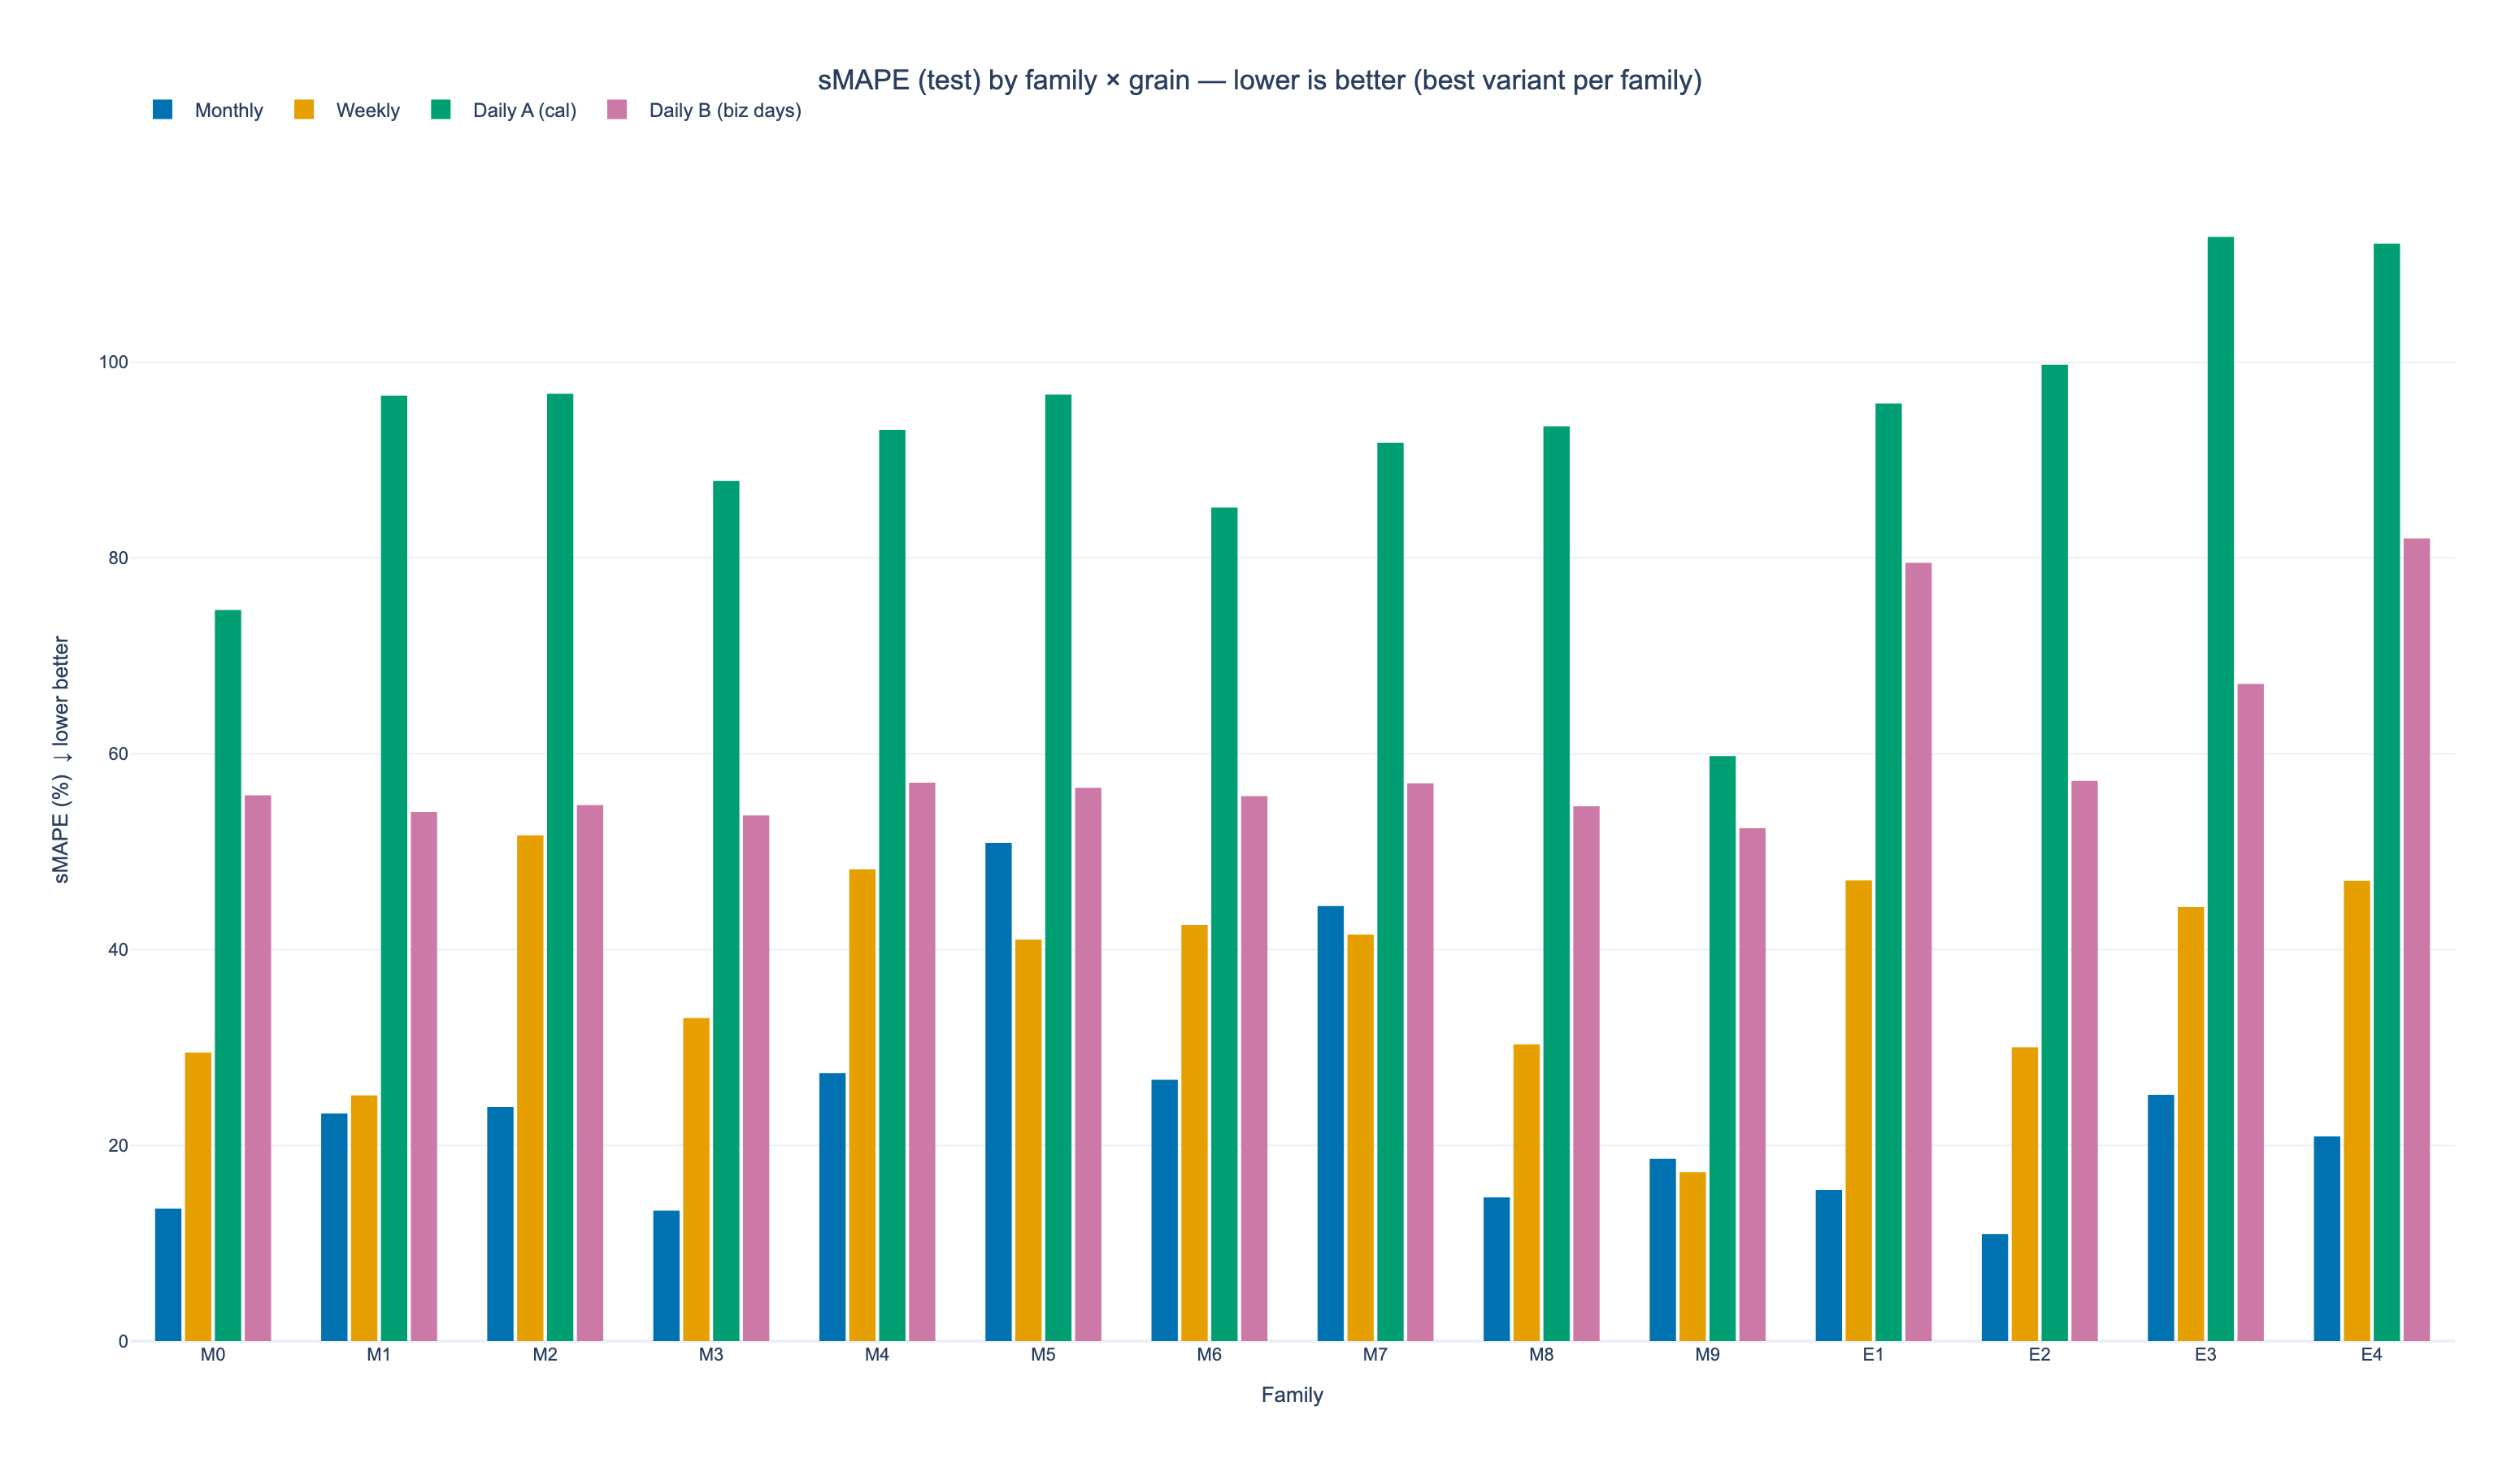

embedded -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_compare_smape_by_grain.png


**SS_sMAPE by family × grain — higher is better**  
`paper_v1_discussion_compare_skill_by_grain`

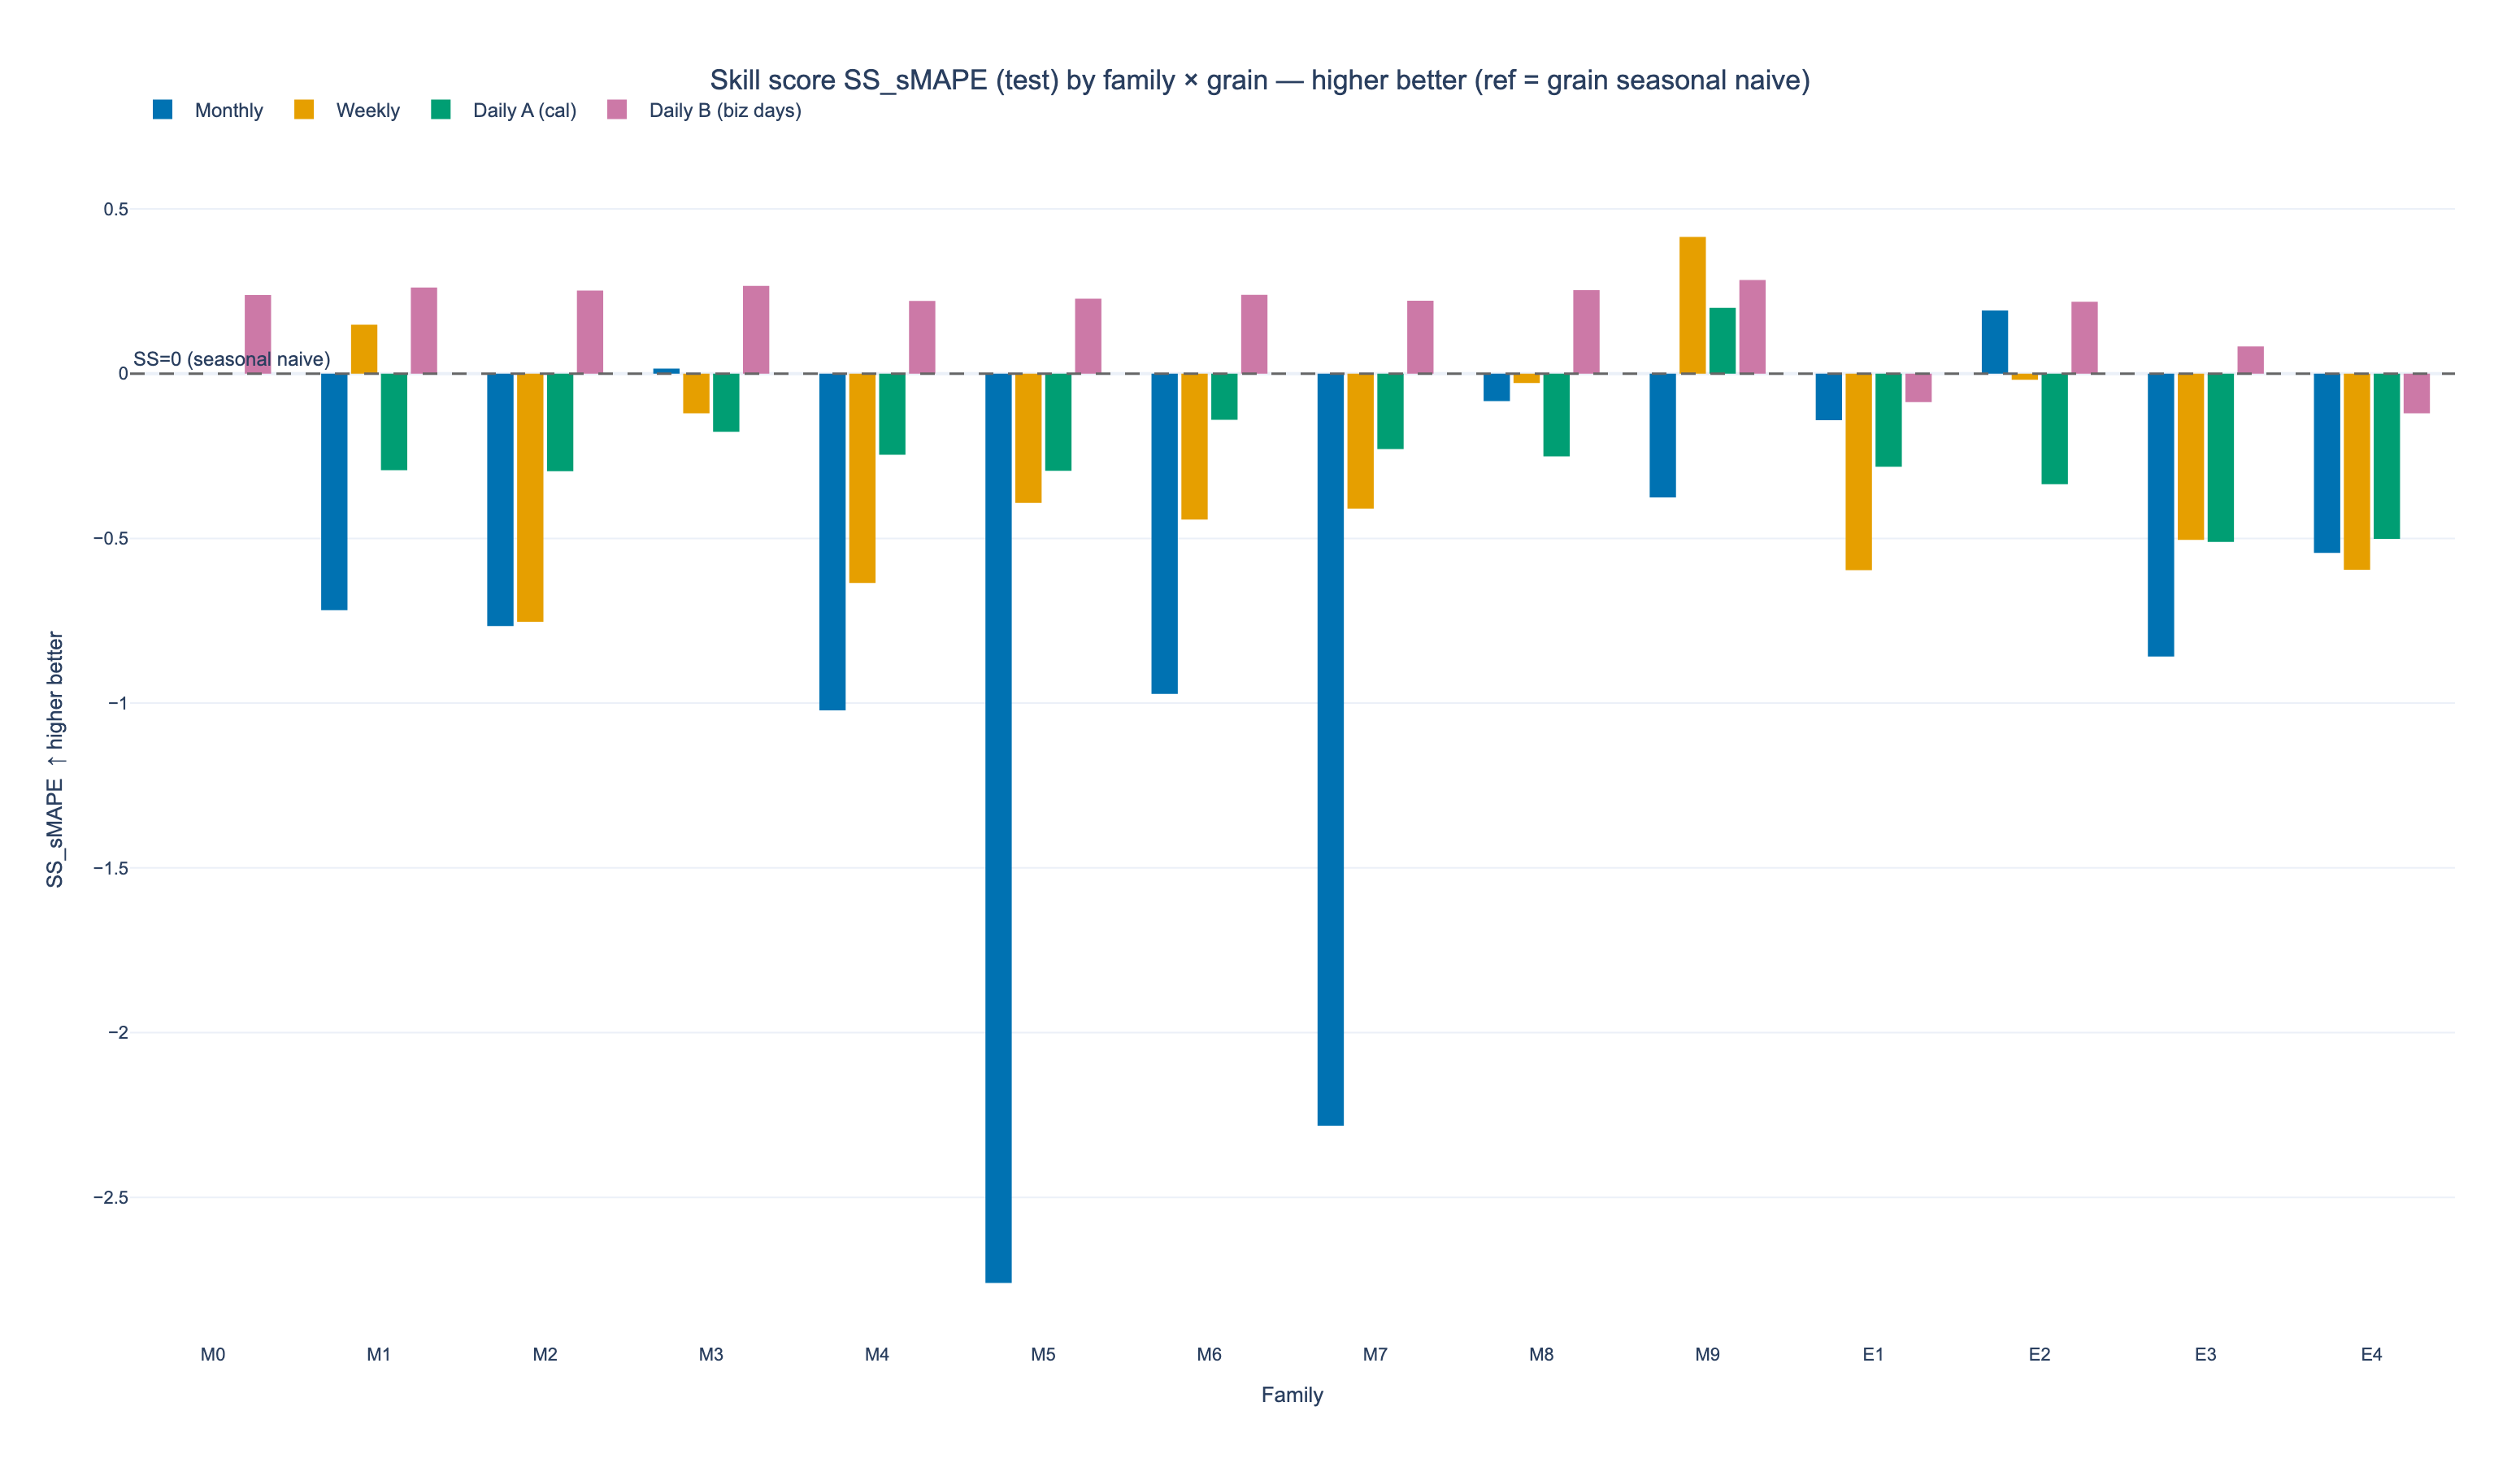

embedded -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_compare_skill_by_grain.png


**Ablation A vs B — sMAPE — lower is better**  
`paper_v1_discussion_compare_ablation_smape`

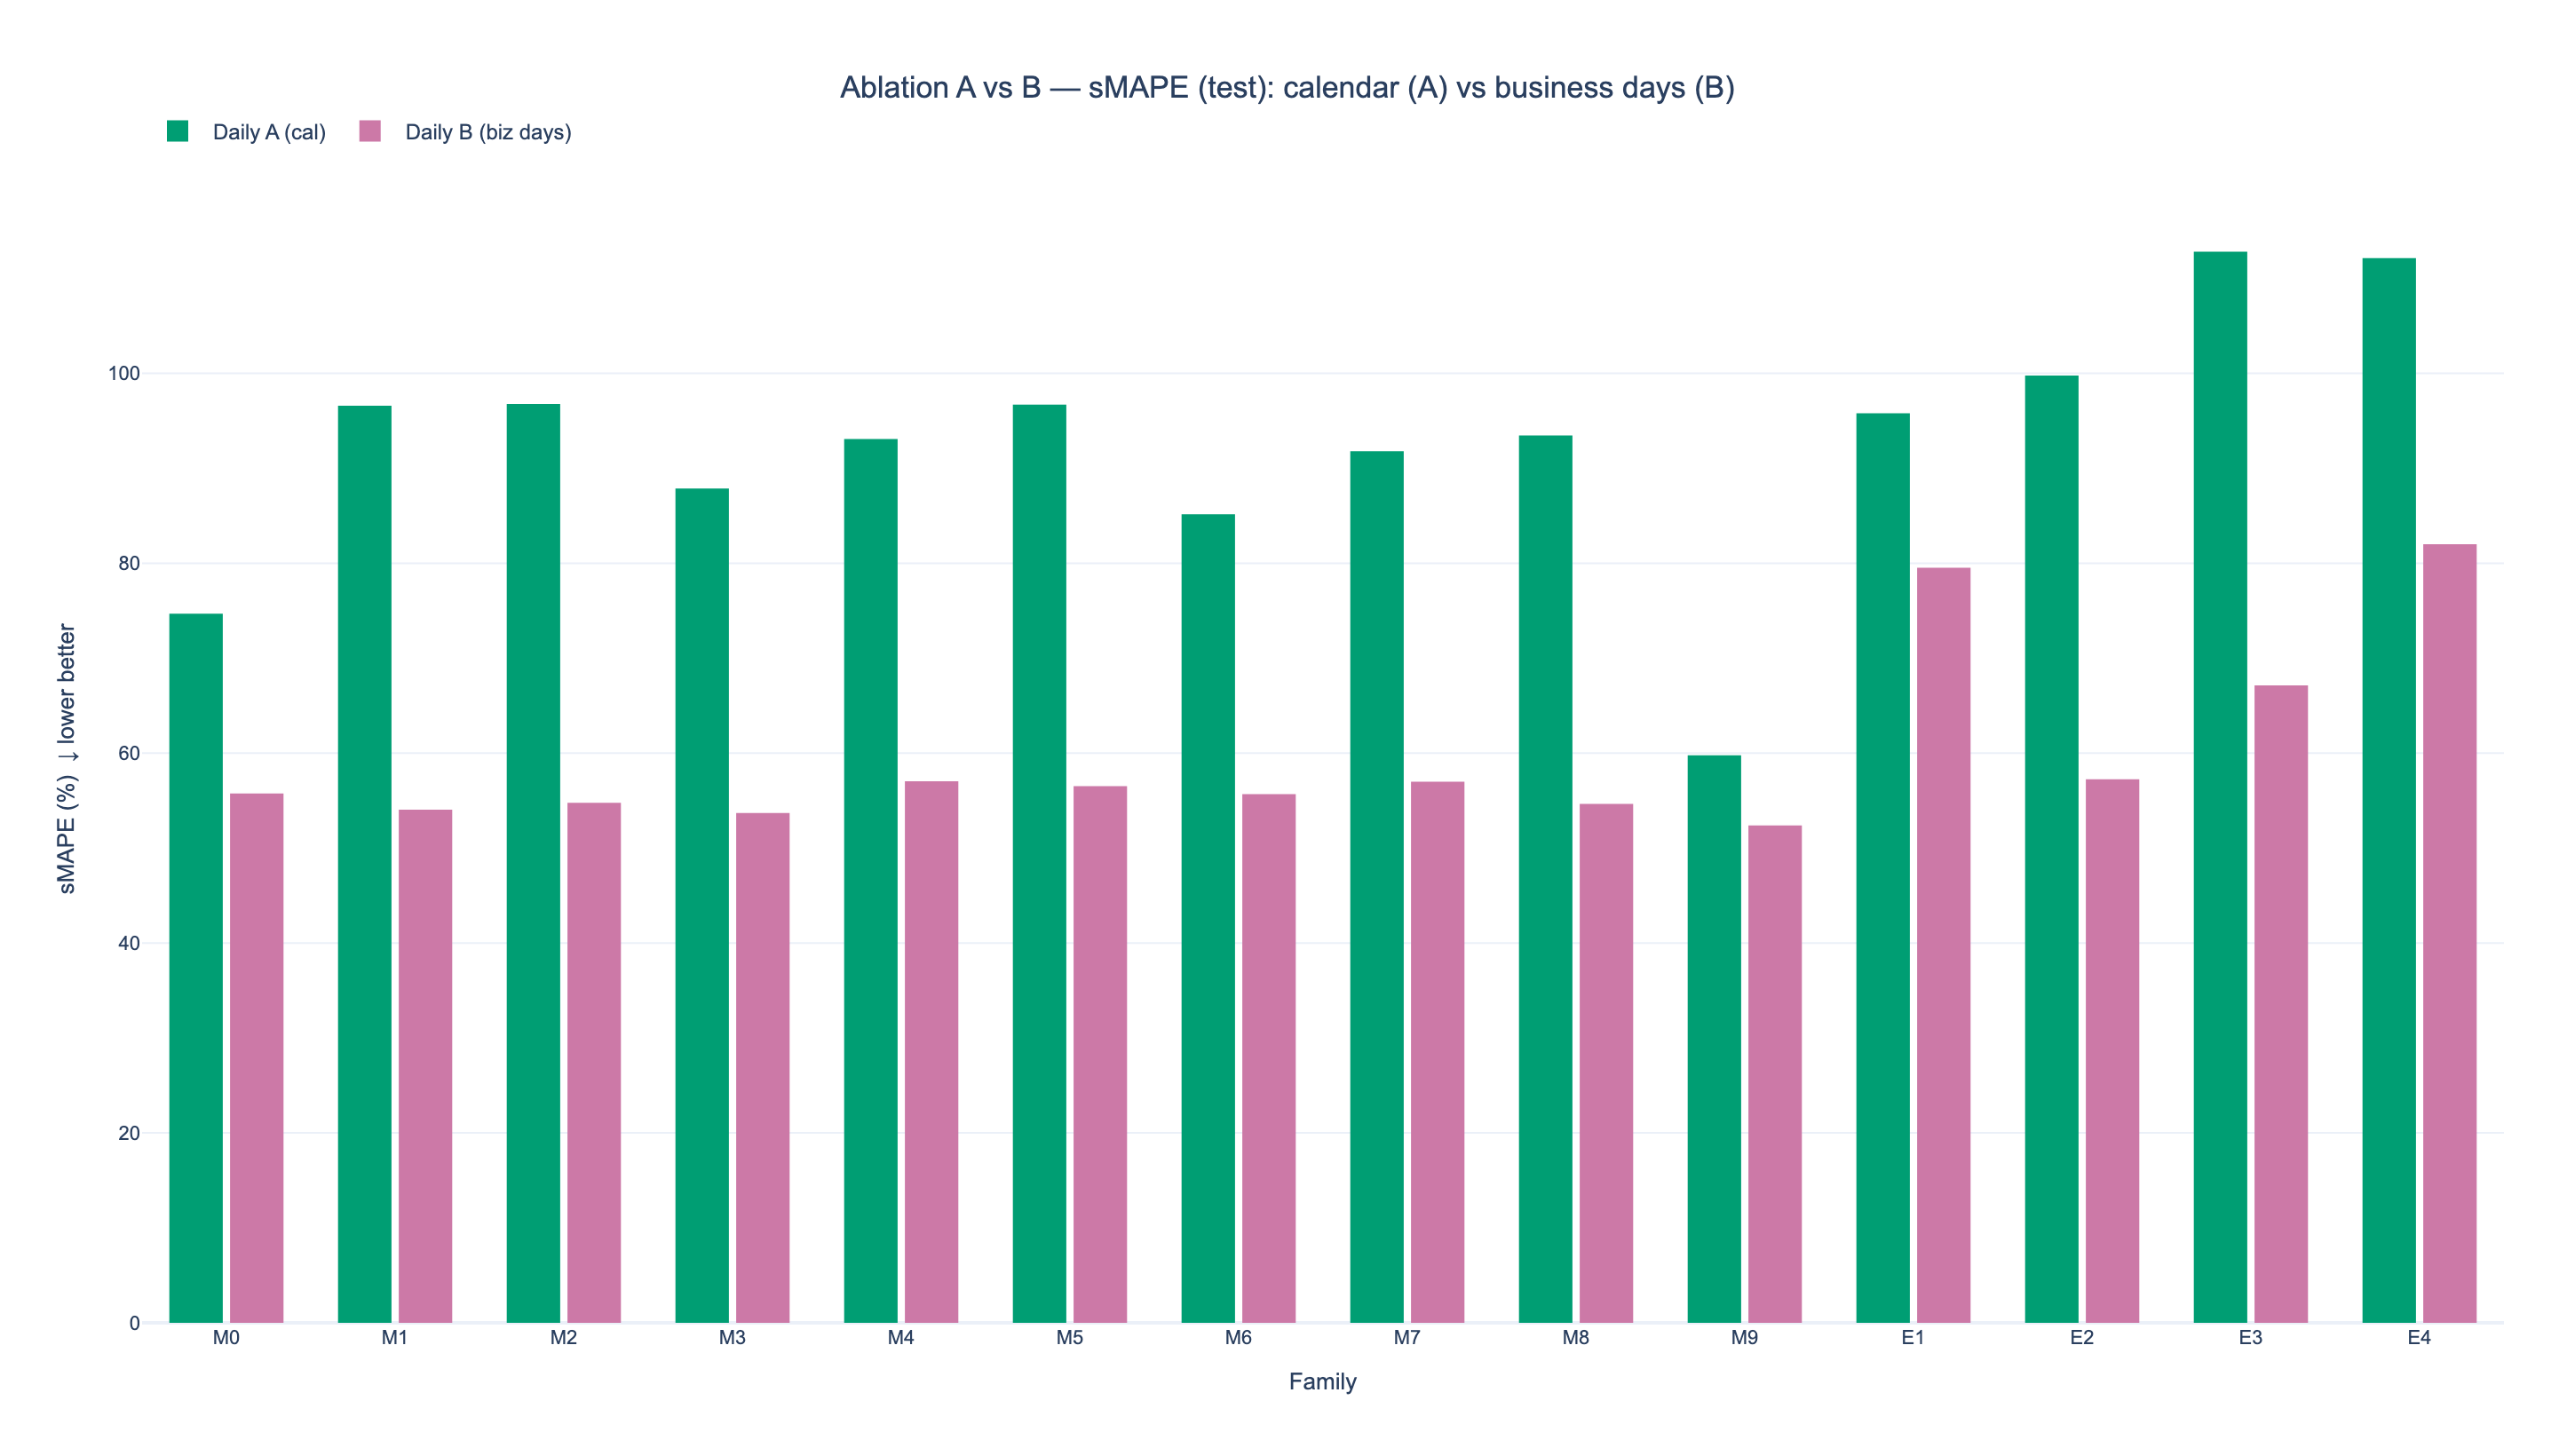

embedded -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_compare_ablation_smape.png


**Ablation A vs B — SS_sMAPE — higher is better**  
`paper_v1_discussion_compare_ablation_skill`

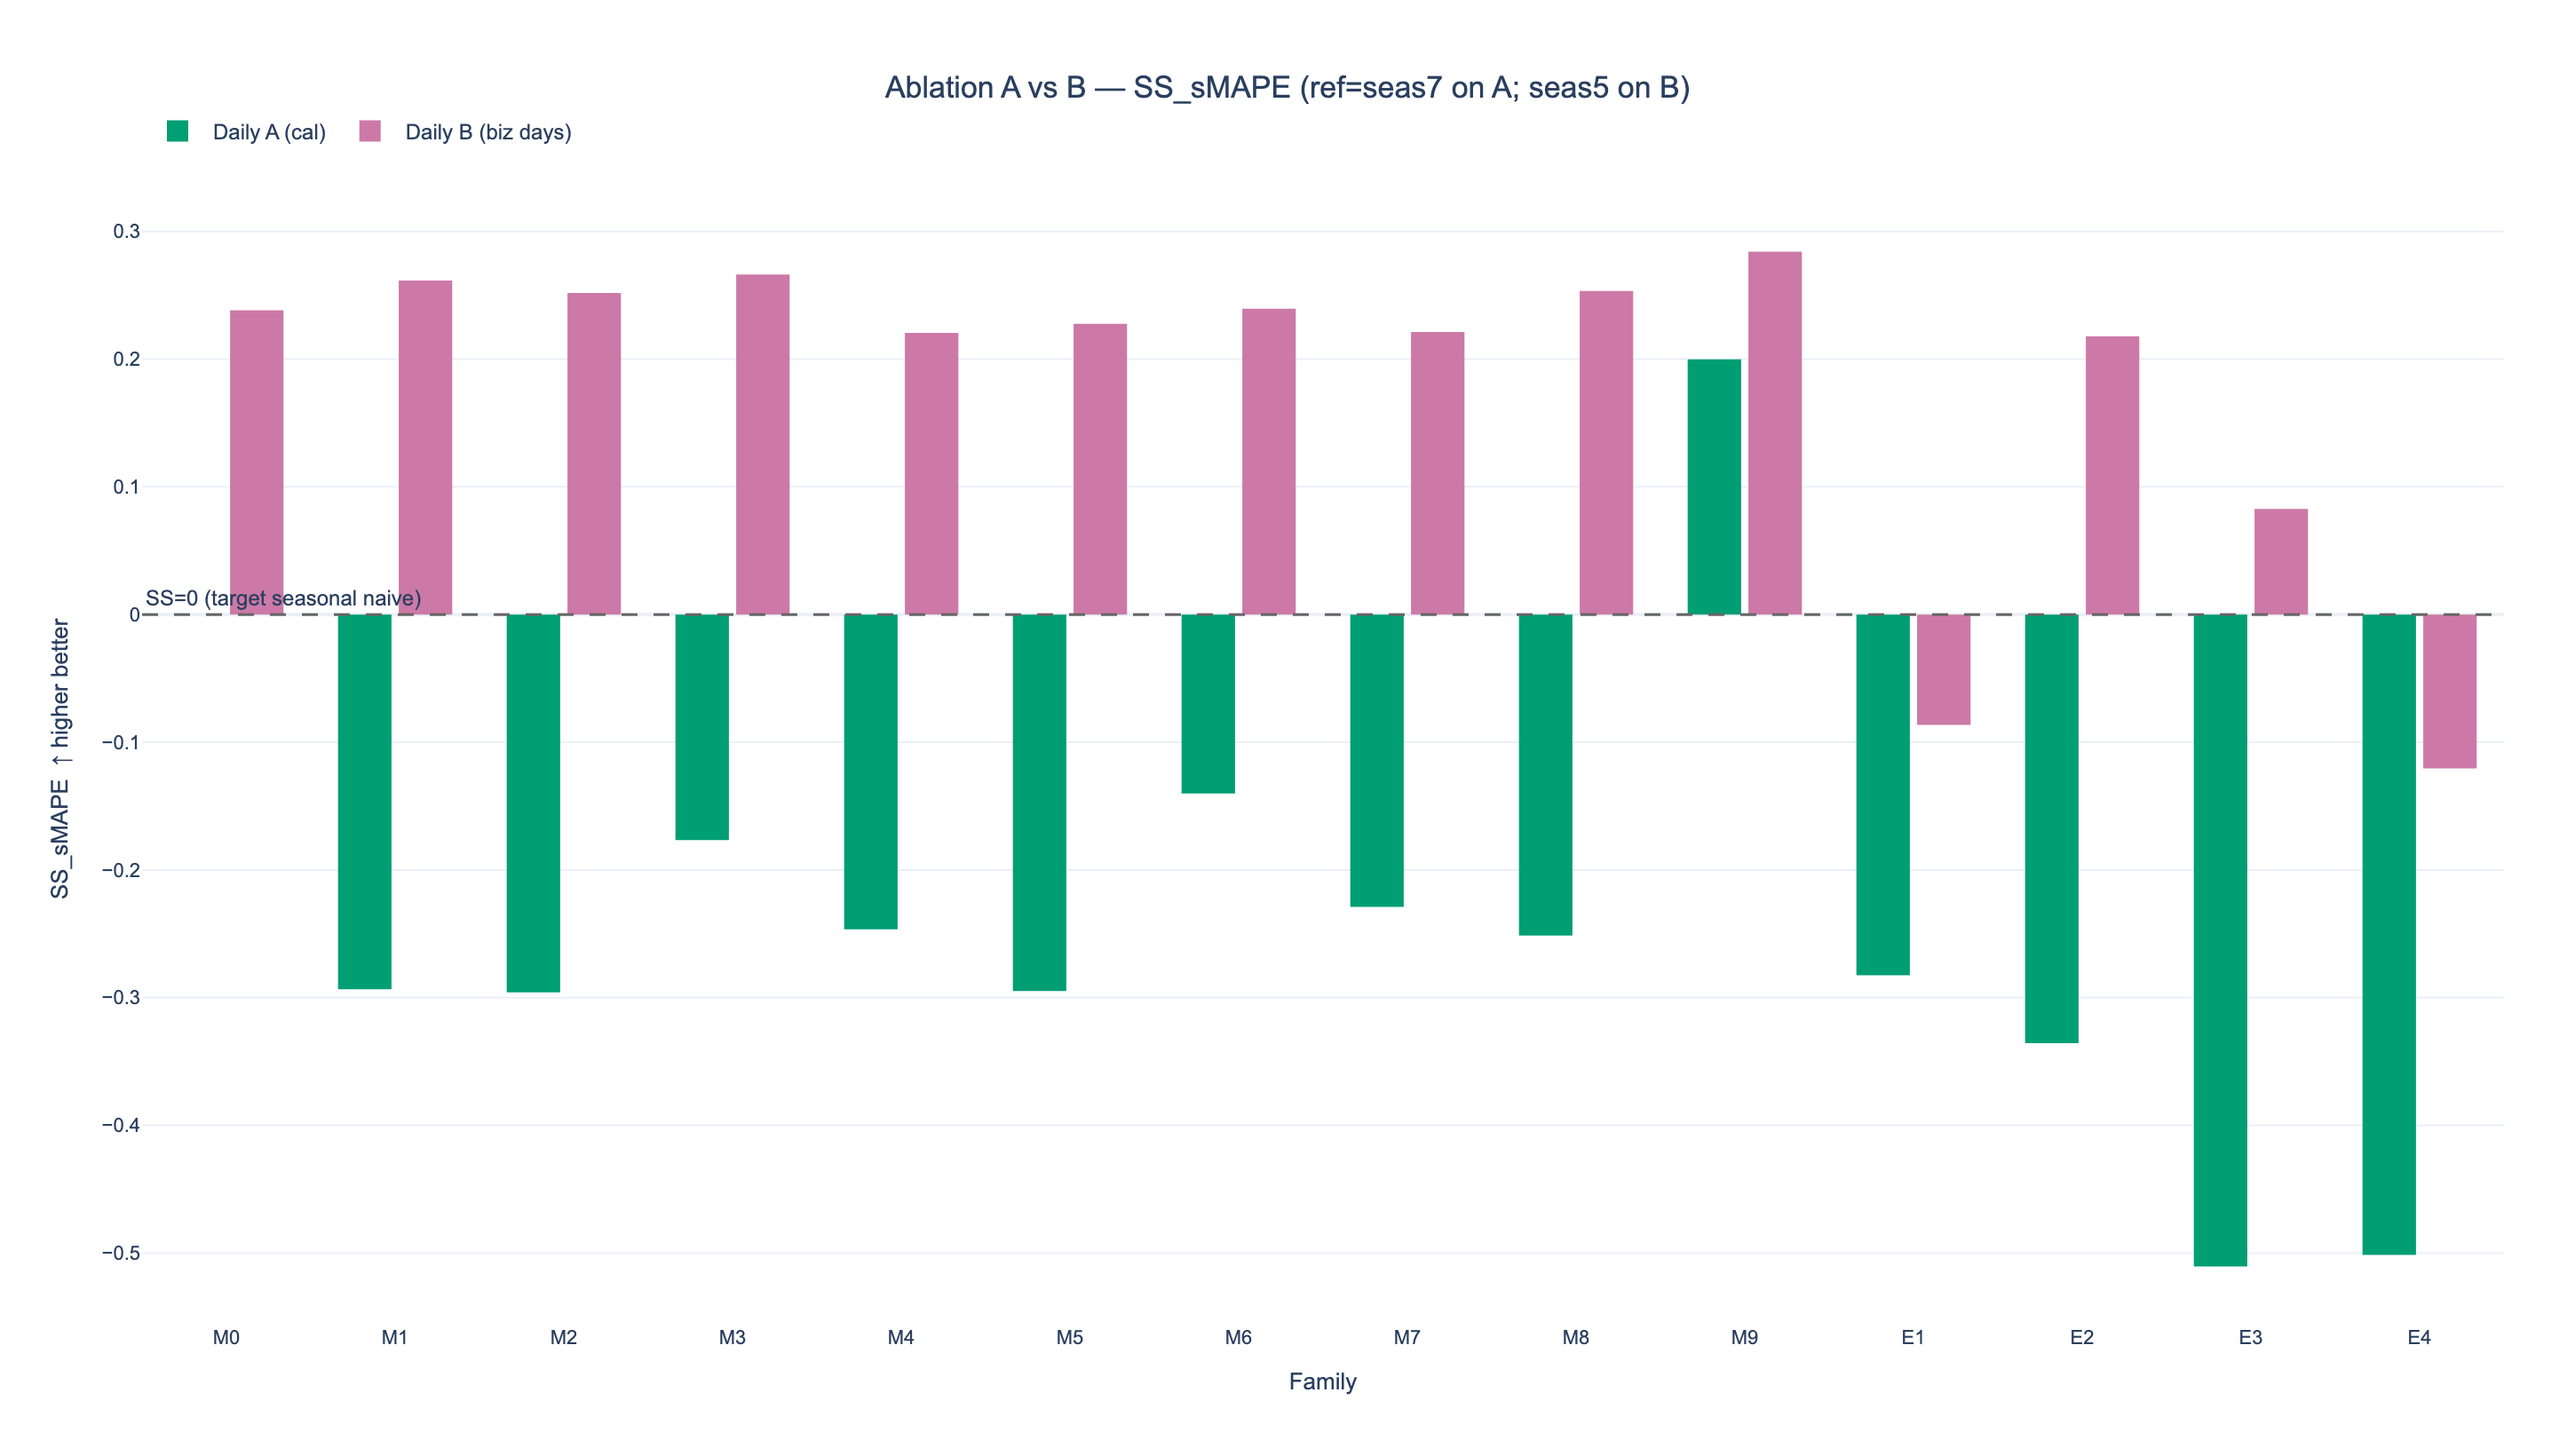

embedded -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_compare_ablation_skill.png


**Ranking sMAPE — facets by grain**  
`paper_v1_discussion_ranked_smape_facets`

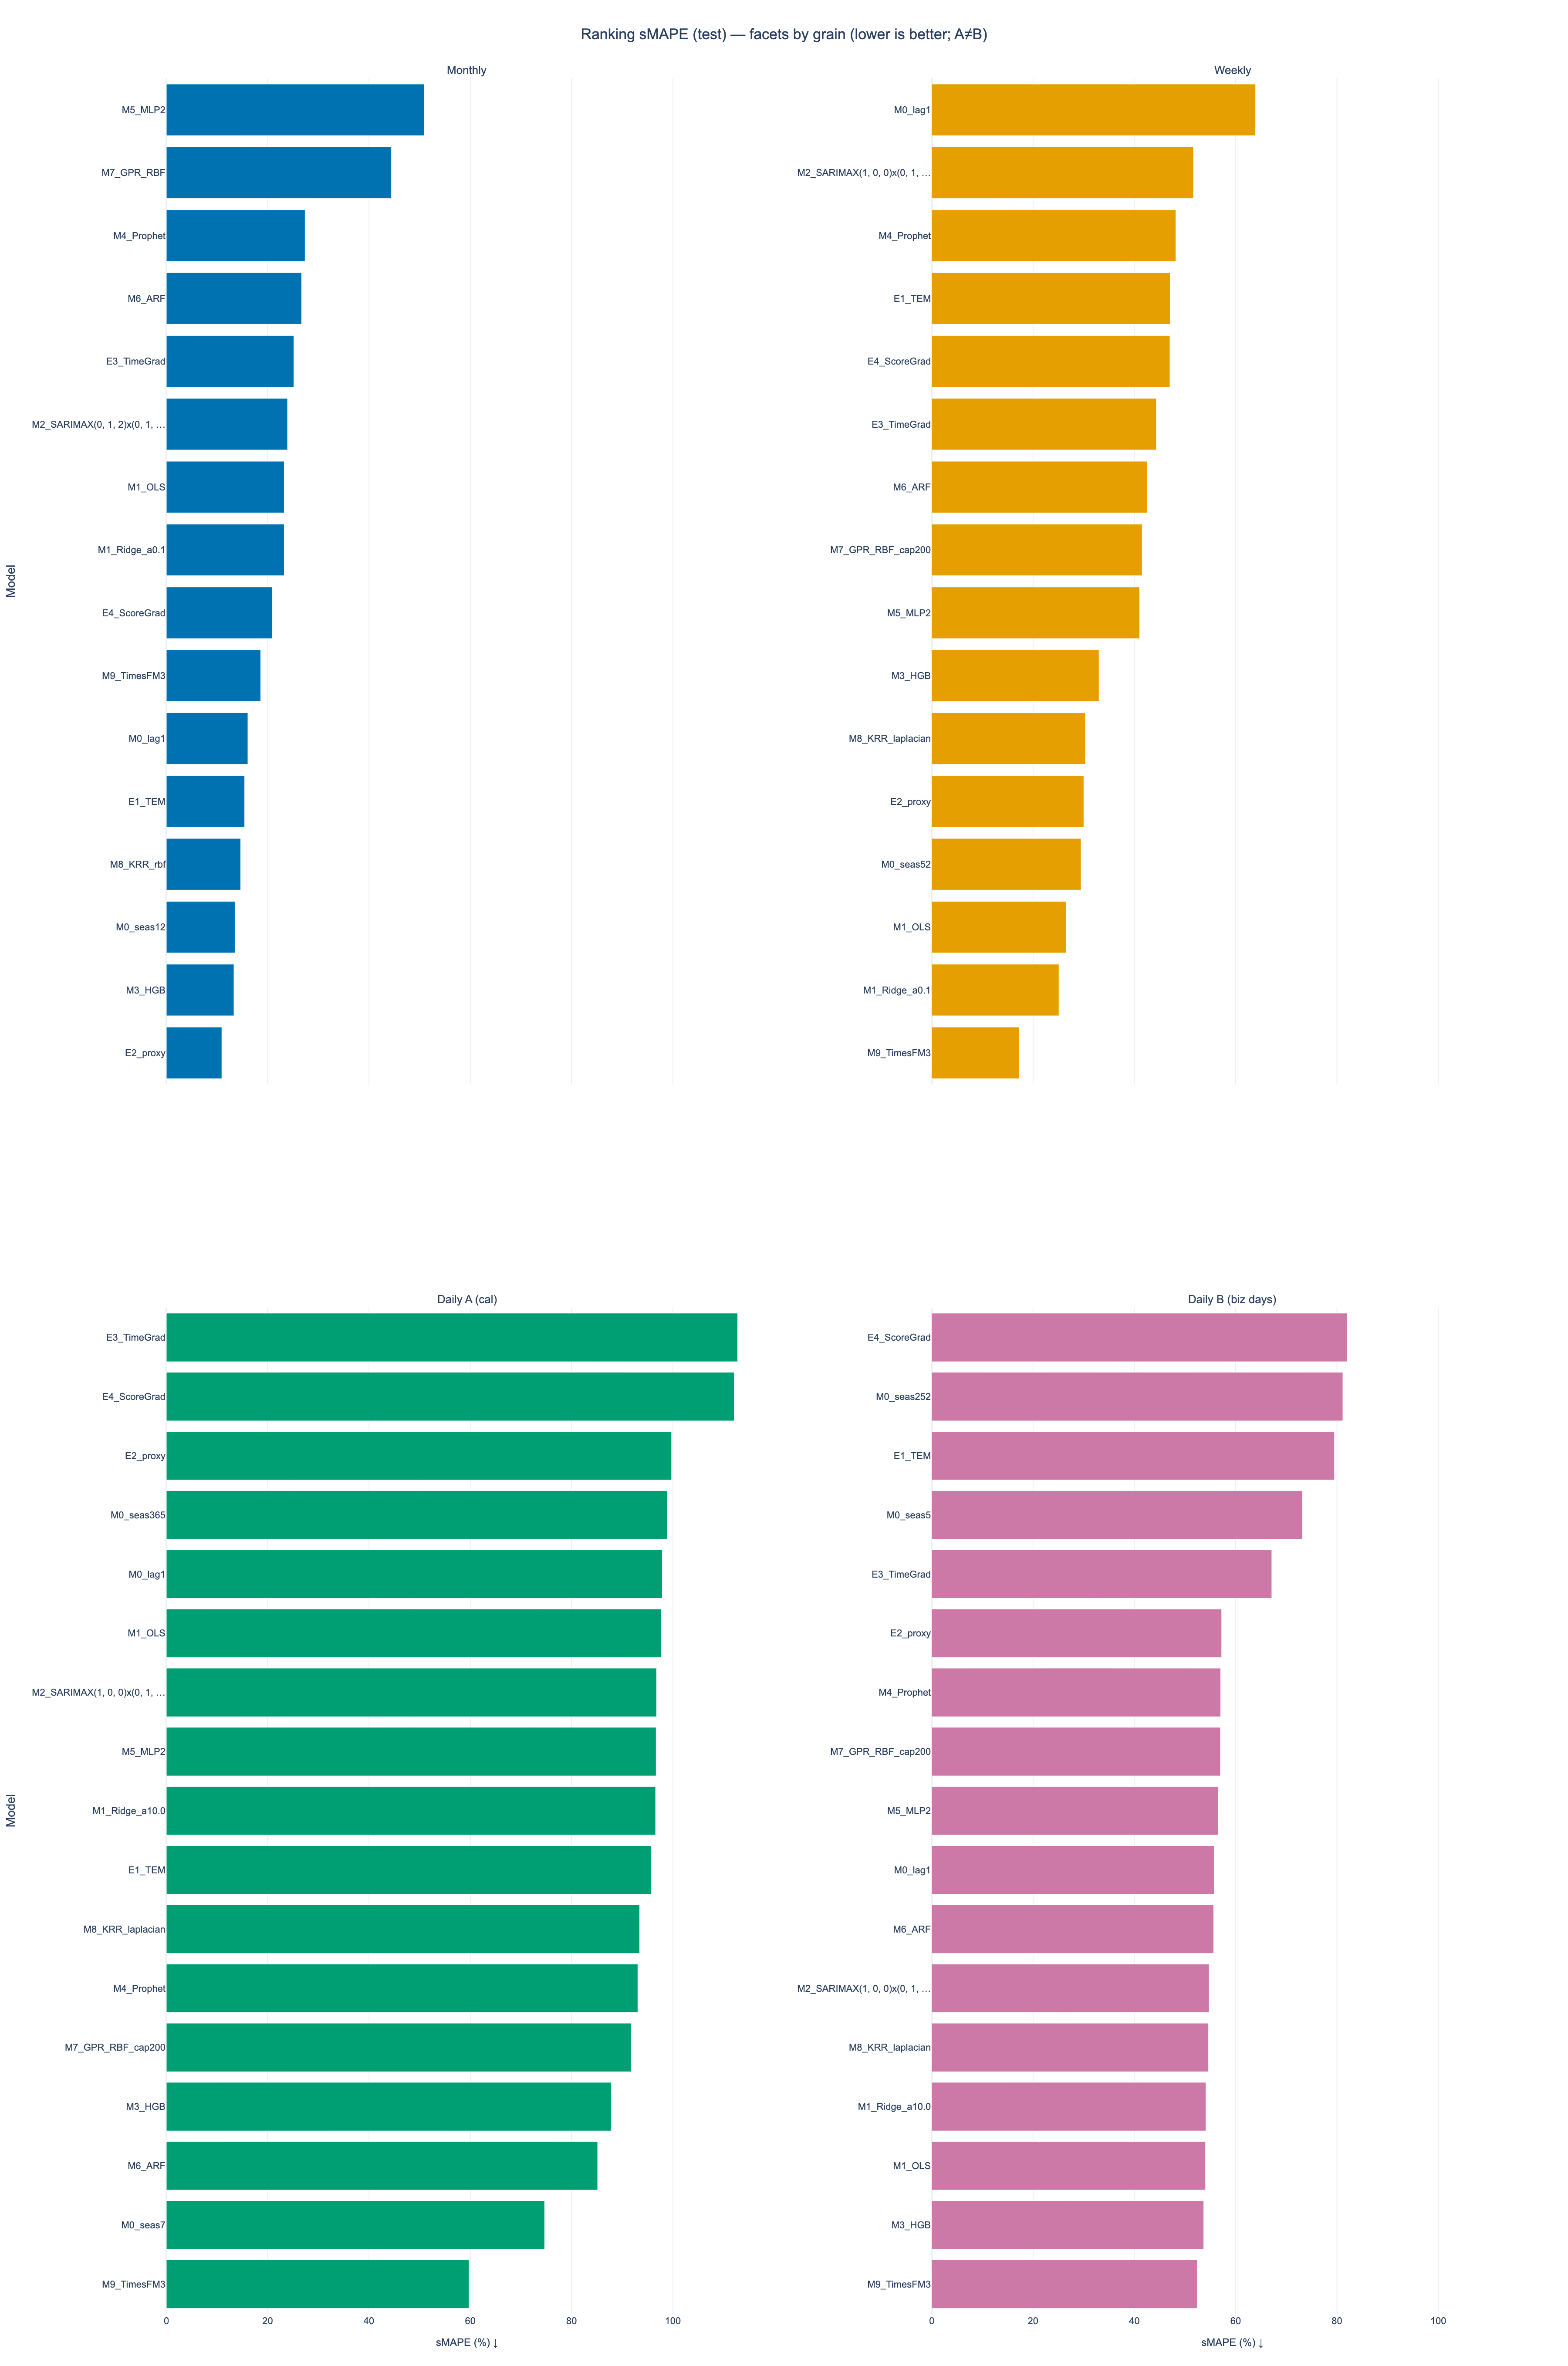

embedded -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_ranked_smape_facets.png


**SS_sMAPE — facets by grain**  
`paper_v1_discussion_skill_score_facets`

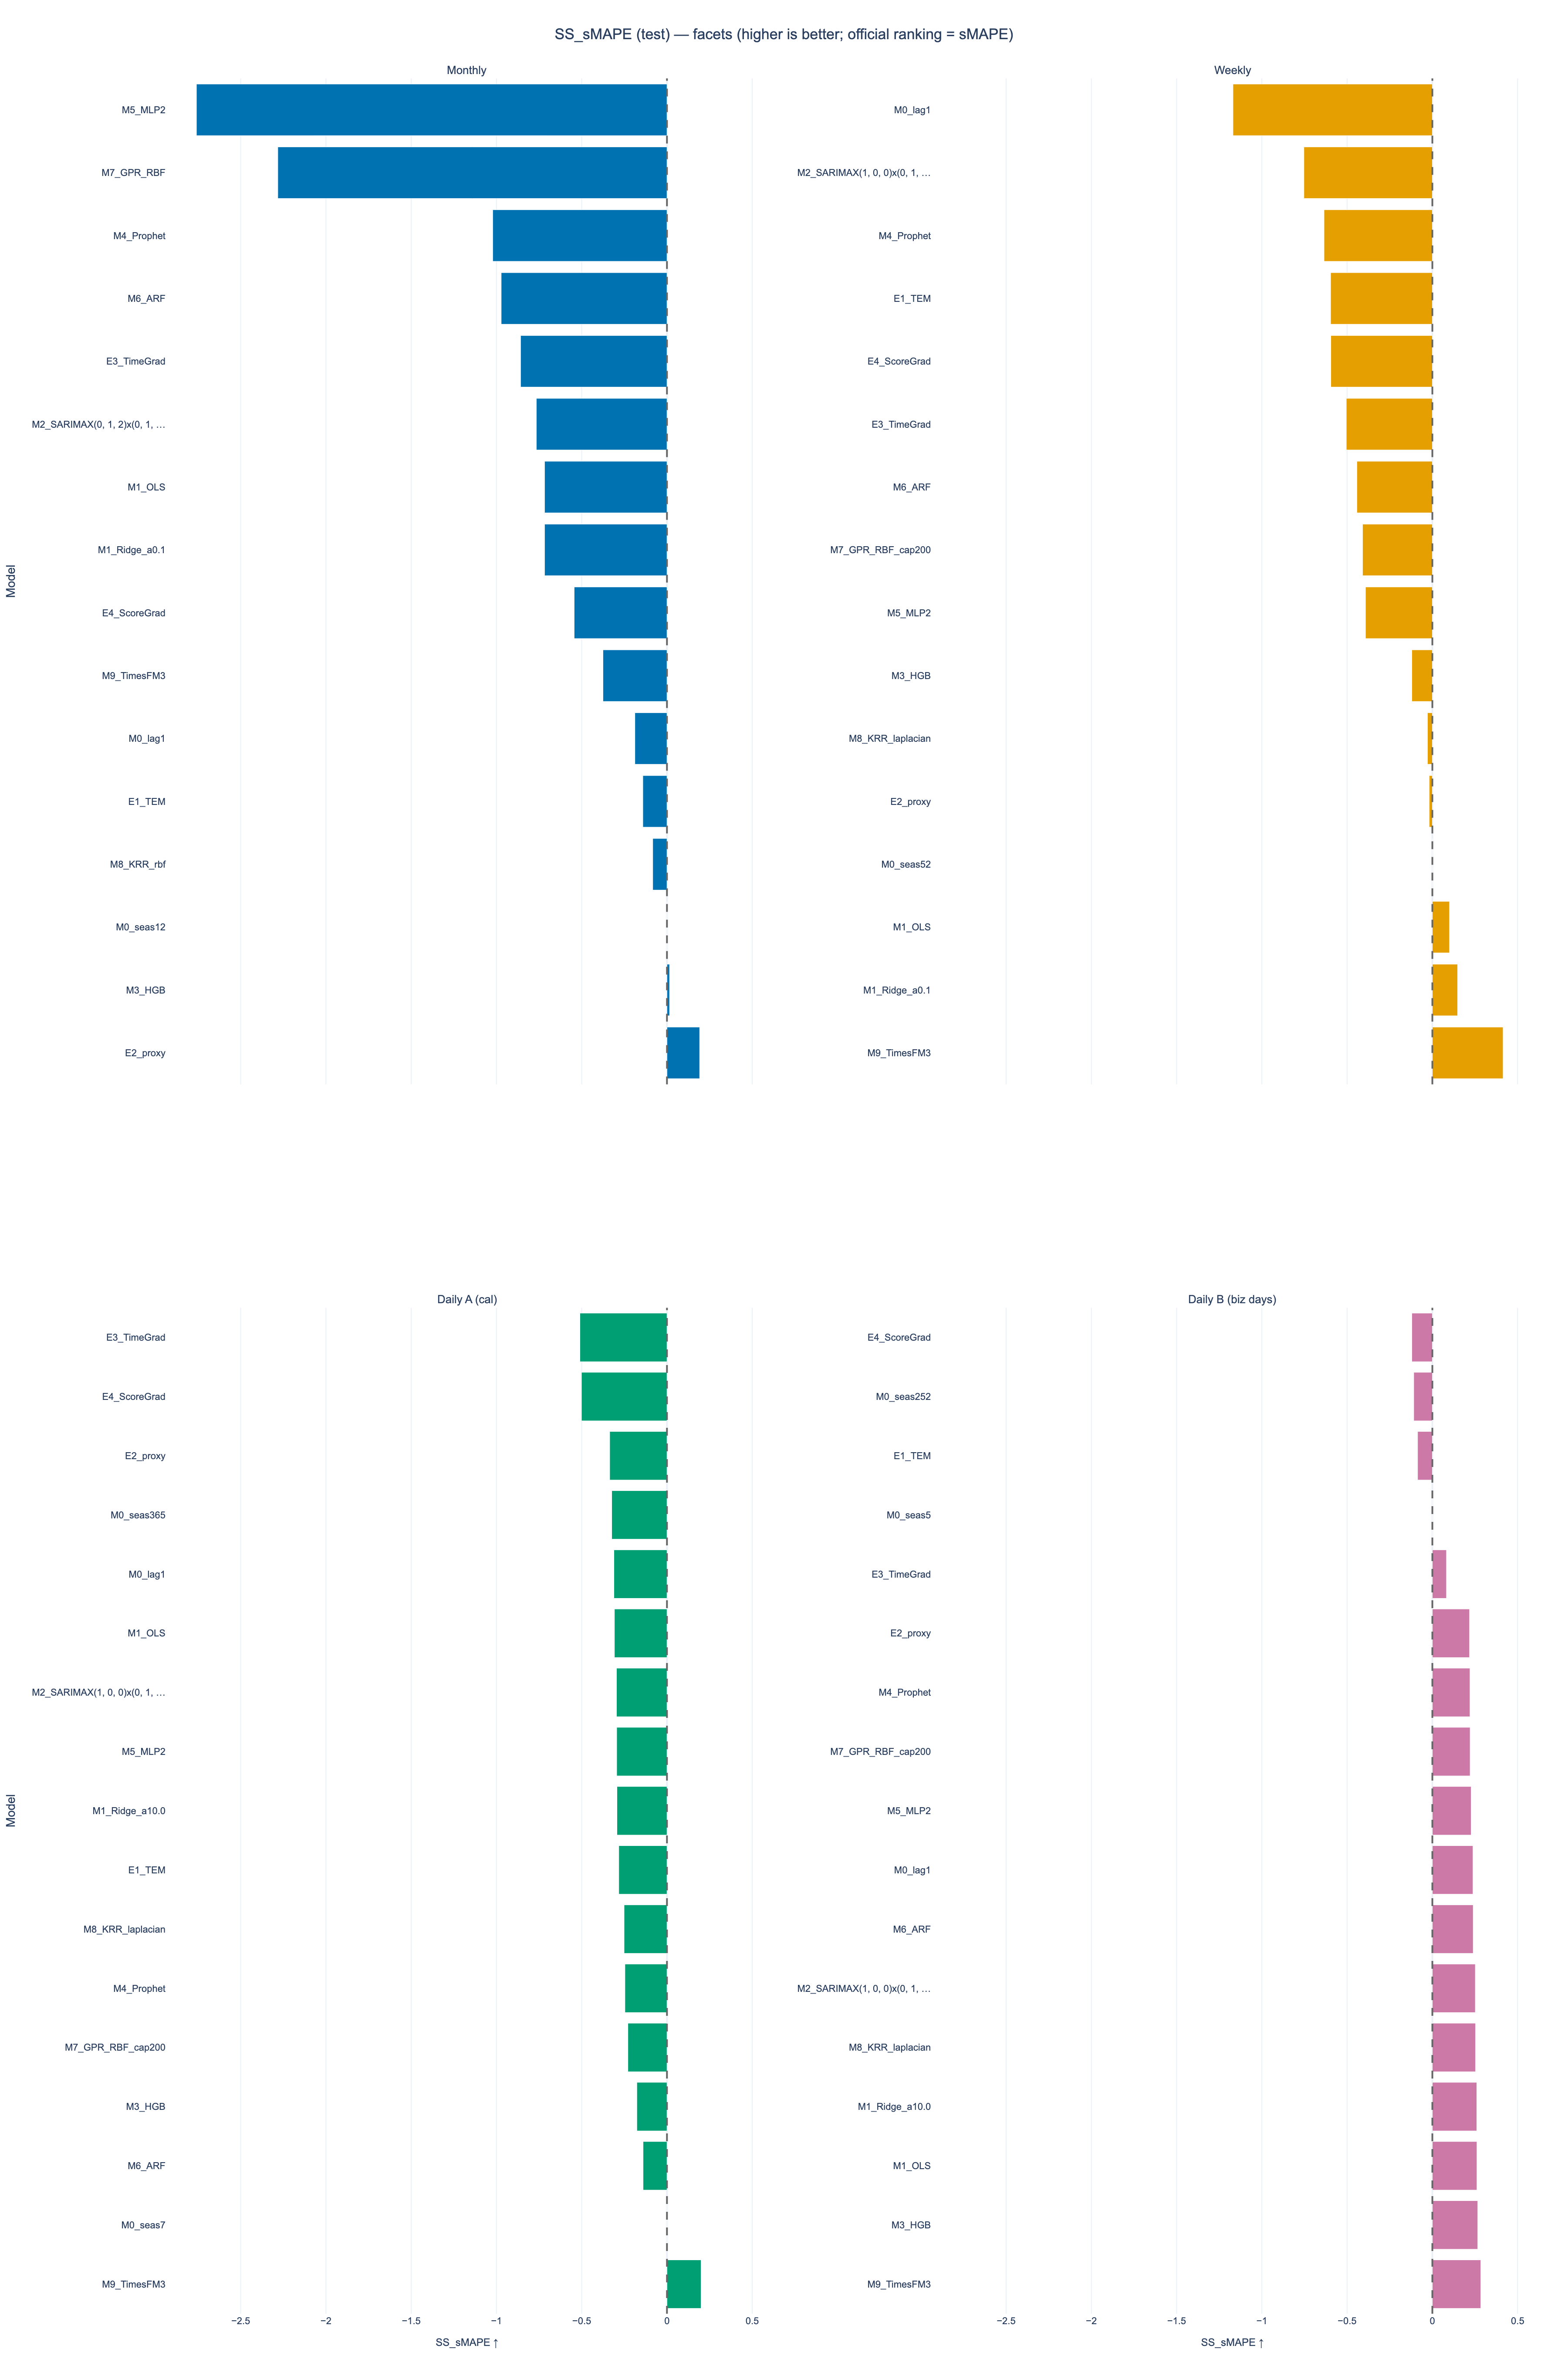

embedded -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_skill_score_facets.png


**Pred vs actual — top models by grain (2×2)**  
`paper_v1_discussion_pred_vs_actual_top`

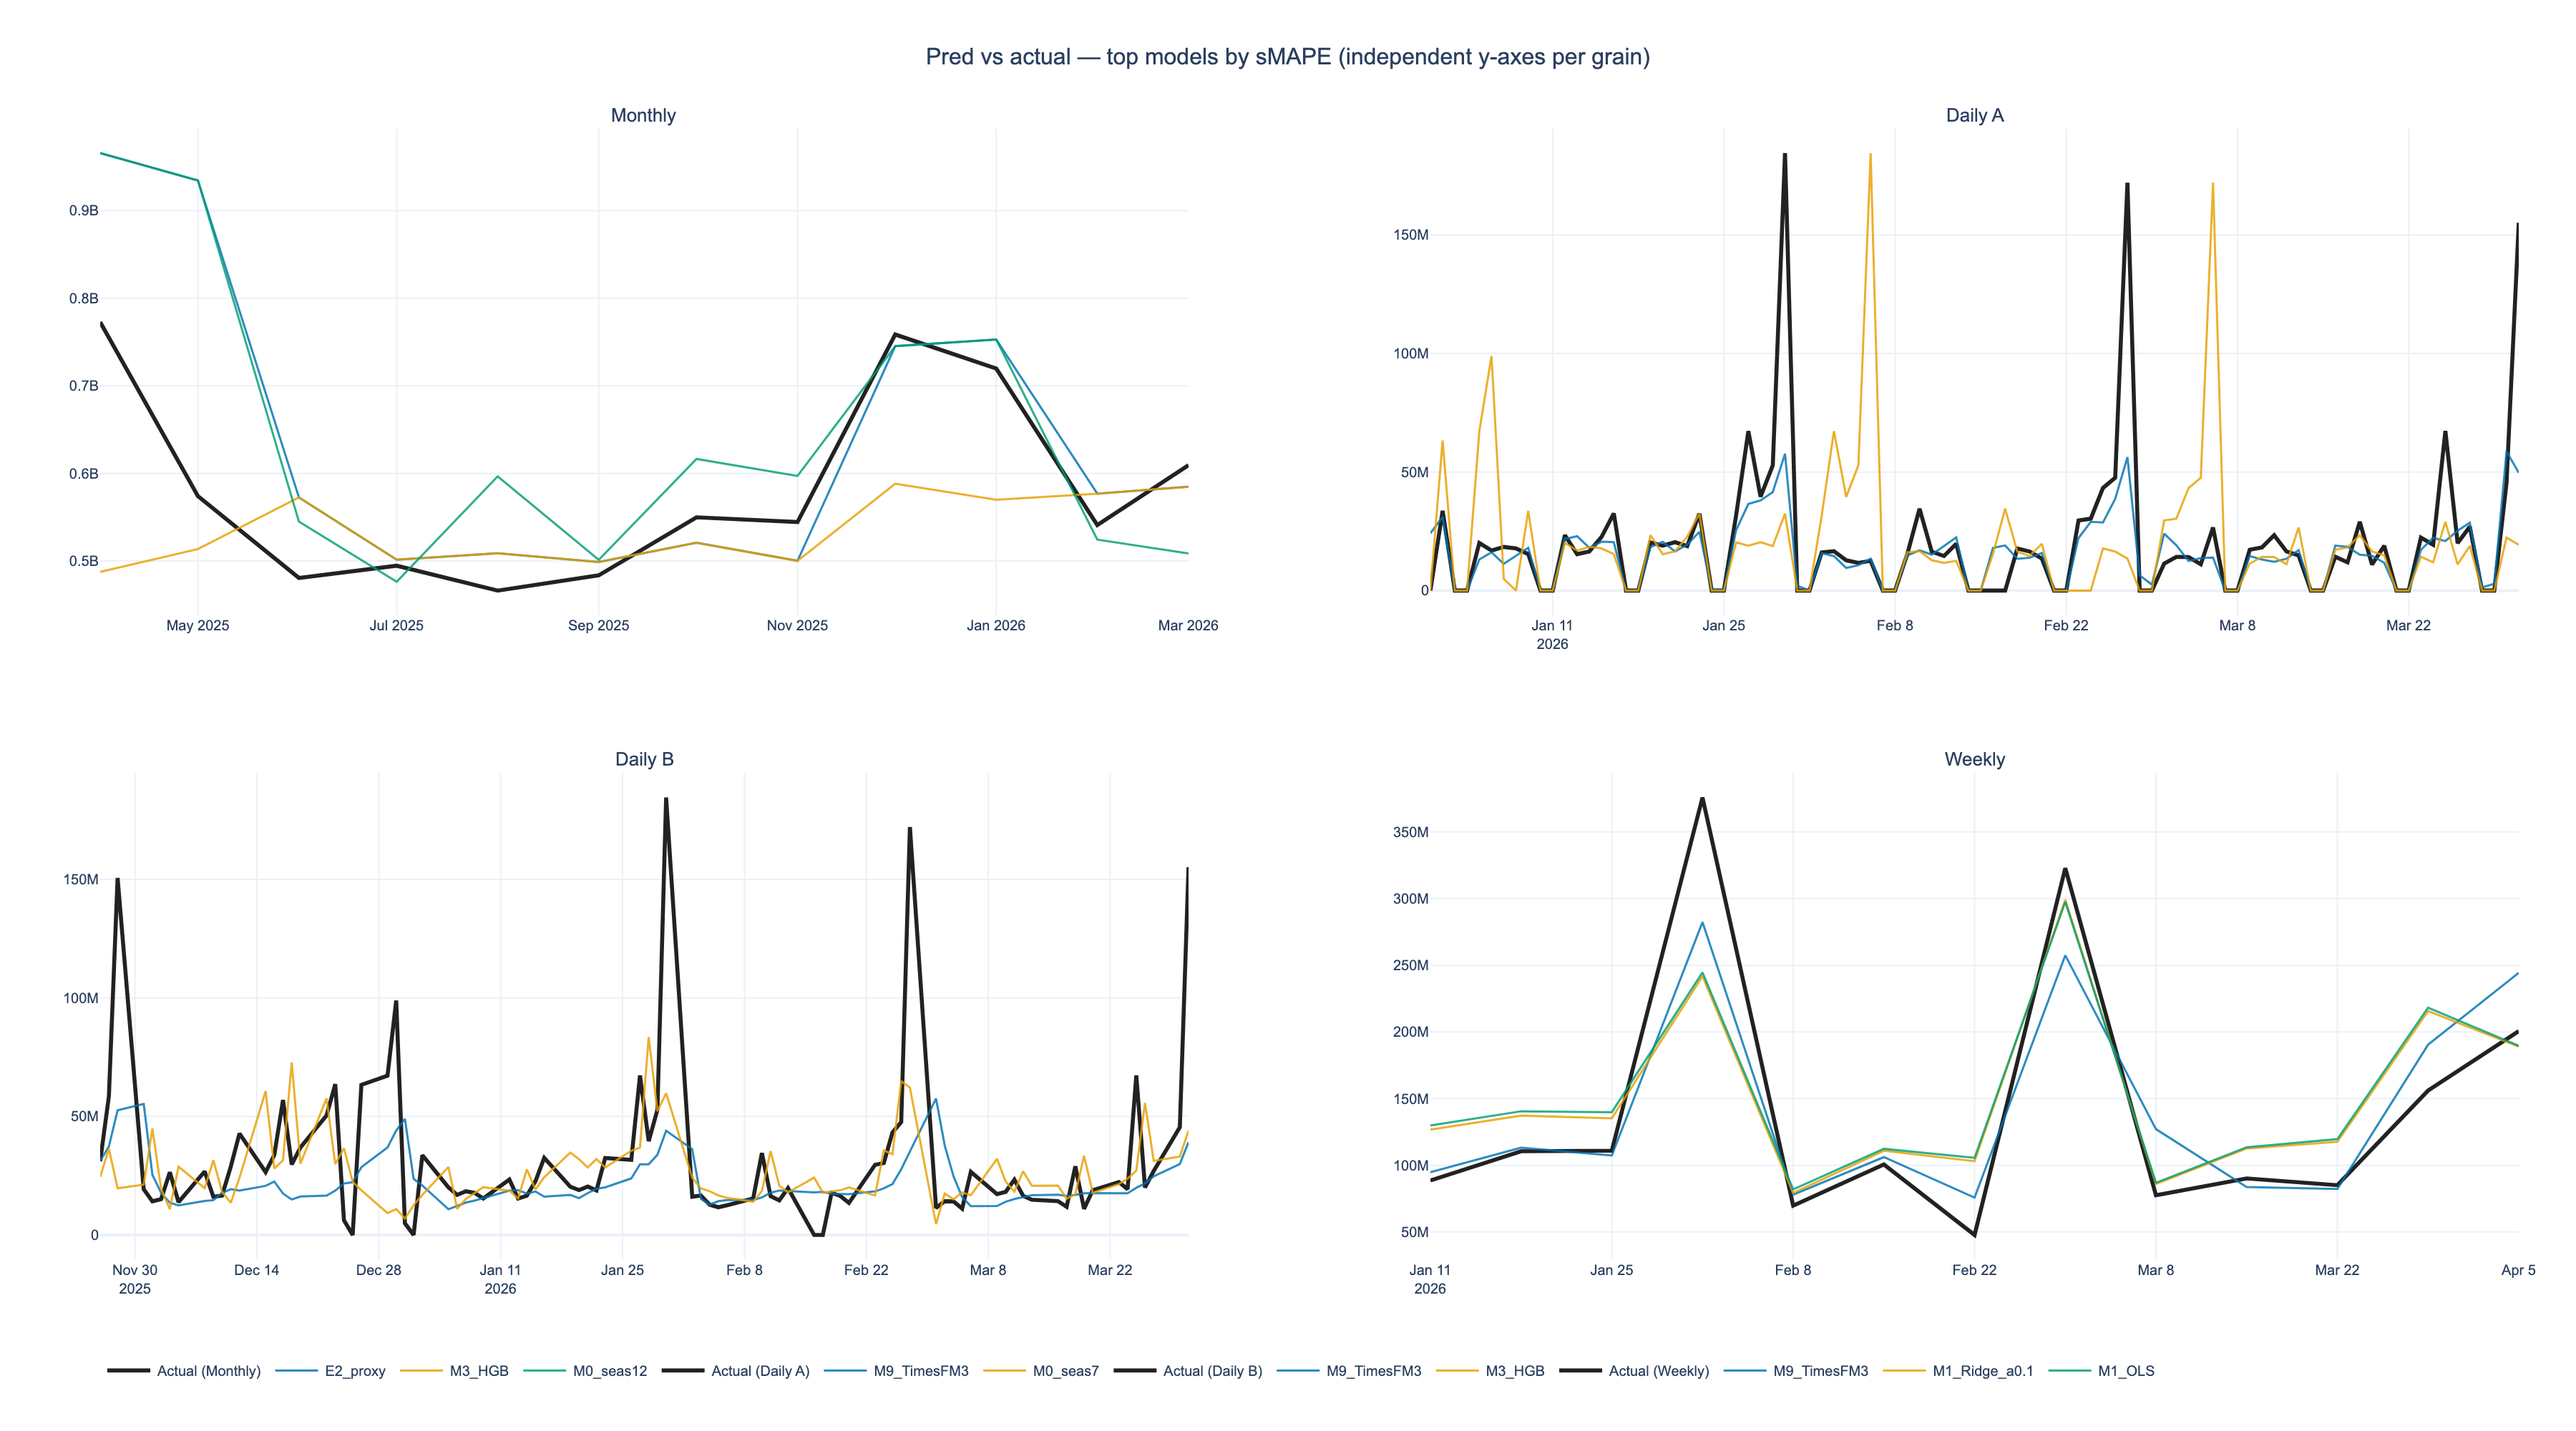

embedded -> mono:/projects/monitoramento/output/figures/articles/arrecadacao_forecast_paper_v1/paper_v1_discussion_pred_vs_actual_top.png


In [6]:
# Static PNG fallback for viewers without Plotly widget
from IPython.display import Image, display, Markdown

_COMPARE_STEMS = [
    ("paper_v1_discussion_compare_smape_by_grain", "sMAPE by family × grain — lower is better"),
    ("paper_v1_discussion_compare_skill_by_grain", "SS_sMAPE by family × grain — higher is better"),
    ("paper_v1_discussion_compare_ablation_smape", "Ablation A vs B — sMAPE — lower is better"),
    ("paper_v1_discussion_compare_ablation_skill", "Ablation A vs B — SS_sMAPE — higher is better"),
    ("paper_v1_discussion_ranked_smape_facets", "Ranking sMAPE — facets by grain"),
    ("paper_v1_discussion_skill_score_facets", "SS_sMAPE — facets by grain"),
    ("paper_v1_discussion_pred_vs_actual_top", "Pred vs actual — top models by grain (2×2)"),
]
for stem, caption in _COMPARE_STEMS:
    png = FIG_DIR / f"{stem}.png"
    display(Markdown(f"**{caption}**  \n`{stem}`"))
    if png.exists():
        display(Image(filename=str(png)))
        print("embedded ->", public_path_label(png))
    else:
        print("MISSING PNG:", public_path_label(png))


## 9b. Discussion: monitoring instrument

Findings from the ablation re-run **A (calendar) vs B (business days)** + SS_sMAPE (Murphy form on sMAPE); E1 = TimesNet + `Exp_Main_Energy` (2026-09-28 BRT; official ranking per grain = **sMAPE(test)** — **lower is better**; complementary SS — **higher is better**). Monthly/weekly for this freeze = prior CSV (grains skipped).

**Captions (SS / sMAPE).** Skill score: **higher is better** ($SS \gt 0$ beats the grain's seasonal naive; $y=0$ line). sMAPE: **lower is better**. Figs: `paper_v1_discussion_compare_smape_by_grain`, `…_skill_by_grain`, `…_ablation_smape`, `…_ablation_skill`.

**Daily A — calendar** (val/test=90/90; seas7; ranking A = sMAPE on **all** days incl. zeros):
1. TimesFM ≈59.8 / SS≈0.20
2. seasonal naive lag-7 ≈74.7 / SS=0
3. ARF ≈85.1 / SS≈−0.14

Complementary **non-official** sMAPE$_{y \gt 0}$ / SS$_{y \gt 0}$ (same forecasts, $y \gt 0$ days only): TimesFM ≈29.9 / SS≈0.58; HGB ≈34.6 / SS≈0.51; GPR ≈40.3 / SS≈0.43. File: `metrics_daily_test_smape_positive_side.csv`. **Does not** replace ranking A.

**Daily B — business days** (n=2672 Mon–Fri; BR holidays **not** removed; val/test=90/90; seas5; prefix `BD_`; train=[0,2492) val=[2492,2582) test=[2582,2672)):
1. TimesFM ≈52.4 / SS≈0.28
2. HGB ≈53.7 / SS≈0.27
3. OLS ≈54.1 / SS≈0.26

Naive seas5 is the $SS = 0$ reference in this grain. Soft-fails B: none (M0–M9/E1–E4 ok; E1 backend TimesNet+Exp_Main_Energy, coverage_test=1.0). **SS note on B:** many $SS \gt 0$ are expected (not a bug) — seas5 is a weak baseline (lag-1 already beats it); SS stays vs seas5 of the grain, not vs lag-1.

**Interpretation A vs B.** B is another *target* (business-hours series), not cherry-picking A's holdout. Absolute sMAPE on B is lower (fewer weekend zeros), but the ordering changes (e.g. seasonal naive leaves the top-3 on B; HGB/OLS rise).

**Operational:** seasonal baseline remains cheap ($SS = 0$ by construction in each grain). TimesFM leads A and B on sMAPE in this freeze. Proxy E2 ≠ TEM. Teach scaffold: `.local/notes/2026-09-28-tem-teach-outline.md`.


## 10. Conclusion

Under a single M0–M9 / E1–E4 protocol across monthly, calendar-daily (A), business-daily (B), and weekly grains, rankings are grain-dependent and should not be collapsed into one “best model.”

On the **monthly** panel in this freeze, the E2 energy *proxy* leads on sMAPE (≈10.9) but **E2 ≠ TEM**; seasonal naive and HGB remain competitive, and selective E1 (TEM) is not uniformly best at that grain.

On **calendar daily A**, TimesFM leads (≈59.8 sMAPE); most families show $SS \lt 0$ versus seas7, weekend/zero days dominate the official ranking, and complementary sMAPE$_{y \gt 0}$ is descriptive only.

On **business daily B**, TimesFM / HGB / OLS form the top cluster; many $SS \gt 0$ values reflect a weak seas5 baseline (not a skill-score formula bug).

On **weekly** GARE, TimesFM shows strong skill versus seas52.

**Operational takeaway.** One protocol and one runner across grains keep comparisons fair: seasonal naive is the cheap $SS = 0$ reference by construction; energy-selective **E1** is a monitoring-instrument *candidate* when coverage/abstention are reported; the E2 proxy stays an ablation, never labeled TEM.

**Forward.** Preserve multi-grain freeze reproducibility; tighten a fairer E1 daily compute budget; strengthen B holiday handling and baseline robustness; and prepare a venue draft from this scaffold.

**Takeaways**
- Grain-specific leaders: do not average ranks across monthly / A / B / weekly.
- SS vs seasonal naive is complementary; $SS = 0$ at the grain’s seasonal by design.
- Calendar zeros (A) and weak seas5 (B) change both absolute sMAPE and ordering.
- E1 selective TEM: instrument candidate with explicit coverage; E2 proxy separate.
- Next: reproducibility freeze, E1 daily budget, B holiday/baseline, venue draft.


## 11. Limitations
- Static dump (`extracao=2026-03`), not realtime.
- Monthly panel $n$ is limited → grids and deep models risk overfitting; fine grains (daily/weekly/BD) use caps and soft-fail.
- Calendar daily: many zeros (weekends / no slip) — sMAPE includes zeros in ranking A; MAPE and sMAPE$_{y \gt 0}$ are complementary, not the official ranking.
- Business days (B): weekends removed only; BR national holidays **not** removed (Prophet `freq=B` alignment; `holidays` available but unused). Target B ≠ cherry-picking A's holdout.
- SS_sMAPE applies Murphy's form to sMAPE (not MSE); ordinal interpretation vs the grain's seasonal naive.
- E1 TEM vendor + MLP fallback; E2 is an ablation proxy — never label as TEM.
- TimesFM / Prophet / SARIMAX: dependency and soft-fail risk; see `notes` / per-grain status.


## 12. References
- Murphy, A. H. (1988). Skill Scores Based on the Mean Square Error. *Monthly Weather Review*, 116(12), 2417–2424. https://doi.org/10.1175/1520-0493(1988)116<2417:SSBOTM>2.0.CO;2
- Hyndman, R. J., & Koehler, A. B. (2006). Another look at measures of forecast accuracy. *International Journal of Forecasting*, 22(4), 679–688.
- Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: principles and practice* (3rd ed.). OTexts. https://otexts.com/fpp3/
- Hoerl, A. E., & Kennard, R. W. (1970). Ridge regression. *Technometrics*.
- Taylor, S. J., & Letham, B. (2018). Forecasting at scale. *The American Statistician*.
- Friedman, J. H. (2001). Greedy function approximation: a gradient boosting machine. *Annals of Statistics*.
- Tukey, J. W. (1977). *Exploratory data analysis*.
- Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2020). The M4 Competition. *IJF*.
- TimesFM (Google) — HF `google/timesfm-3.0-pytorch`.
- Brusokas et al. — Time-Energy Model (TEM) selective forecasting; vendor `.local/vendor/time-energy-model`.
- Rasul, K., et al. (2021). Autoregressive denoising diffusion models for multivariate probabilistic time series forecasting (TimeGrad). *ICML*.
- Rasmussen, C. E., & Williams, C. K. I. (2006). *Gaussian Processes for Machine Learning*. MIT Press.
- Song, Y., & Ermon, S. — Generative modeling by estimating gradients of the data distribution (score-based).
- Business-day ablation: same protocol on a Mon–Fri series (seasonal lag 5); SS vs naive of grain B.
